# To do
- Find the alignment problem of 150 ms (motor?) in group 4 (experiment=2AFC_4)

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns

from glue_sessions.glue_sessions import *
from licks import *

In [2]:
# Magics
%load_ext autoreload
%autoreload 2

In [3]:
# Plotting style
# sns.set_theme()
sns.set_style('ticks')
sns.set_context('notebook')
style_path = os.path.expanduser('~/PycharmProjects/alexis_style.mplstyle')
plt.style.use(style_path)
%config InlineBackend.figure_format = 'retina'

# Load behavioral data

In [4]:
experiments = [
    '2AFC_2',
    '2AFC_3'#,
    # '2AFC_4',
    # '2AFC_5',
    # '2AFC_6',
]
df_behavior = glue_groups(experiments)

# Filter data

In [5]:
# Drop misses (no licks nor RT)
df_behavior = df_behavior[df_behavior.Miss == 0].reset_index(drop=True)

# Filters for groups 1-3
# df_behavior = df_behavior[df_behavior.Stage == 4].reset_index(drop=True)
# df_behavior = df_behavior[df_behavior.Motor == 4].reset_index(drop=True)
# df_behavior = df_behavior[df_behavior.StimDur == 1].reset_index(drop=True)
# df_behavior = df_behavior[df_behavior.P > 0].reset_index(drop=True)

# Filters for groups 4-5 (otherwise bump in lick rate before stimulus onset)
# df_behavior = df_behavior[df_behavior.StimDur == 1].reset_index(drop=True)
# df_behavior = df_behavior[df_behavior.Task == 'FD'].reset_index(drop=True)
# df_behavior = df_behavior[df_behavior.Delay == 0.5].reset_index(drop=True)
# df_behavior = df_behavior[df_behavior.P > 0].reset_index(drop=True)

# Filter for groups 1-4 (otherwise bump in lick rate before stimulus onset)
df_behavior = df_behavior[df_behavior.P > 0].reset_index(drop=True)

print(f'{round(len(df_behavior) / 1000)}k trials')

211k trials


# Add lick data

In [7]:
# Save old columns for comparison later
old_columns = list(df_behavior.columns)

# Add lick data to the DataFrame
df_behavior = add_lick_data(df_behavior)

# Add session half index (0 for the 1st and 1 for the 2nd)
df_behavior['SessionHalf'] = (df_behavior.Trial >= df_behavior.groupby('Session').Trial.transform('max') / 2).astype(int)
# Add absolute ILD
loc = df_behavior.columns.get_loc('ILD') + 1  # To the right of ILD column
df_behavior.insert(loc, 'absILD', df_behavior['ILD'].abs())  # Add previous stimulus side column

# Print new columns added to the DataFrame
new_columns = list(df_behavior.columns)
new_columns = [col for col in new_columns if col not in old_columns]
print(new_columns)

df_behavior.head()

Port1In or Port2In are already lists
0.16% of premature lick trials (before response window)
Port1In or Port2In are already lists
['absILD', 'LicksLeft', 'LicksRight', 'nLicksLeft', 'nLicksRight', 'nLicks', 'leftILI', 'rightILI', 'ILI', 'RT', 'RT2', 'SessionHalf']


,Trial,Side,RepTrial,Reward,Punish,Miss,WrongLick,Hit,AfterHit,Choice,...,LicksRight,nLicksLeft,nLicksRight,nLicks,leftILI,rightILI,ILI,RT,RT2,SessionHalf
0,0,0,NaN,1,0,0,NaN,1.0,NaN,0.0,...,[],10,0,10,0.110156,NaN,0.110156,0.1525,0.1525,0
1,1,0,1.0,1,0,0,NaN,1.0,1.0,0.0,...,[],7,0,7,0.110783,NaN,0.110783,0.0178,0.0178,0
2,2,1,0.0,0,1,0,NaN,0.0,1.0,0.0,...,"[1.4690999999999996, 1.5776]",6,2,8,0.176000,0.10850,0.142250,0.1735,0.1735,0
3,3,1,0.0,0,1,0,NaN,0.0,0.0,0.0,...,"[1.3843999999999999, 1.3899000000000004, 1.501...",2,7,9,0.571800,0.11730,0.344550,0.0997,0.0997,0
4,4,1,0.0,1,0,0,NaN,1.0,0.0,1.0,...,"[1.3199, 1.4406000000000003, 1.531199999999999...",0,9,9,NaN,0.11755,0.117550,0.1521,0.1521,0


In [222]:
# There is something wrong with the RTs in 2AFC_4 experiment, that they are shifted by ca. 150 ms. I think it is due to the dramatic redesign of the finite state machine (FSM) that we did from that group onwards. The 150 ms matches the time the motor needs to travel, so it is likely related to that. Need to check further. For now, we will shift the RTs back by 150 ms to match the other experiments.
if '2AFC_4' in experiments:
    df_behavior.loc[df_behavior.Experiment == '2AFC_4', 'RT'] -= 0.15

In [223]:
# Sometimes pandas doesn't recognize all nans as actual nans. Force it and remove them
df_behavior['RT'] = pd.to_numeric(df_behavior['RT'], errors='coerce')
df_behavior = df_behavior.dropna(subset=['RT']).reset_index(drop=True)
assert len(df_behavior) == len(df_behavior['RT'].dropna().values.reshape(-1, 1))

# Reaction Times (RTs)

## Distributions

### All trials

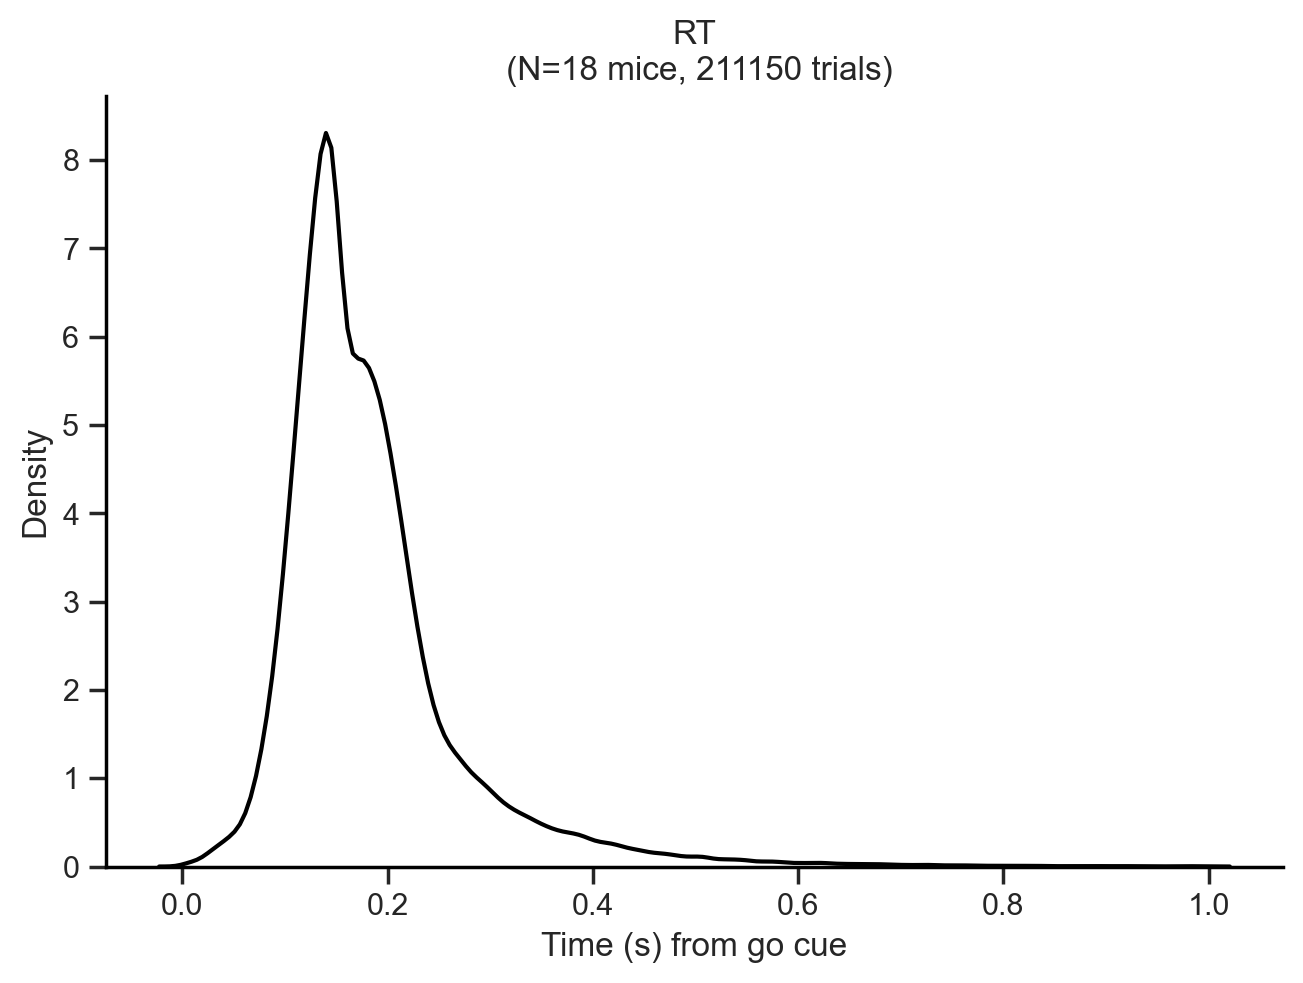

In [49]:
plot_licks_dist(df_behavior, var='RT', density=True)

This is the rawest representation of RT data. There is a bimodal distribution of RTs across all mice. The overall distribution has a shoulder-like second peak (lower) after the first one. It is likely due to the presence of two different strategies in the task: one that involves a fast response and another that involves a slower response. Let's rule out other hypotheses first (easier and faster to check).

One hypothesis is that the difference evidence levels (ILDs) drives different RTs. To examine this, we can plot a RT distribution per ILD level. To visually compare the distributions, a Kernel Desnity Estimation (KDE) plot is preferred.

#### Gaussian Mixture fit

Component 0: mean=0.13 s, std=0.03 s, weight=0.53
Component 1: mean=0.20 s, std=0.03 s, weight=0.33
Component 2: mean=0.30 s, std=0.06 s, weight=0.11
Component 3: mean=0.47 s, std=0.15 s, weight=0.03


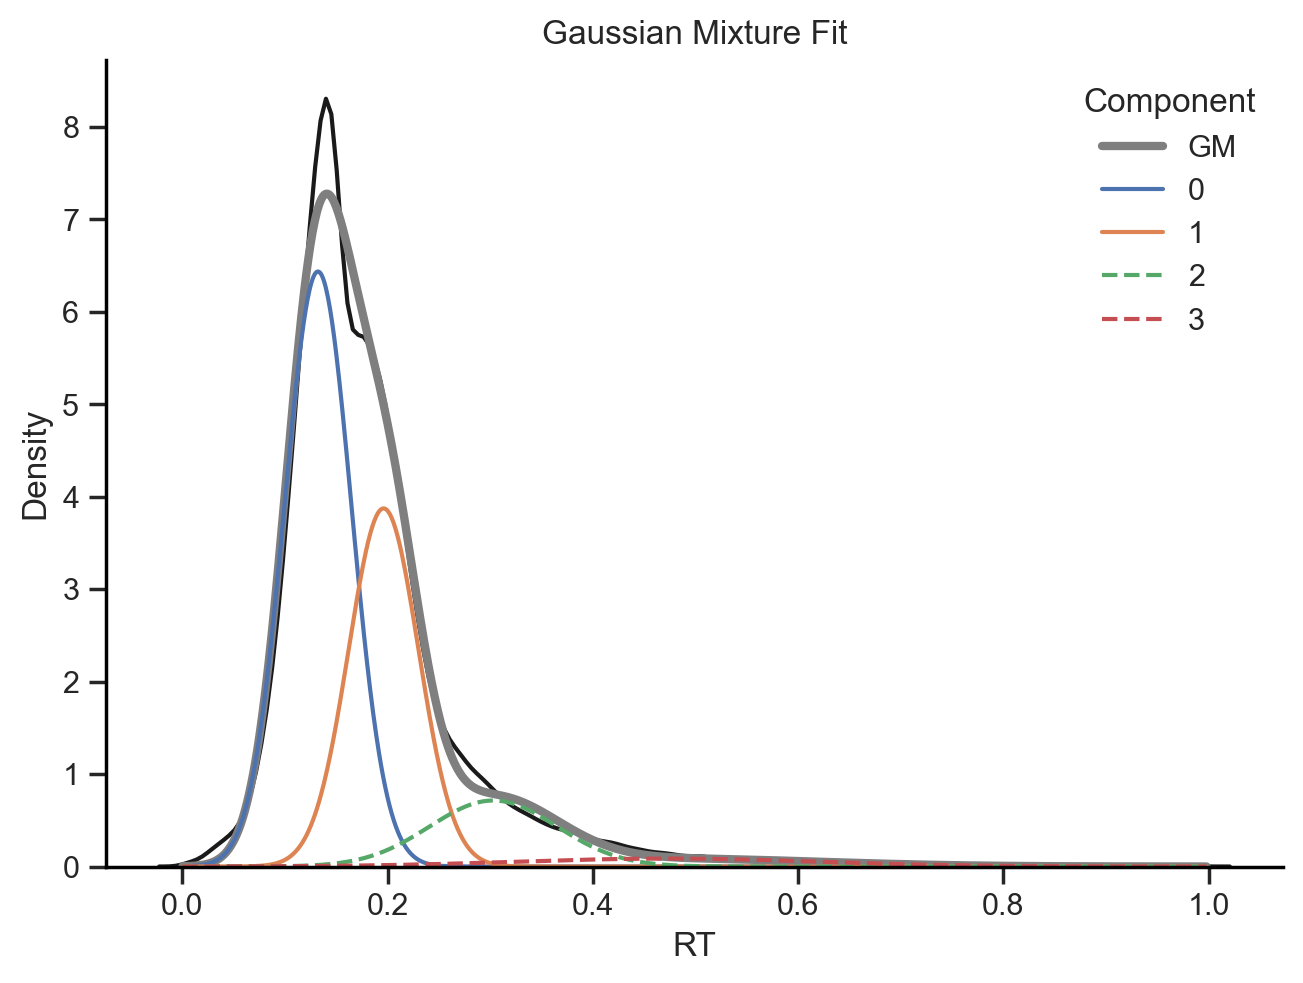

In [225]:
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

# Get your data as a 1D array (drop NaNs if needed)
rt = df_behavior.RT.dropna().values.reshape(-1, 1)

# Fit a 2-component Gaussian mixture
gm = GaussianMixture(n_components=4)
gm.fit(rt)

# Plot the RT distribution
plot_licks_dist(df_behavior, var='RT', density=True)

# Plot the GMM fit
x = np.linspace(rt.min(), rt.max(), 1000).reshape(-1, 1)
logprob = gm.score_samples(x)
pdf = np.exp(logprob)
plt.plot(x, pdf, color='tab:gray', lw=3, label='GM')

# Get predicted component for each sample
labels = gm.predict(rt)

# Flatten means and covariances
gm_means = gm.means_.flatten()
gm_covariances = gm.covariances_.flatten()
gm_weights = gm.weights_.flatten()

# Sort component indices by mean RT
sorted_idx = np.argsort(gm_means)

# Create a mapping from old component label -> new label by order of means
label_map = {old_label: new_label for new_label, old_label in enumerate(sorted_idx)}

# Relabel the predicted labels accordingly
sorted_labels = np.array([label_map[l] for l in labels])

# Add labels to df
df_behavior['RTlabelsGM'] = sorted_labels

# Plot the components in order with new labels
for i in range(len(sorted_idx)):

    orig_label = sorted_idx[i]
    mean = gm_means[orig_label]
    std = np.sqrt(gm_covariances[orig_label])
    weight = gm_weights[orig_label]

    # sns.kdeplot(rt[sorted_labels == i].squeeze(), ls=ls, label=i)
    component_pdf = weight * norm.pdf(x, loc=mean, scale=std)
    ls = '--' if i in [2, 3] else '-'
    plt.plot(x, component_pdf, ls=ls, label=i)

    print(f'Component {i}: mean={mean:.2f} s, std={std:.2f} s, weight={weight:.2f}')

plt.xlabel('RT')
plt.ylabel('Density')
plt.title('Gaussian Mixture Fit')
plt.legend(frameon=False, title='Component')
sns.despine()

##### Plot RT distributions grouped by component

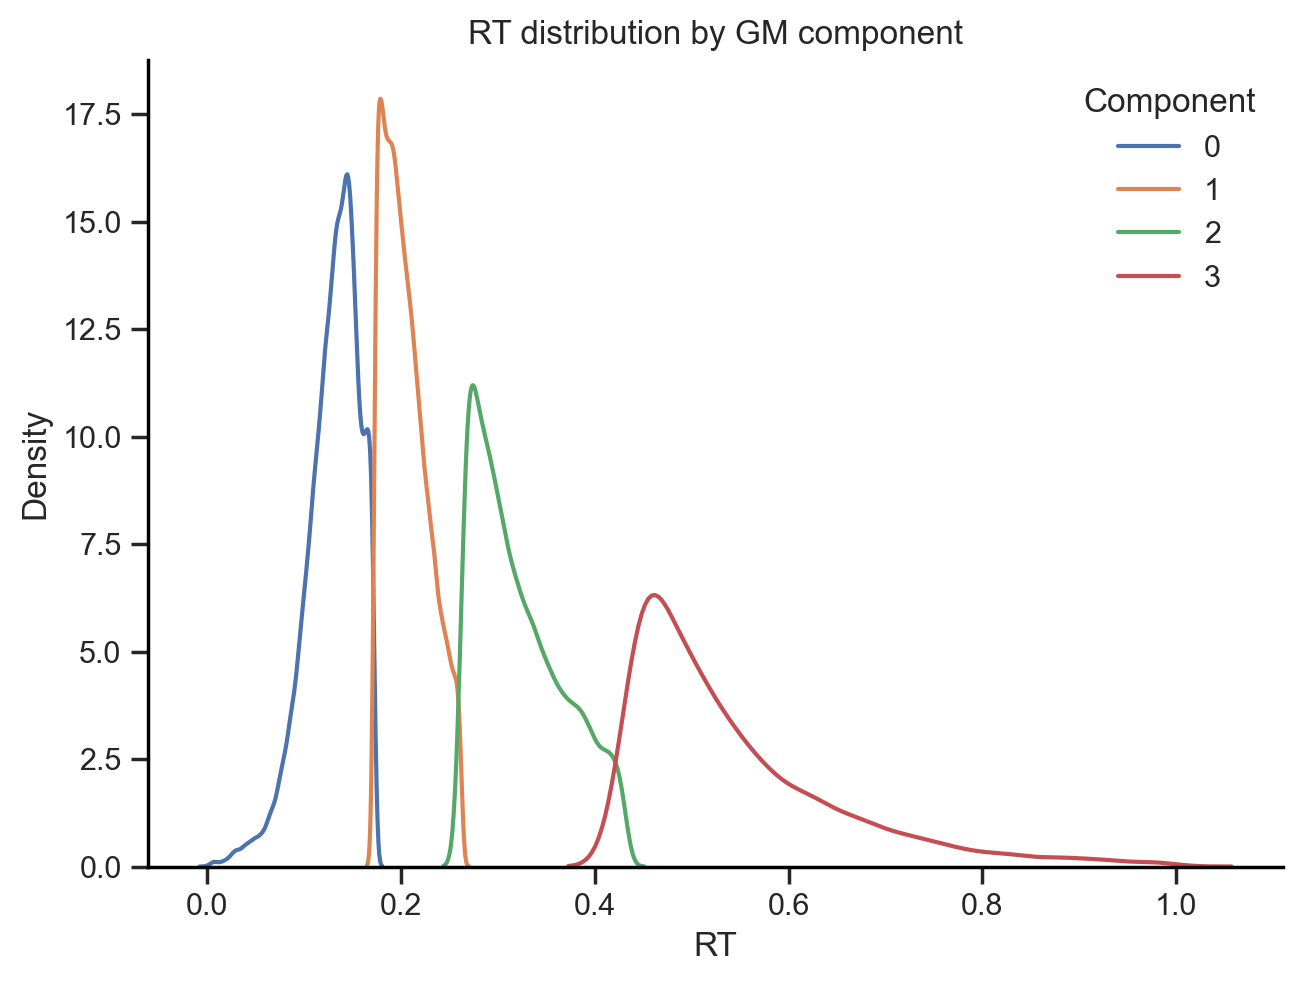

In [226]:
plt.figure(constrained_layout=True)
for i in range(len(df_behavior.RTlabelsGM.unique())):
    sns.kdeplot(df_behavior[df_behavior.RTlabelsGM==i].RT, label=i)
plt.title('RT distribution by GM component')
plt.legend(frameon=False, title='Component')
sns.despine()

##### Screening of variables to explain the difference between the first 2 components (0 and 1)

In [227]:
columns = df_behavior.columns
print(columns)

regressors = ['Trial', 'Side', 'RepTrial', 'Hit', 'AfterHit', 'Choice', 'RepChoice',
              'ILD', 'ILDRep', 'P', 'nLicksLeft', 'nLicksRight', 'absILD', 'SessionHalf']

# Keep only rows where component is 0 or 1
X = df_behavior[df_behavior.RTlabelsGM.isin([0, 1])].copy()
y = X.RTlabelsGM
X = X[regressors]

Index(['Trial', 'Side', 'RepTrial', 'Reward', 'Punish', 'Miss', 'WrongLick',
       'Hit', 'AfterHit', 'Choice', 'RepChoice', 'Response', 'TrialStart',
       'TrialEnd', 'TrialLen', 'StimStart', 'StimEnd', 'StimLen',
       'RespWinStart', 'RespWinEnd', 'RespWinLen', 'Filename', 'Filename2',
       'FilesMatch', 'Message', 'MessageFound', 'SoundLeft', 'SoundRight',
       'Sound', 'ILD', 'ILDRep', 'Port1In', 'Port1Out', 'Port2In', 'Port2Out',
       'ValveLeft', 'ValveRight', 'AW', 'AWTrials', 'Switch', 'Timeout',
       'Fixation', 'Stage', 'Motor', 'REC', 'Progression', 'CB', 'RespWin',
       'ITI', 'WarmUp', 'RecoveryMode', 'P', 'PRight', 'Blocks', 'BlockLen',
       'Task', 'Ephys', 'StimDur', 'Delay', 'VarDelay', 'SerialPort',
       'Protocol', 'Creator', 'Project', 'Experiment', 'Board', 'Setup',
       'NetPort', 'Subject', 'BpodApiVersion', 'Session', 'Date',
       'SessionStart', 'SessionEnd', 'LicksLeft', 'LicksRight', 'nLicksLeft',
       'nLicksRight', 'nLicks', 'ILI_Le

In [228]:
from scipy.stats import ttest_ind

results = []

for col in X.columns:
    # For numeric vars -> t-test
    group0 = X[y == 0][col].dropna()
    group1 = X[y == 1][col].dropna()
    stat, pval = ttest_ind(group0, group1, equal_var=False)
    diff = group0.mean() - group1.mean()
    results.append((col, 'numeric', diff, pval))

# Make results table
df_results = pd.DataFrame(results, columns=['Variable', 'Type', 'MeanDiff', 'pval'])
df_results['pval_adj'] = df_results['pval'] * len(df_results)  # Bonferroni correction
df_results = df_results.sort_values('pval')

print(df_results)

       Variable     Type  MeanDiff           pval       pval_adj
13  SessionHalf  numeric -0.062407  1.264823e-148  1.770752e-147
11  nLicksRight  numeric  0.398896  2.241887e-110  3.138642e-109
10   nLicksLeft  numeric  0.294755   3.391199e-70   4.747679e-69
4      AfterHit  numeric  0.024331   1.430650e-38   2.002910e-37
3           Hit  numeric  0.023231   7.526695e-35   1.053737e-33
0         Trial  numeric -8.373798   3.987057e-31   5.581880e-30
9             P  numeric  0.008394   1.433574e-25   2.007003e-24
7           ILD  numeric  2.410915   2.060798e-16   2.885117e-15
5        Choice  numeric  0.018785   5.445209e-15   7.623292e-14
1          Side  numeric  0.016598   5.151238e-12   7.211733e-11
8        ILDRep  numeric  1.878037   1.944585e-10   2.722418e-09
2      RepTrial  numeric  0.014171   4.733627e-09   6.627078e-08
6     RepChoice  numeric  0.008567   3.200018e-04   4.480025e-03
12       absILD  numeric  0.101399   4.564564e-01   6.390390e+00


### Splits

#### ILD

##### Together

ILD 70: peak RT = 0.139 s
ILD 8: peak RT = 0.143 s
ILD 4: peak RT = 0.143 s
ILD 2: peak RT = 0.143 s
ILD 0: peak RT = 0.141 s
Mean RT = 0.142 s


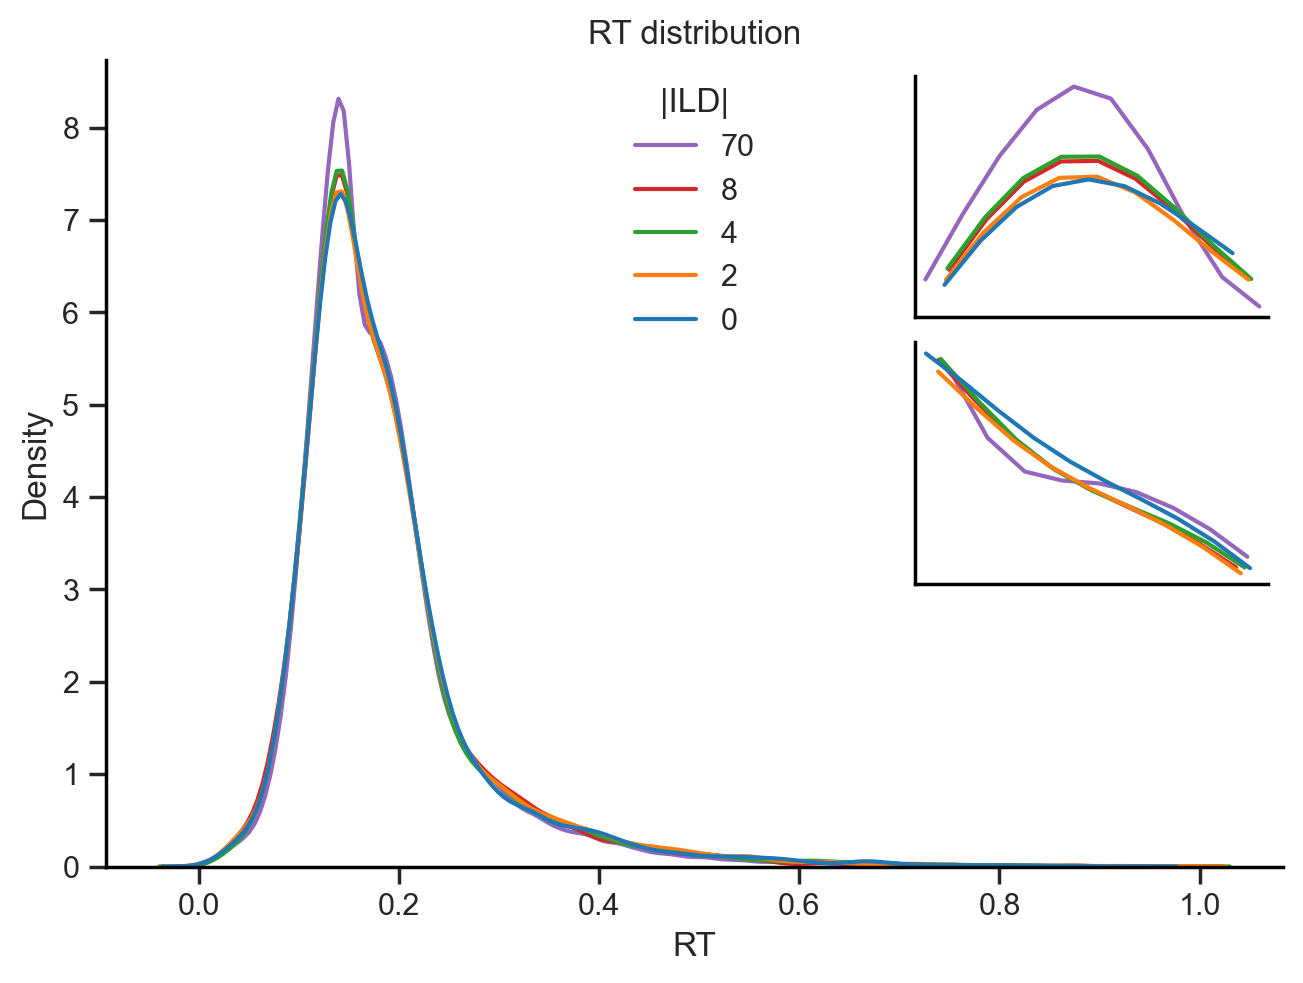

In [229]:
plot_ild_dist(df_behavior, var='RT')

The ILD does not seem to explain the existence bimodality in the RT distribution, as the bimodality is present across all ILD levels.

Nevertheless, zooming in the peak of the distribution (0.1-0.2 s), we can see that the RTs are faster for lower ILD levels, which is expected as the evidence is more certain. What is surprising is this modulation to show up despite the fact that mice were head-fixed. In addition, zoomin in the second peak of the distribution (0.15-0.2 s), we can see that the second peak is more pronounced for lower ILD levels, suggesting that the bimodality is actually modulated by ILD level.

Too many lines can make on top of each other make it hard to disentangle the ILD impact on RT, so we can plot the RT distribution for each ILD level separately.

##### Individually

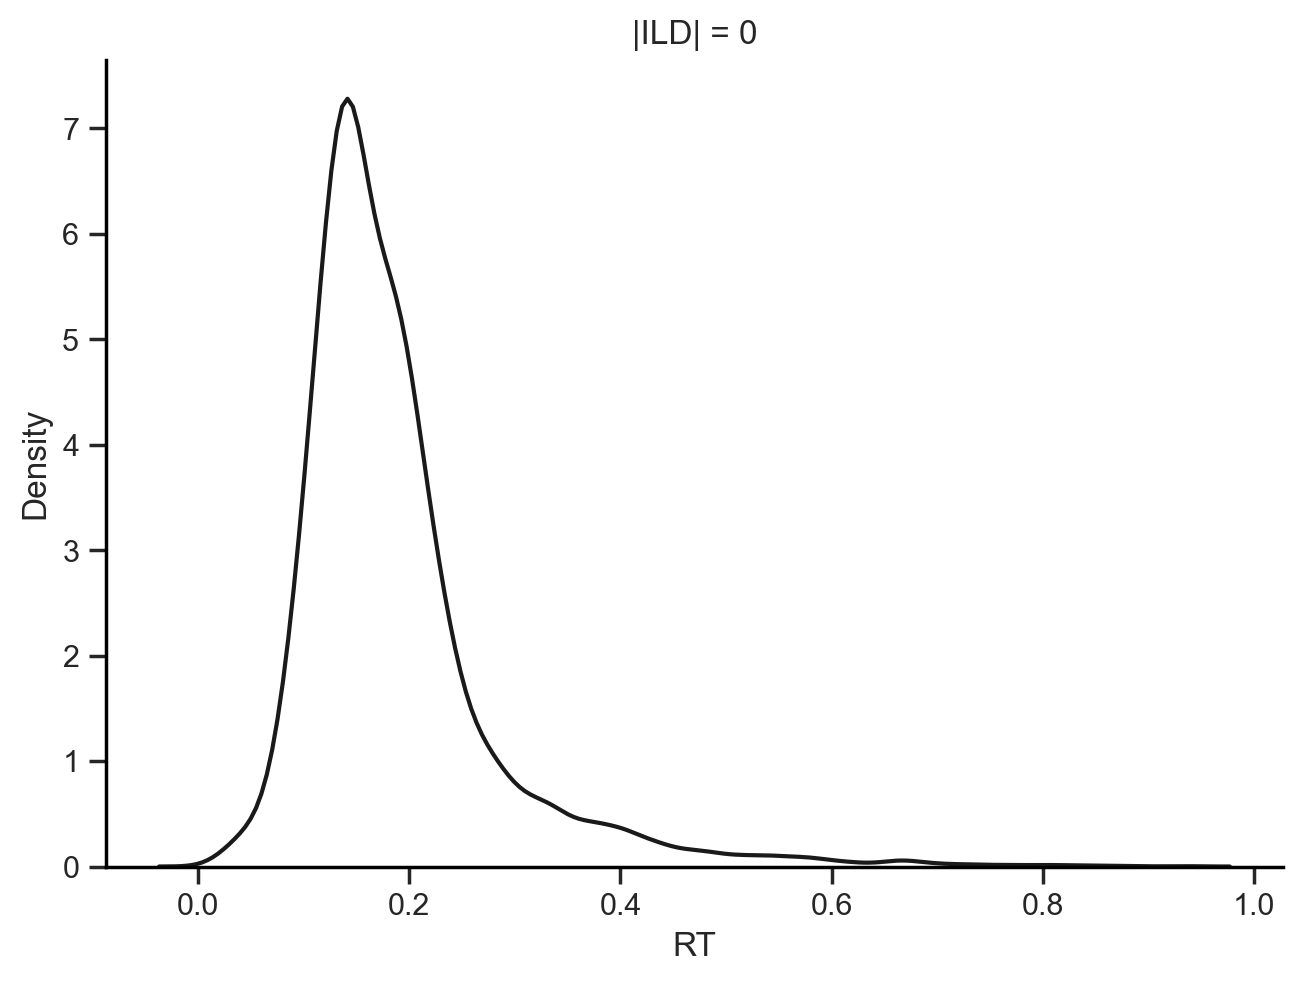

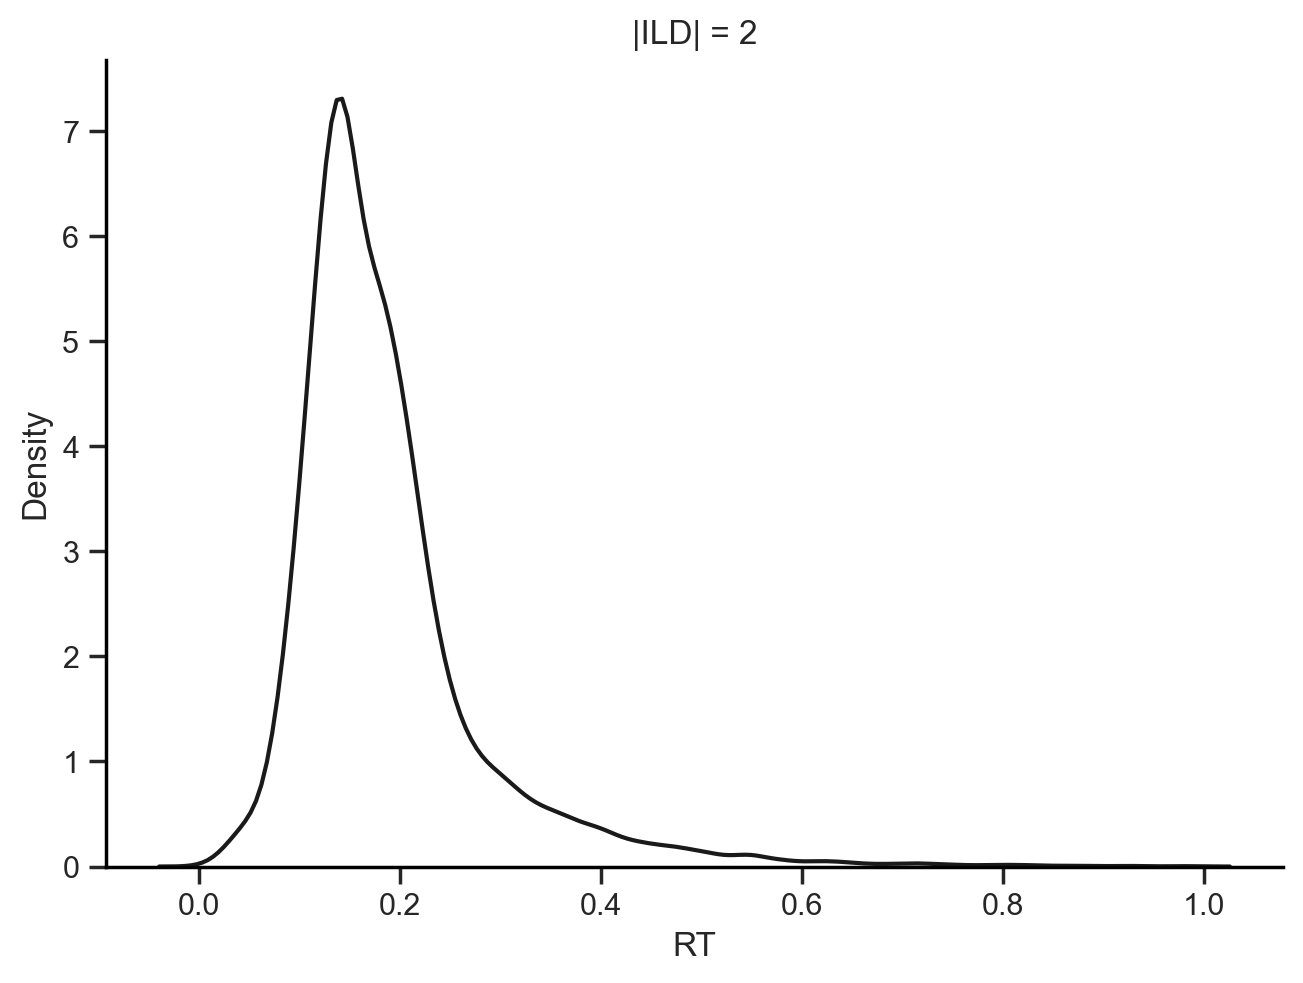

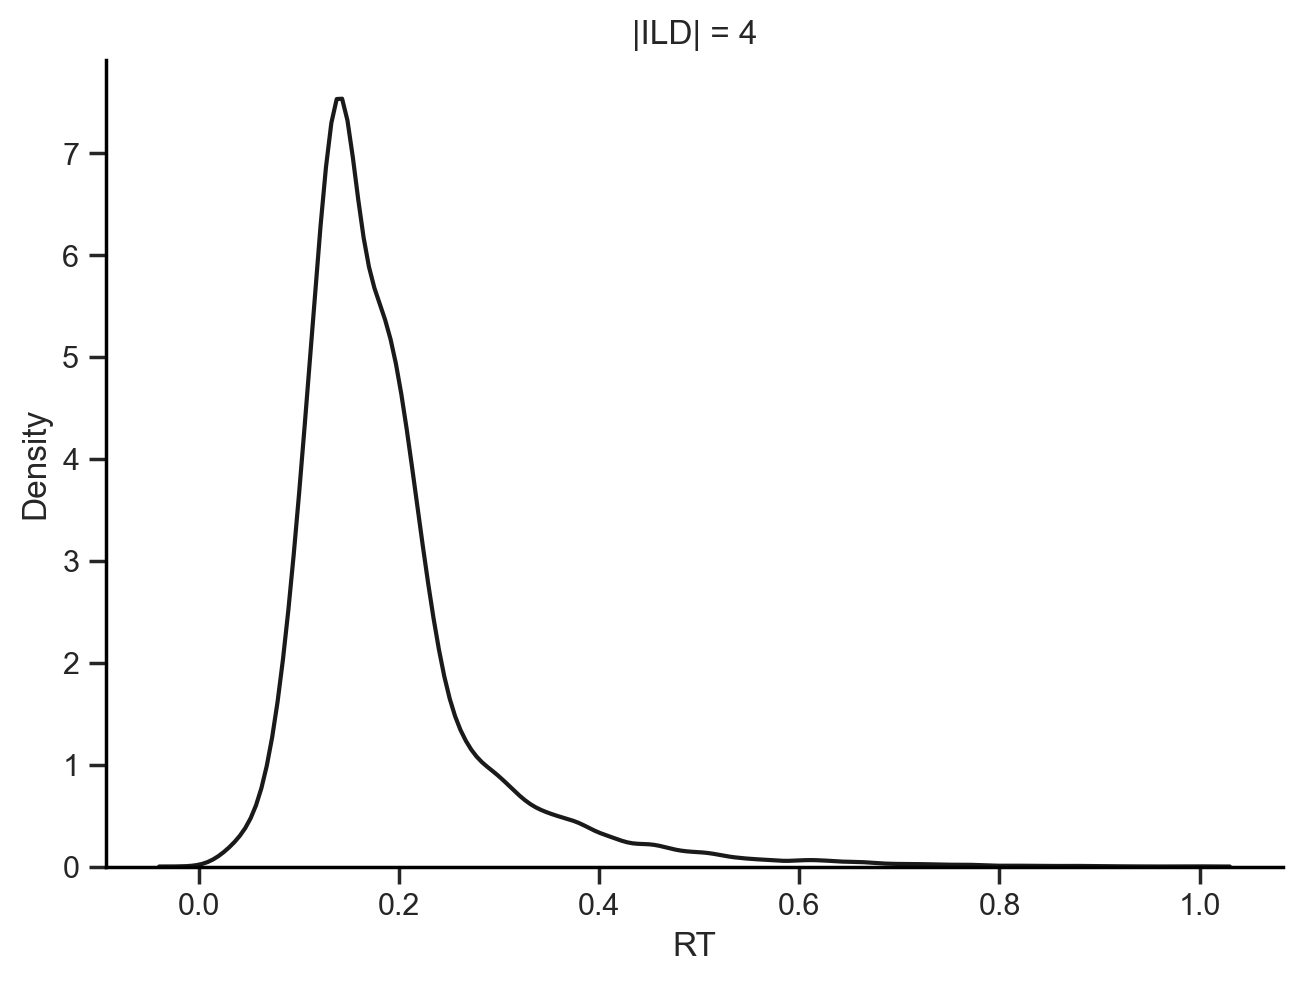

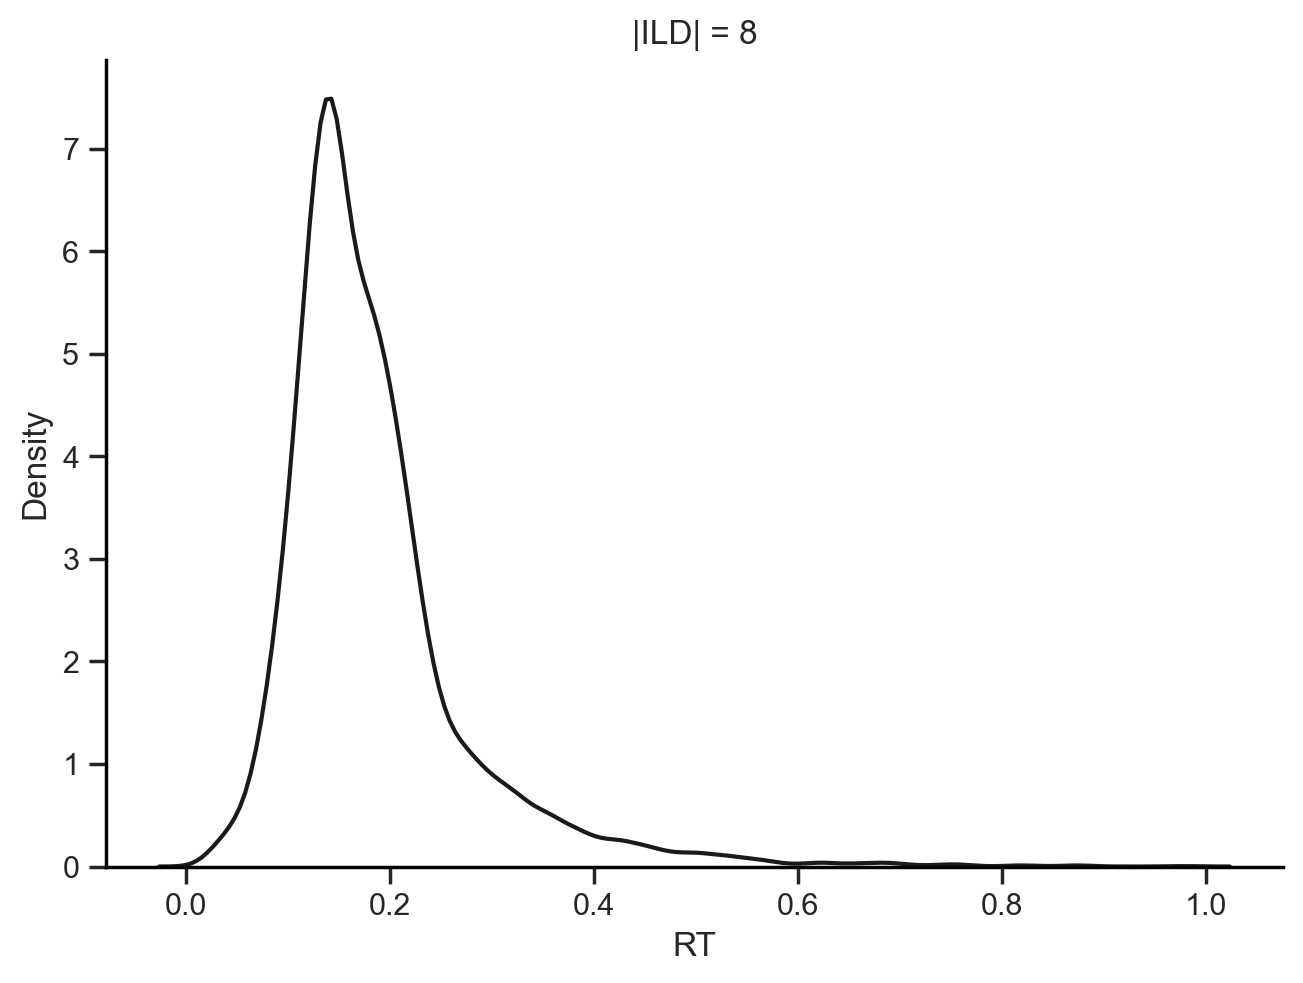

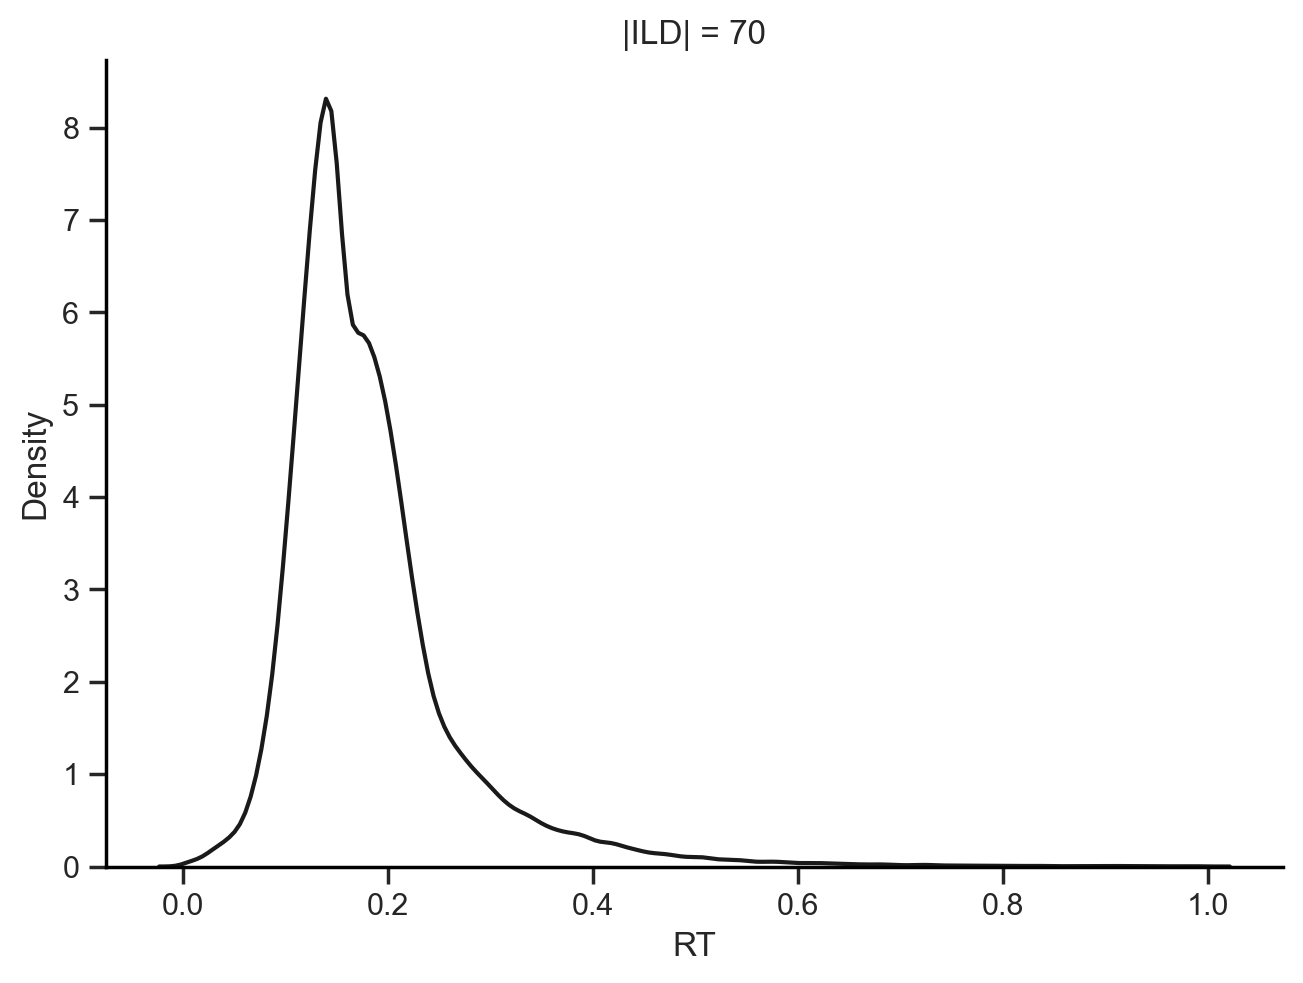

In [230]:
# Collapse the signed ILD levels to absolute values for cleaner visualization
abs_ilds = sorted(df_behavior.absILD.unique().astype(int))

# Plot the RT distribution for each absolute ILD level
for ild in abs_ilds:
    plt.figure(constrained_layout=True)
    df_ild = df_behavior[df_behavior.absILD == ild]
    sns.kdeplot(df_ild.RT, label=ild, color='k')
    plt.title(f'|ILD| = {ild}')
    sns.despine()

This is interesting. Although the bimodality is present in all ILD levels, the second peak is more pronounced for lower ILD levels. This suggests that the bimodality is not driven by differences in evidence levels, but rather by a different strategy used by the mice.

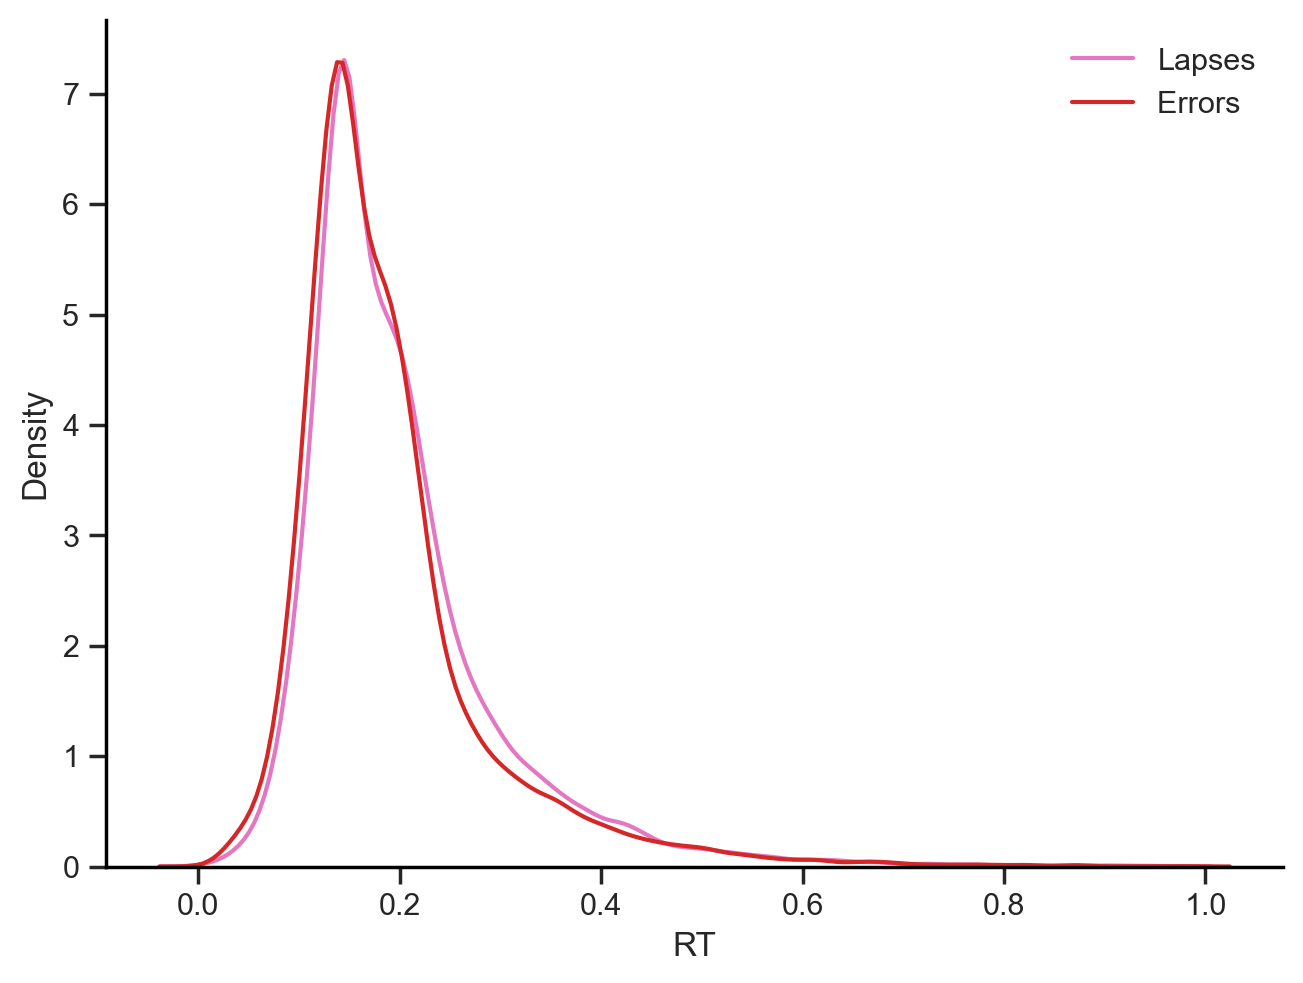

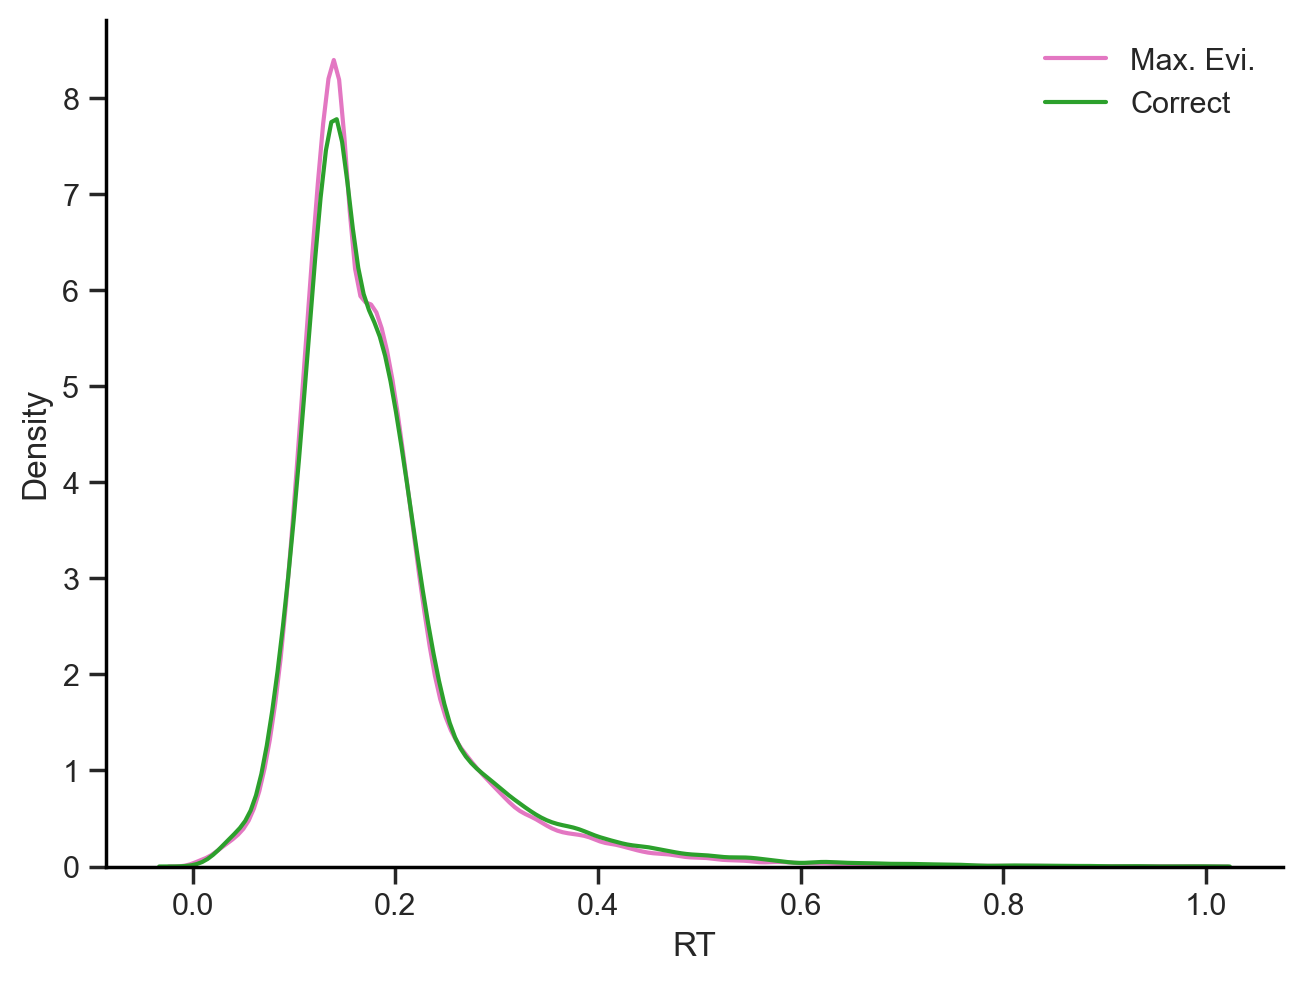

In [231]:
# Let's have a look to trials with maximum evidence, correct vs error
plt.figure(constrained_layout=True)
sns.kdeplot(df_behavior[(df_behavior.absILD == 70) & (df_behavior.Hit == 0)].RT, color='tab:pink' ,label='Lapses')
# sns.kdeplot(df_behavior[(df_behavior.absILD == 70) & (df_behavior.Hit == 1)].RT, color='tab:green' ,label='correct')
sns.kdeplot(df_behavior[(df_behavior.absILD != 70) & (df_behavior.Hit == 0)].RT, color='tab:red' ,label='Errors ')
plt.legend(loc='upper right', frameon=False)

# Let's have a look to trials with maximum evidence, correct vs error
plt.figure(constrained_layout=True)
sns.kdeplot(df_behavior[(df_behavior.absILD == 70) & (df_behavior.Hit == 1)].RT, color='tab:pink' ,label='Max. Evi.')
# sns.kdeplot(df_behavior[(df_behavior.absILD == 70) & (df_behavior.Hit == 1)].RT, color='tab:green' ,label='correct')
sns.kdeplot(df_behavior[(df_behavior.absILD != 70) & (df_behavior.Hit == 1)].RT, color='tab:green' ,label='Correct')
plt.legend(loc='upper right', frameon=False)

Another hypothesis is that the bimodality is driven by differences in behavioral variables such as outcome, choice, stimulus, repeat, or previous outcome. To examine this, we can plot a RT distribution per behavioral variable split in 2 conditions.

#### Outcome

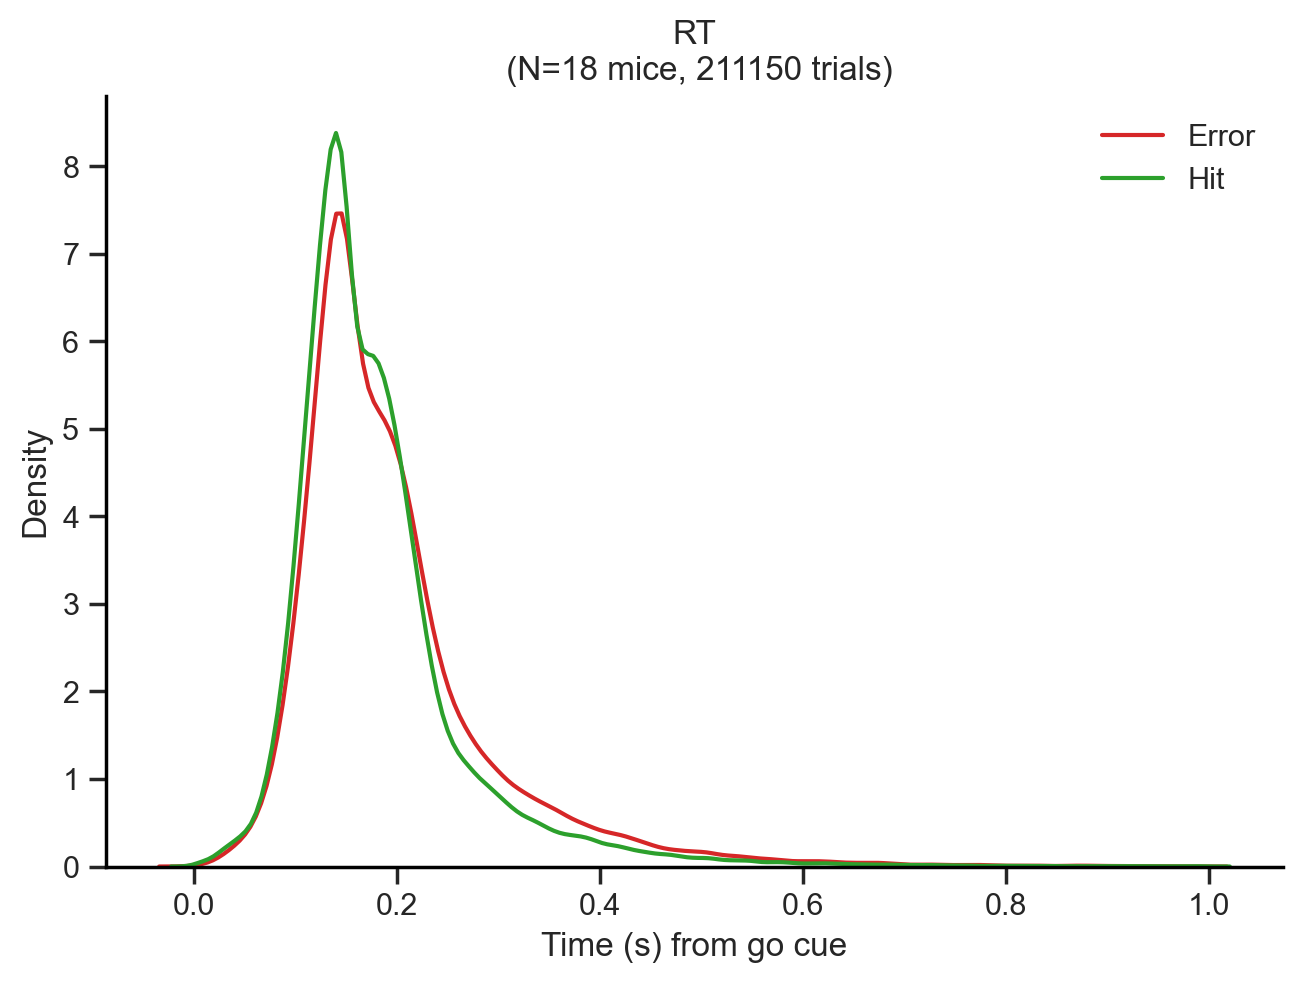

In [70]:
plot_licks_split(df_behavior, var='RT', split='outcome', kind='kde')

#### Previous outcome

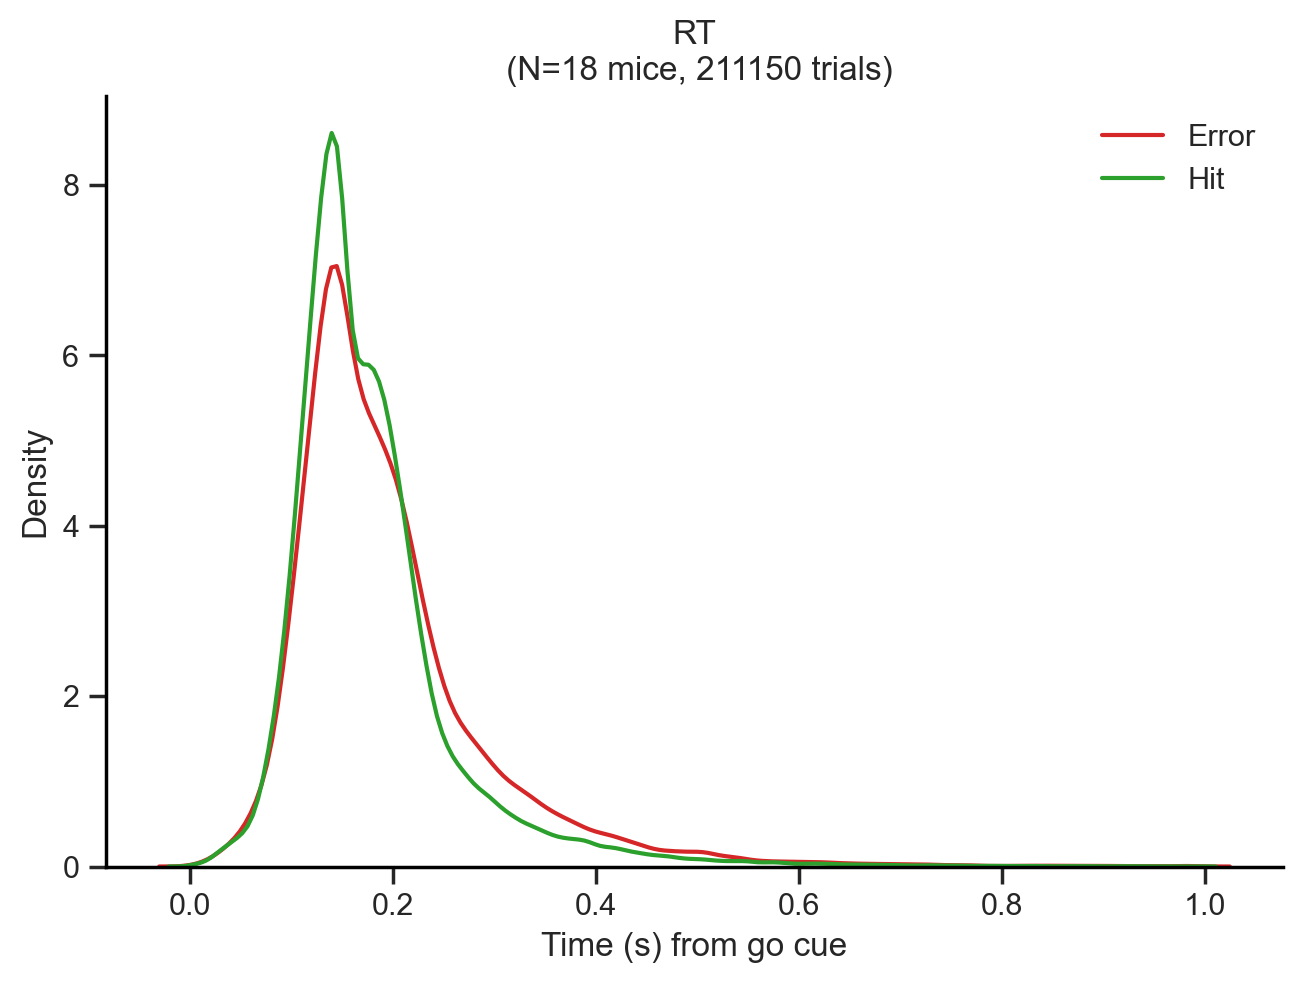

In [71]:
plot_licks_split(df_behavior, var='RT', split='prev_out', kind='kde')

#### Choice

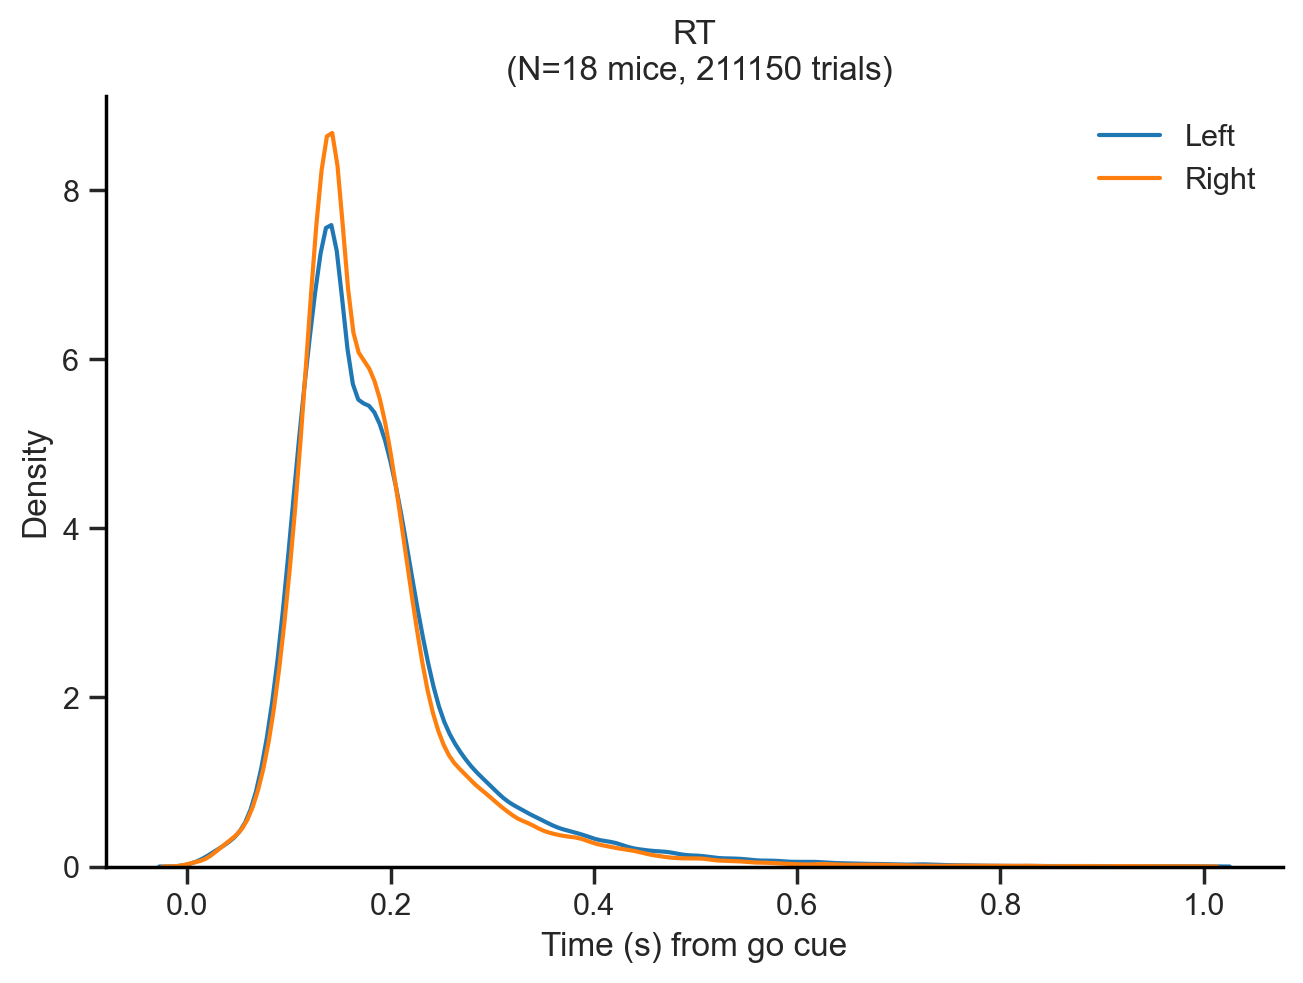

In [72]:
plot_licks_split(df_behavior, var='RT', split='choice', kind='kde')

#### Repeat choice

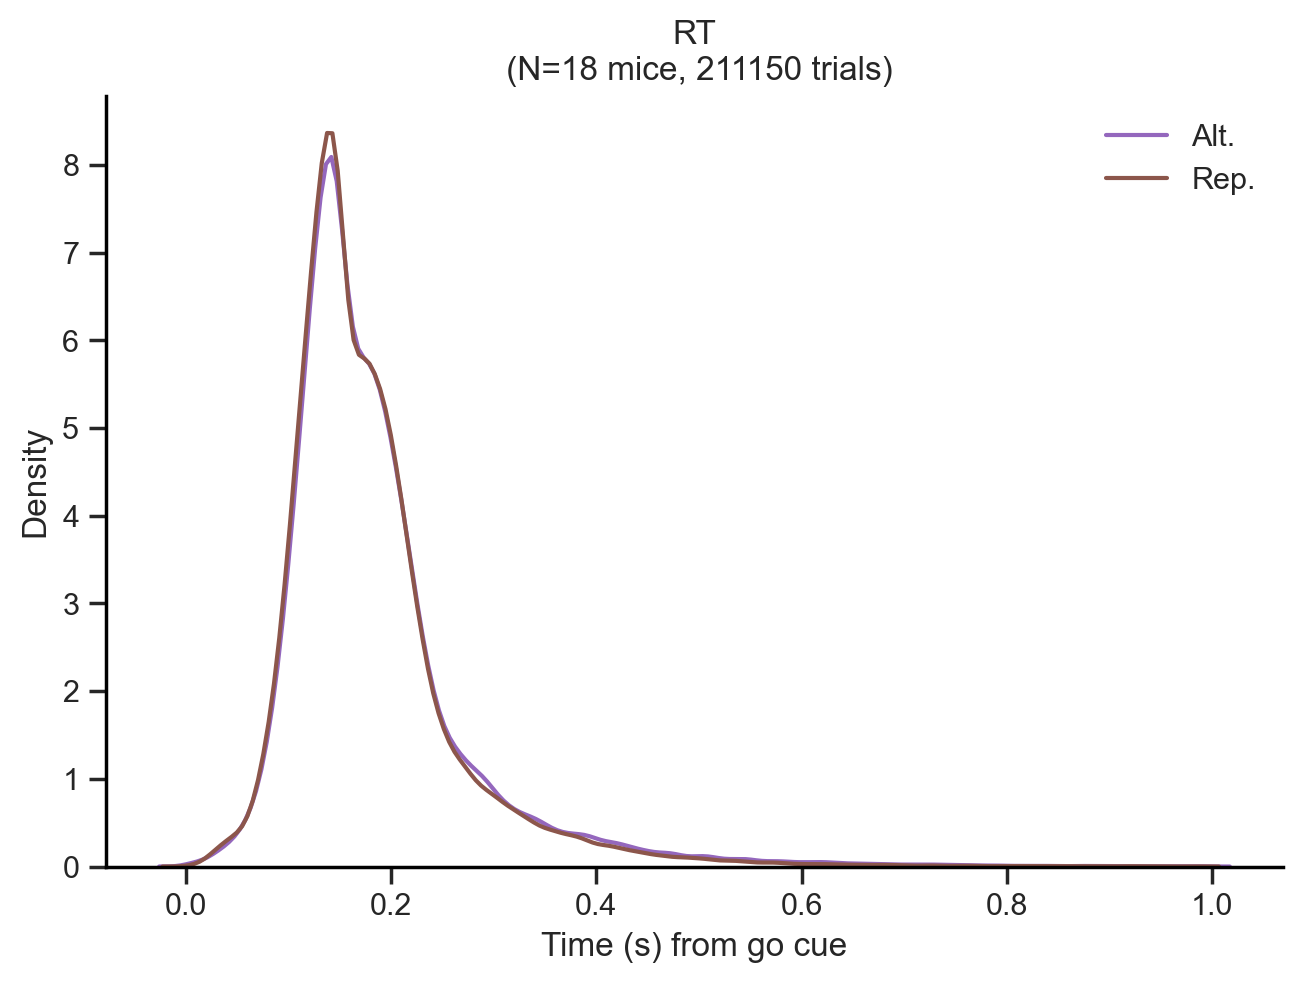

In [73]:
plot_licks_split(df_behavior, var='RT', split='rep_choice', kind='kde')

#### Repeat trial
Trials in which the stimulus (rewarded) side coincides with the previous animal’s choice

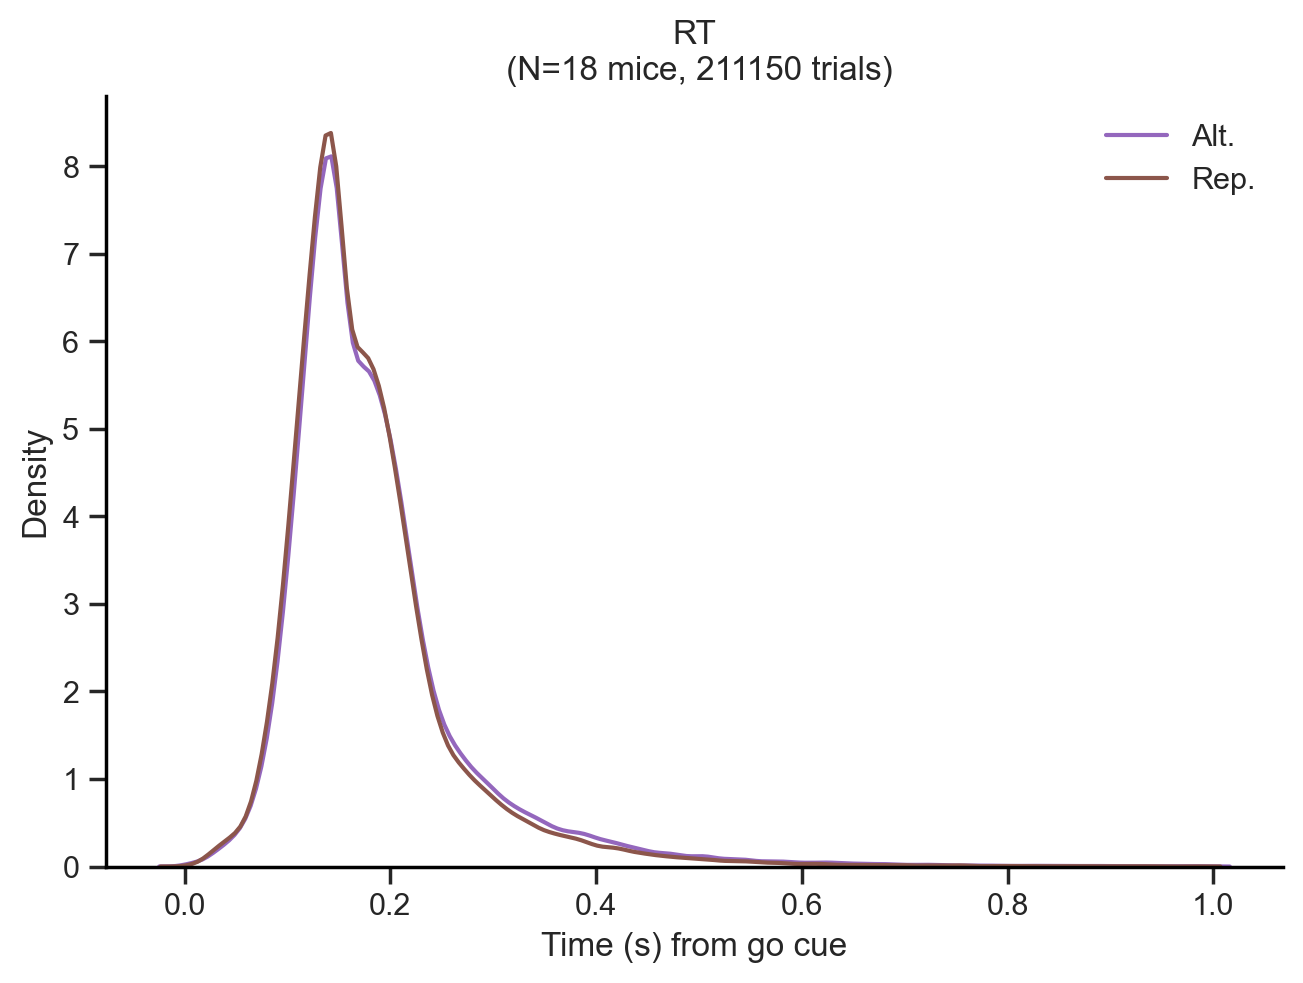

In [74]:
plot_licks_split(df_behavior, var='RT', split='rep_trial', kind='kde')

#### Stimulus

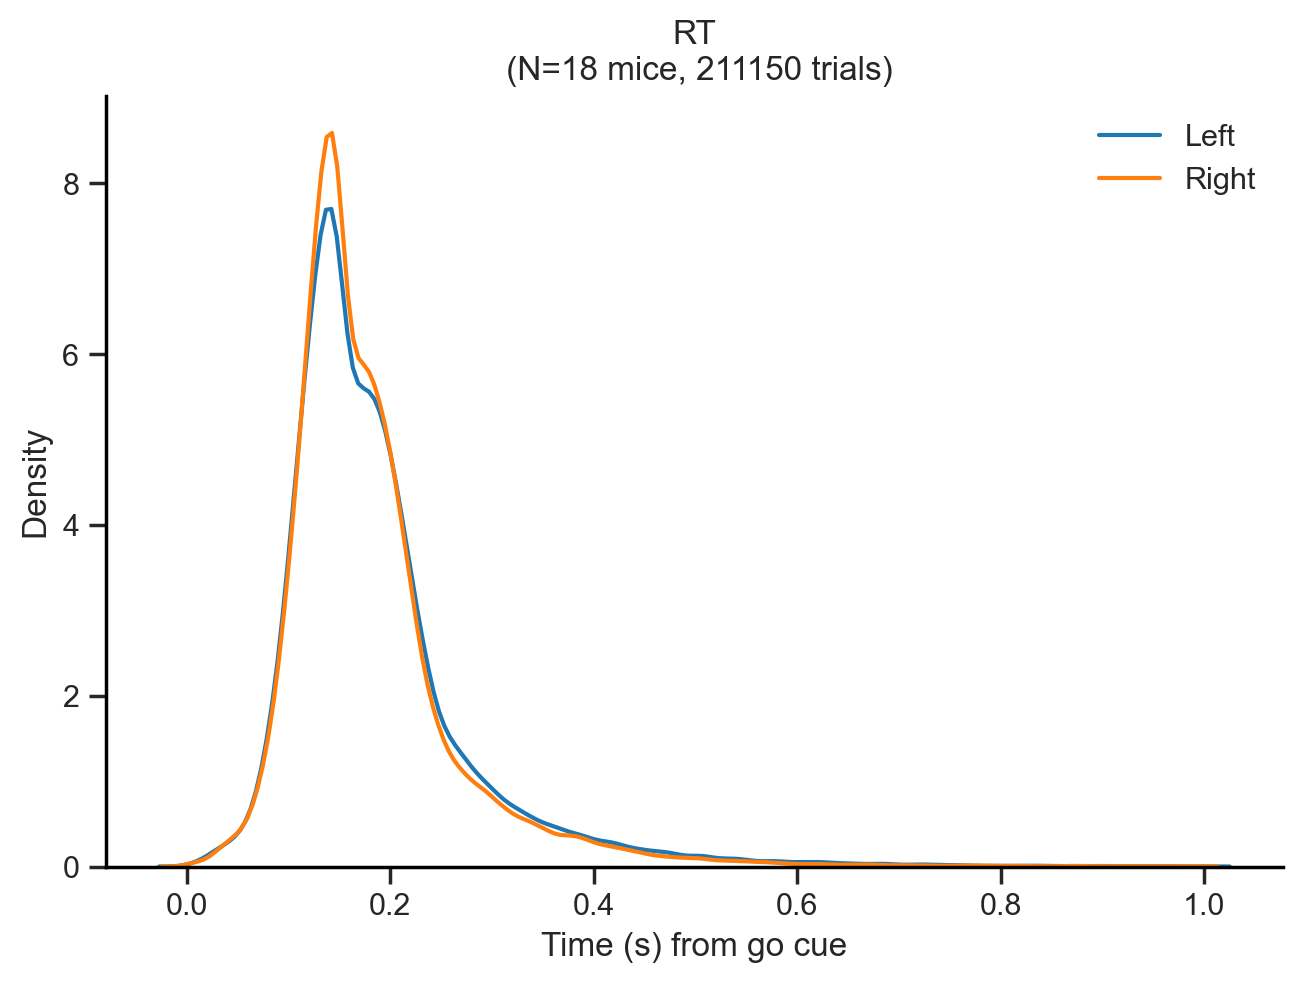

In [75]:
plot_licks_split(df_behavior, var='RT', split='stim', kind='kde')

This bimodality can not be explained by differences in behavioral variables such as outcome, choice, stimulus, repeat, or previous outcome.

#### 1st vs 2nd session half

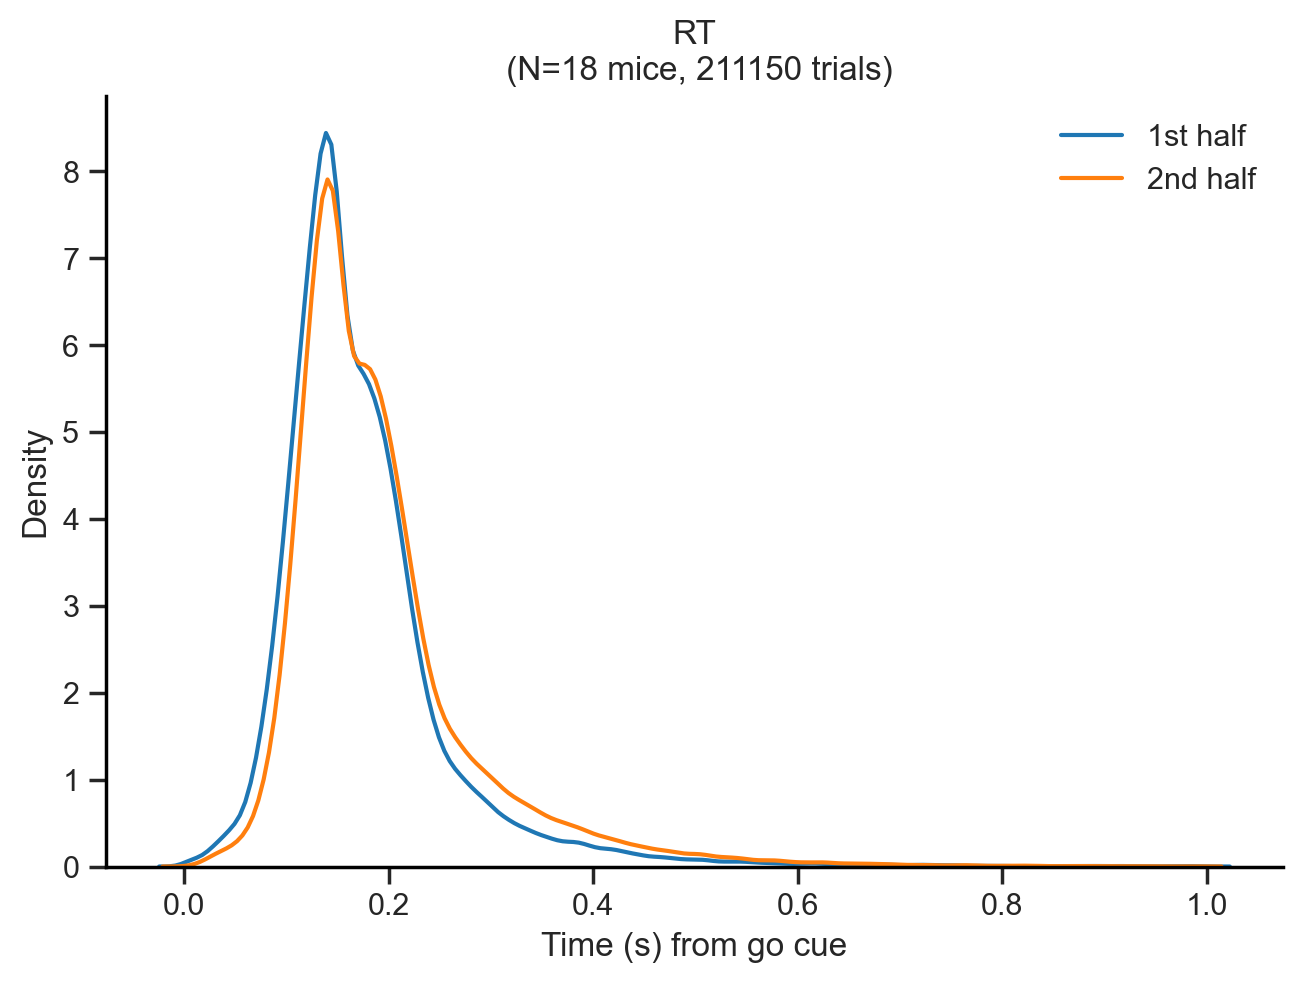

In [76]:
plot_licks_split(df_behavior, var='RT', split='half', kind='kde')

The bimodality is present in both halves of the session, suggesting that it is not driven by a change in the internal state of the animal. The RT distribution is similar in both halves of the session, with a slight shift towards slower RTs in the second half.

Another possibility is that the bimodality just results from the individual variability in the RTs of each subject. To examine this, we can plot the RT distribution for each subject separately. If the bimodality is driven by individual variability, we would expect to see a unimodal distribution in each subject.

### Check the bimodality is present in every subject

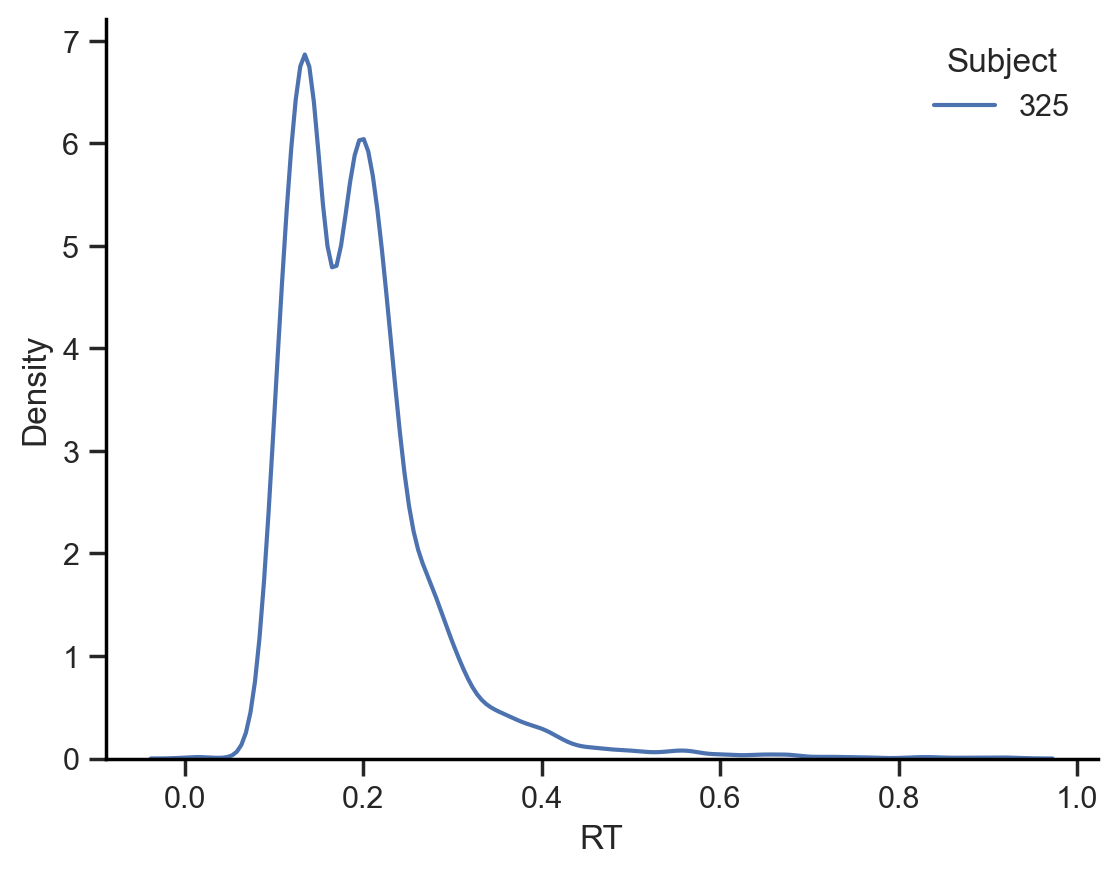

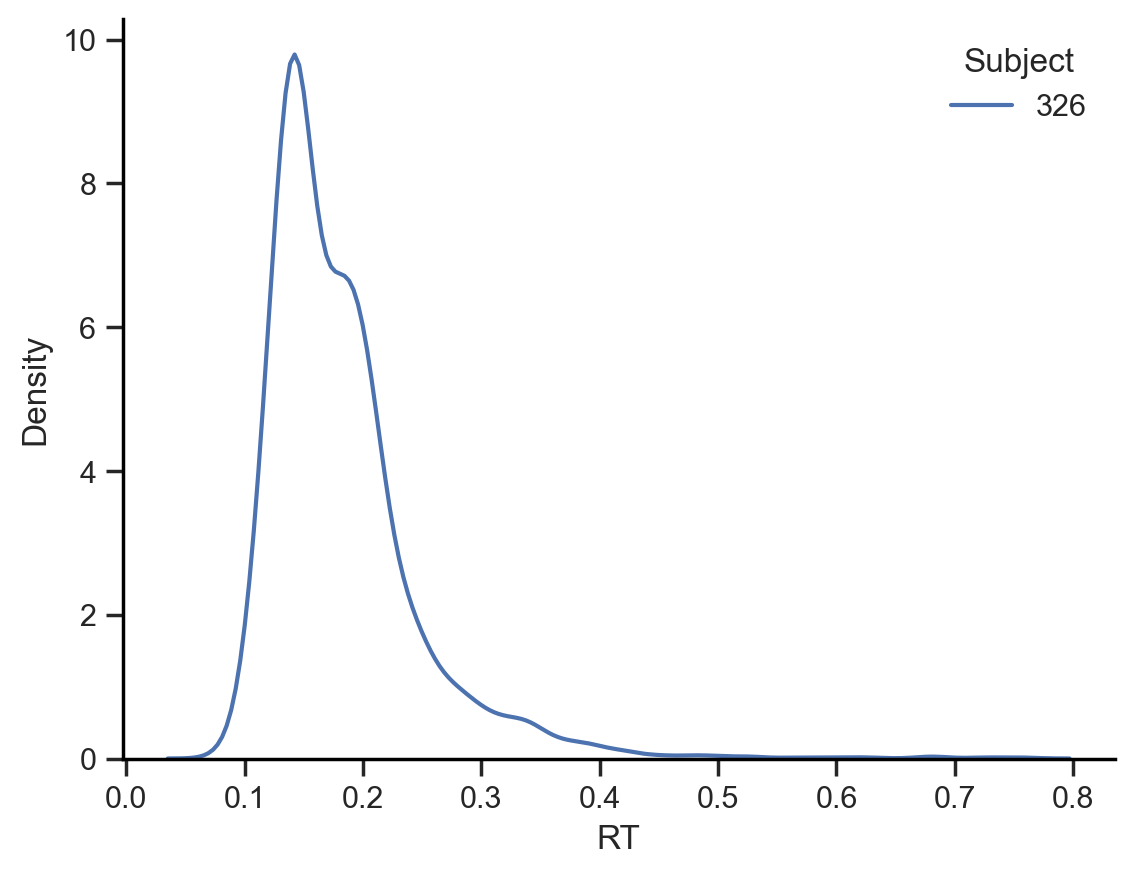

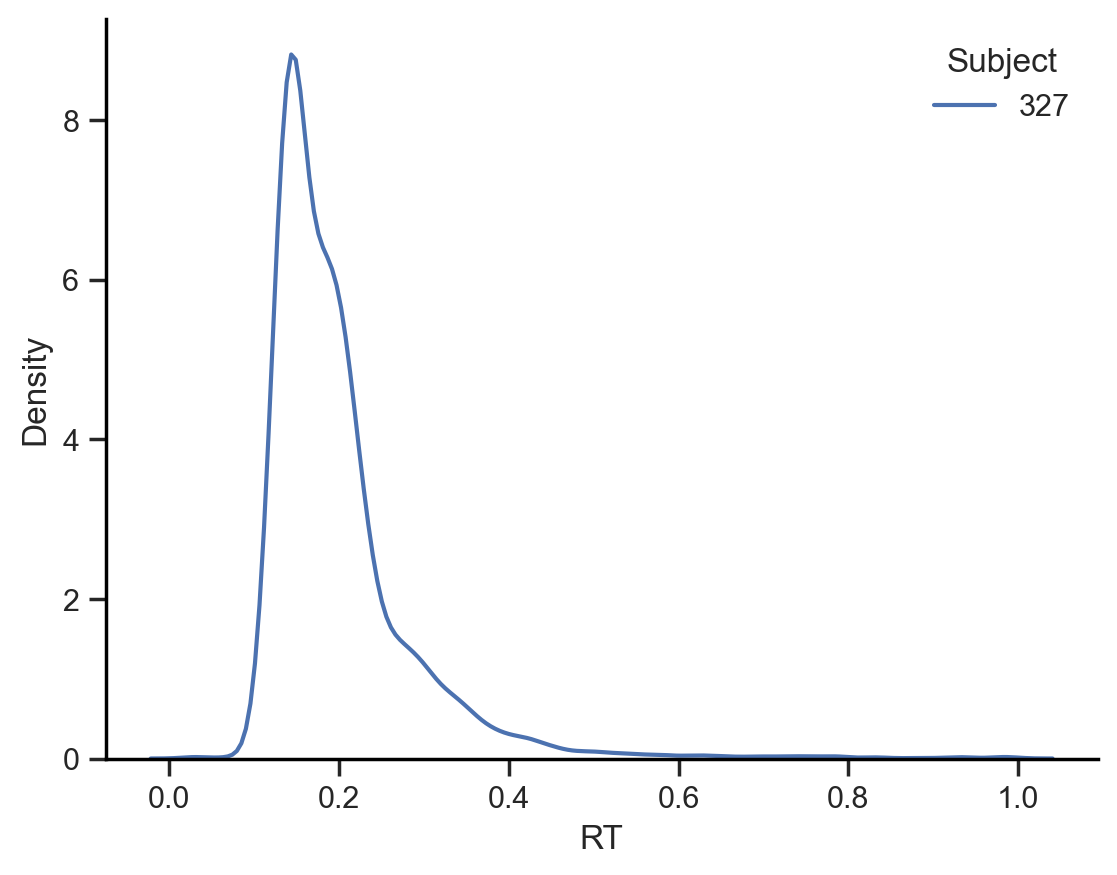

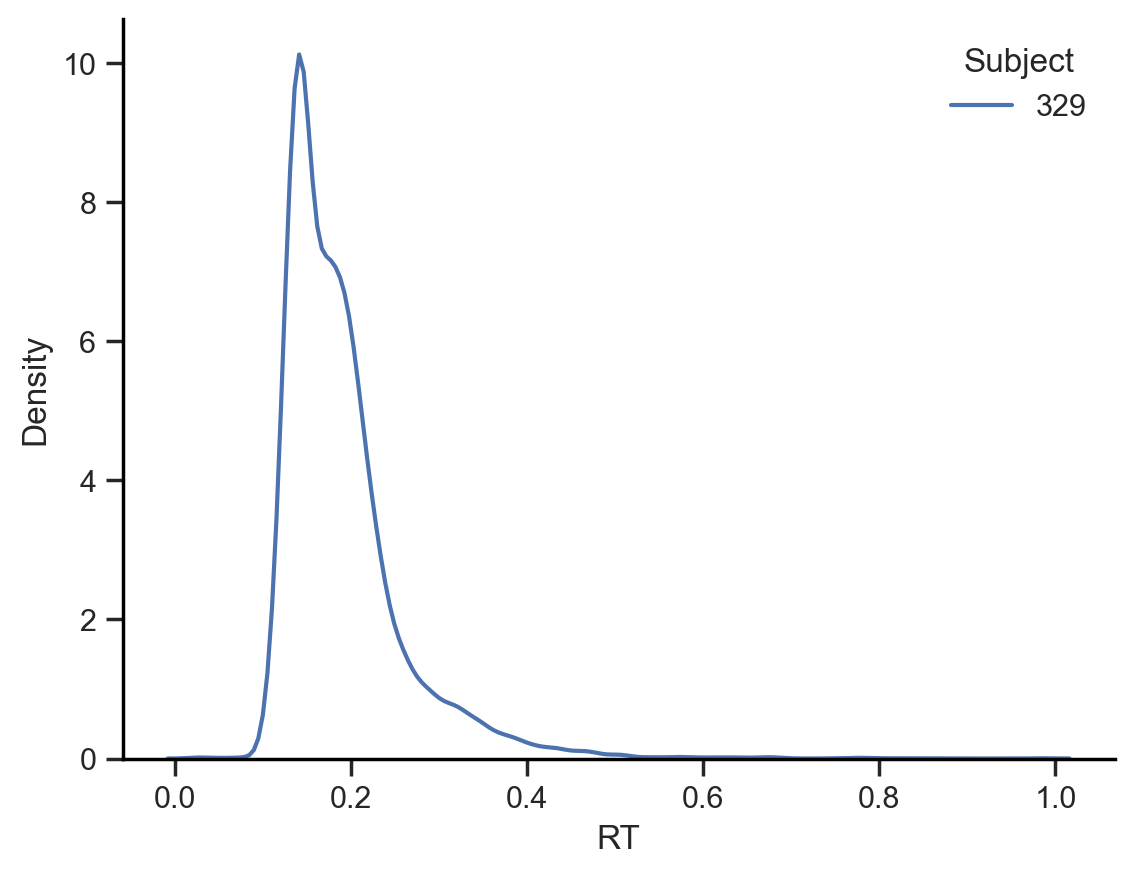

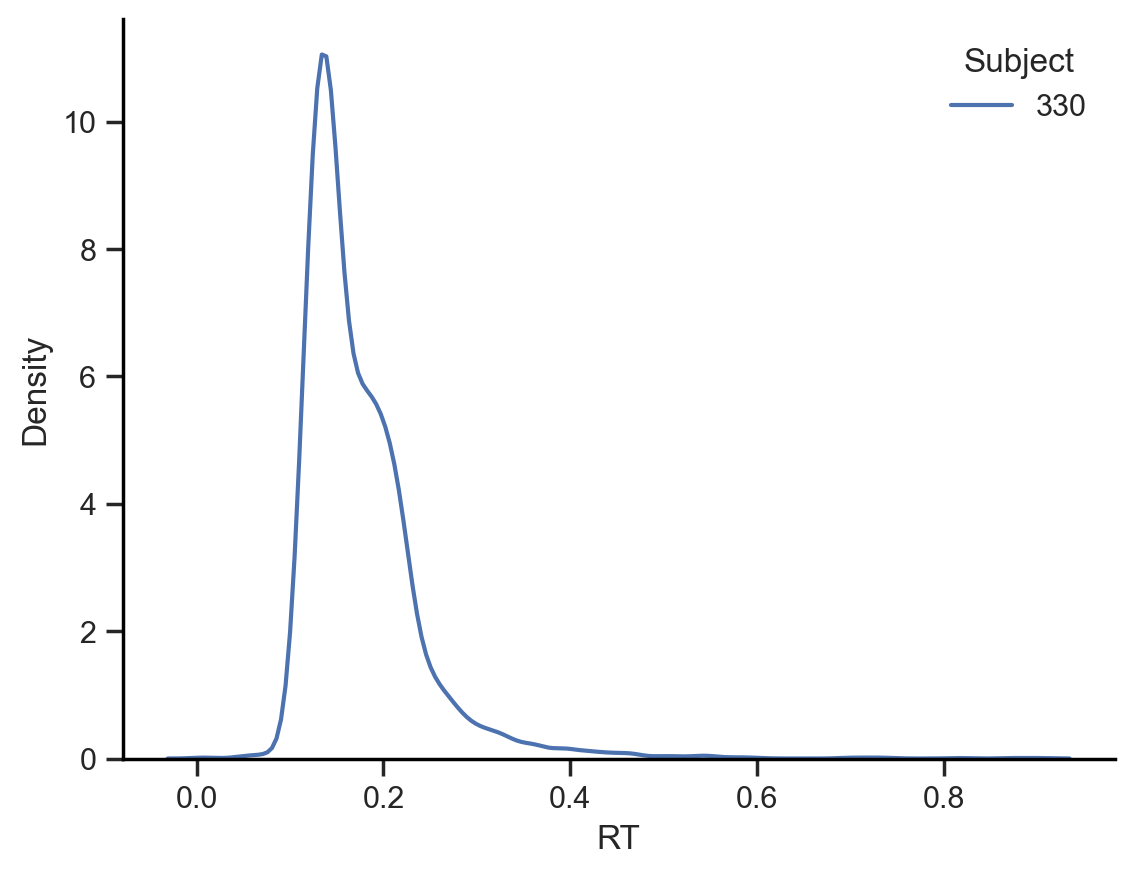

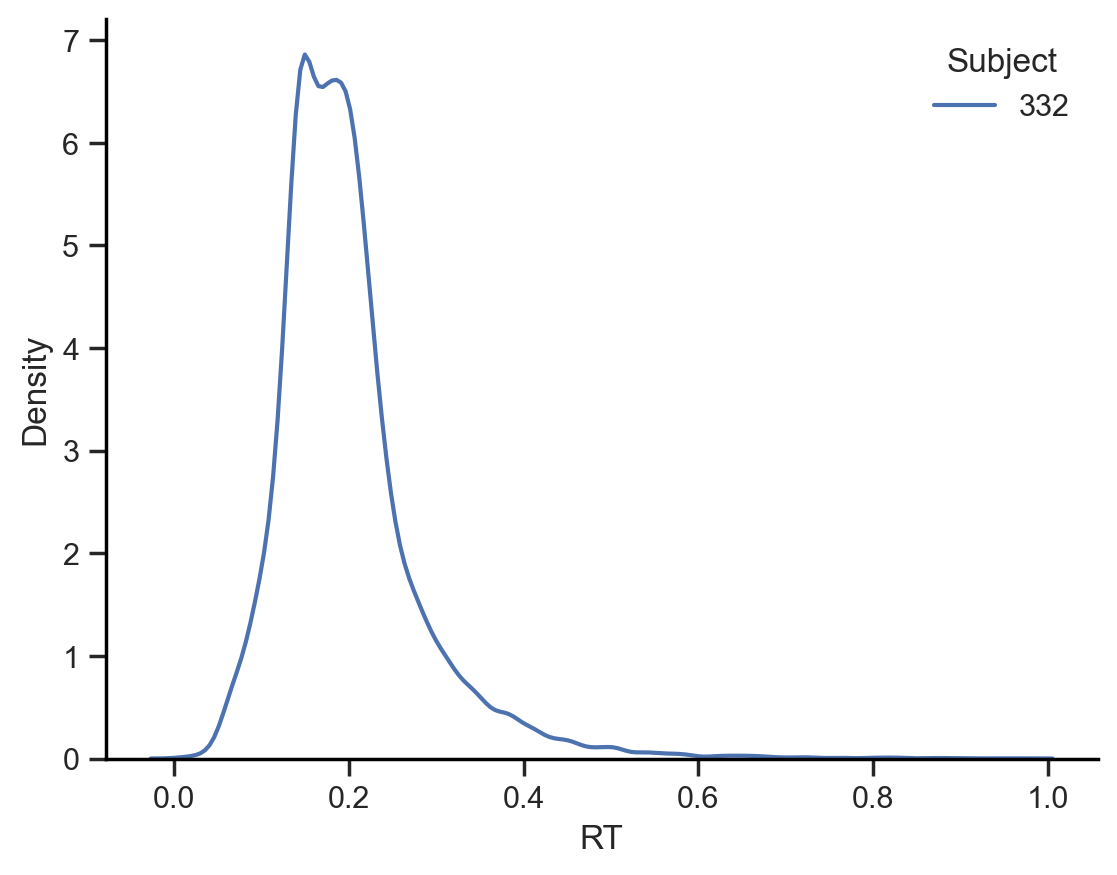

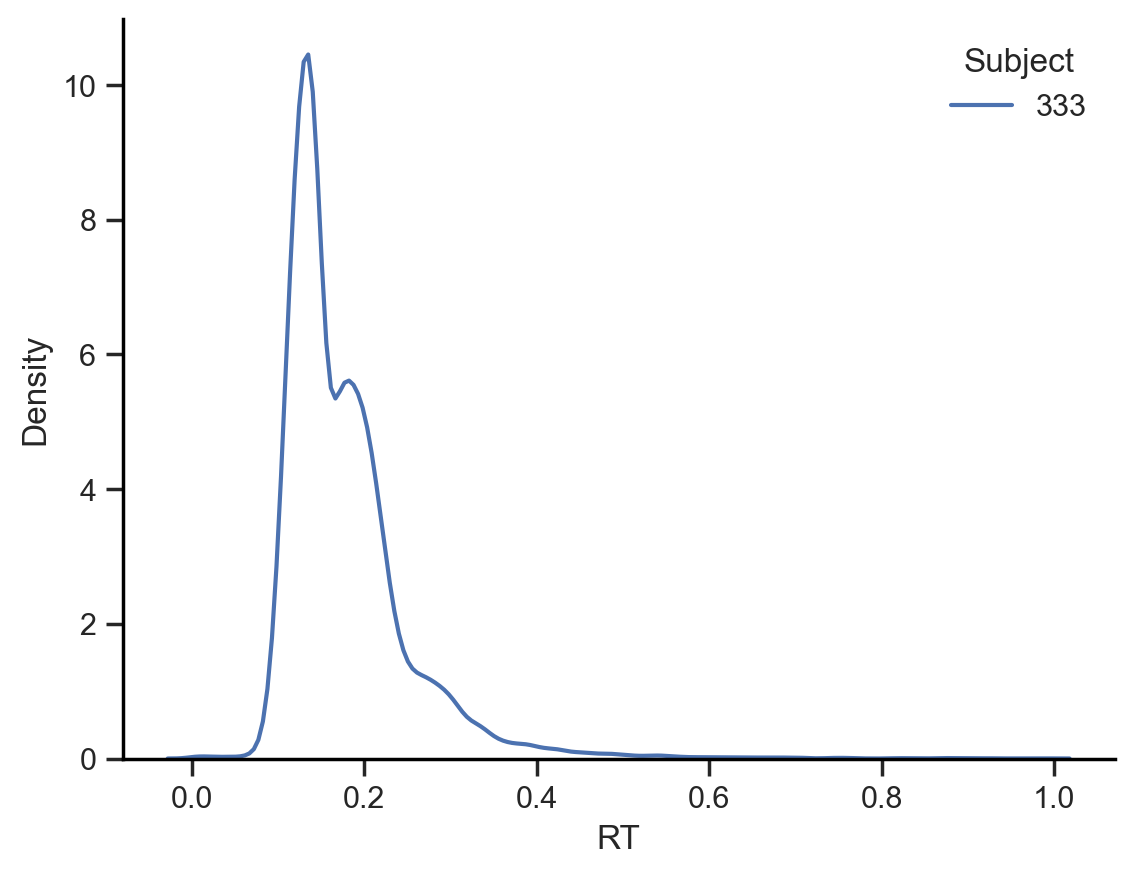

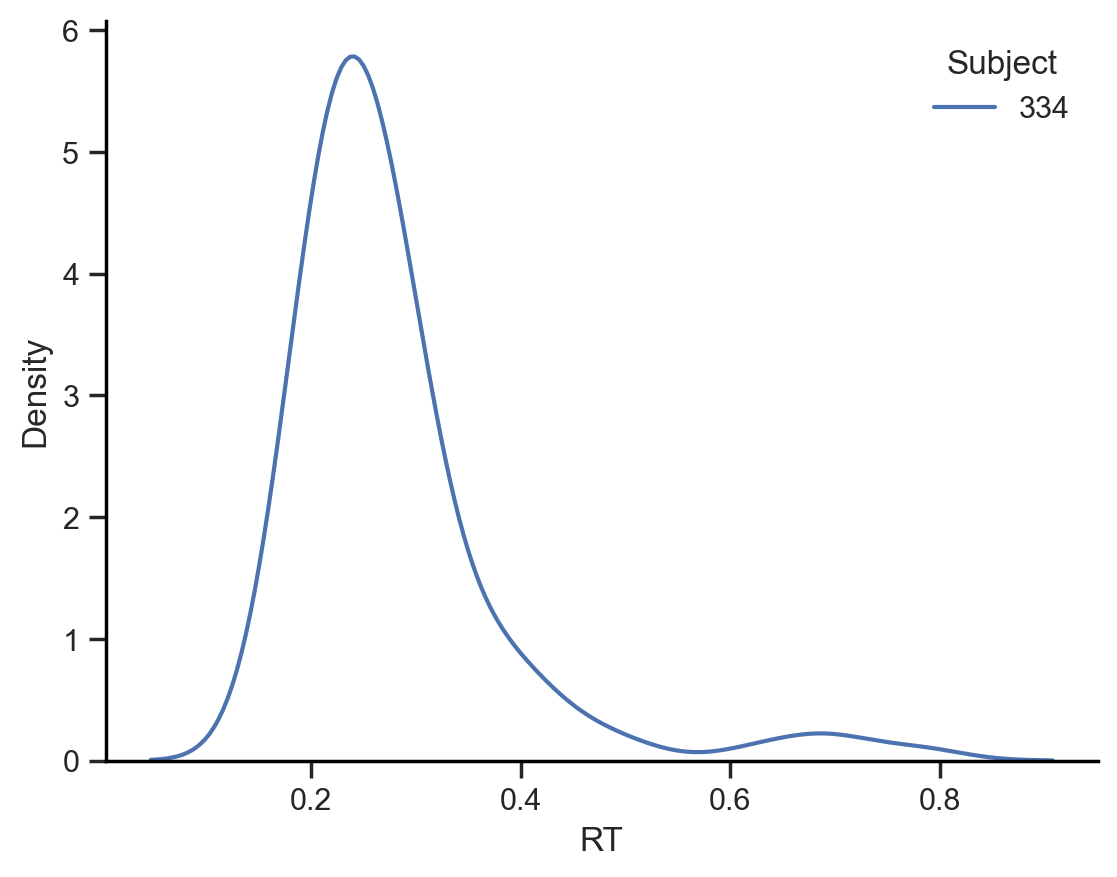

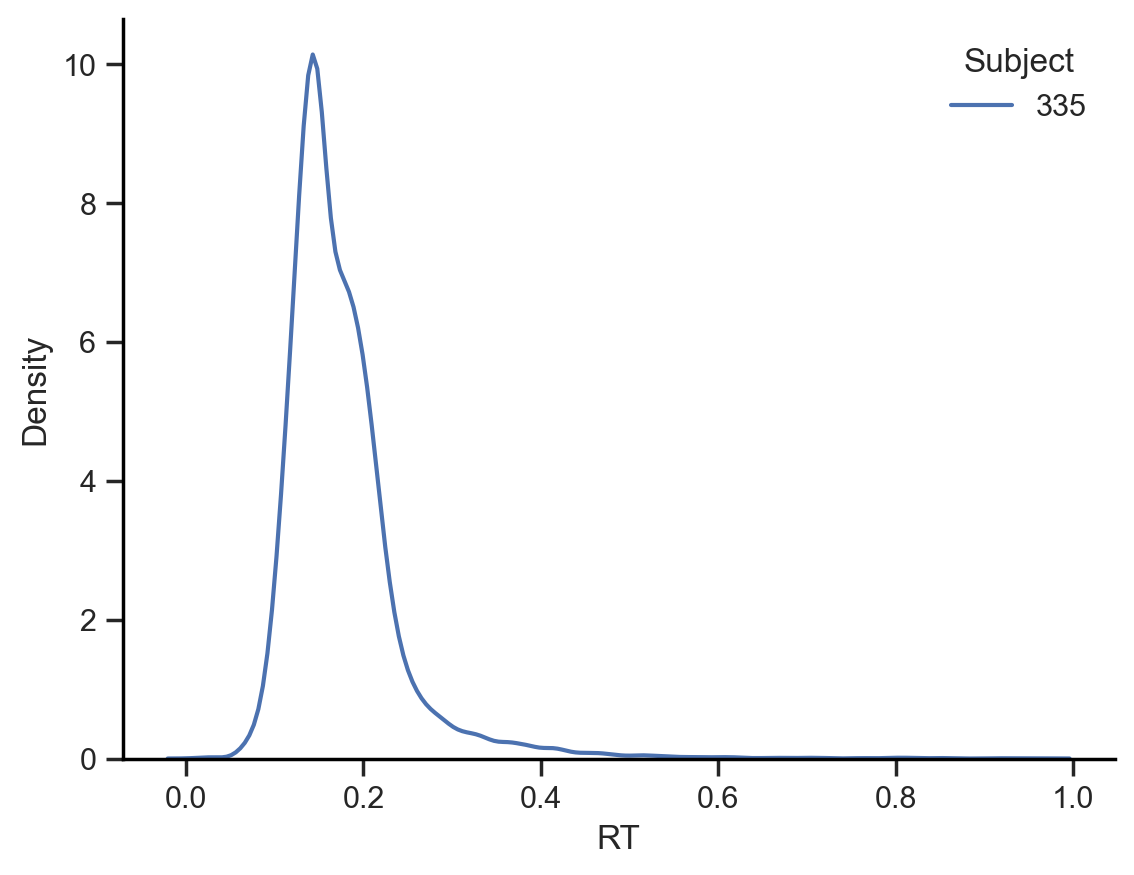

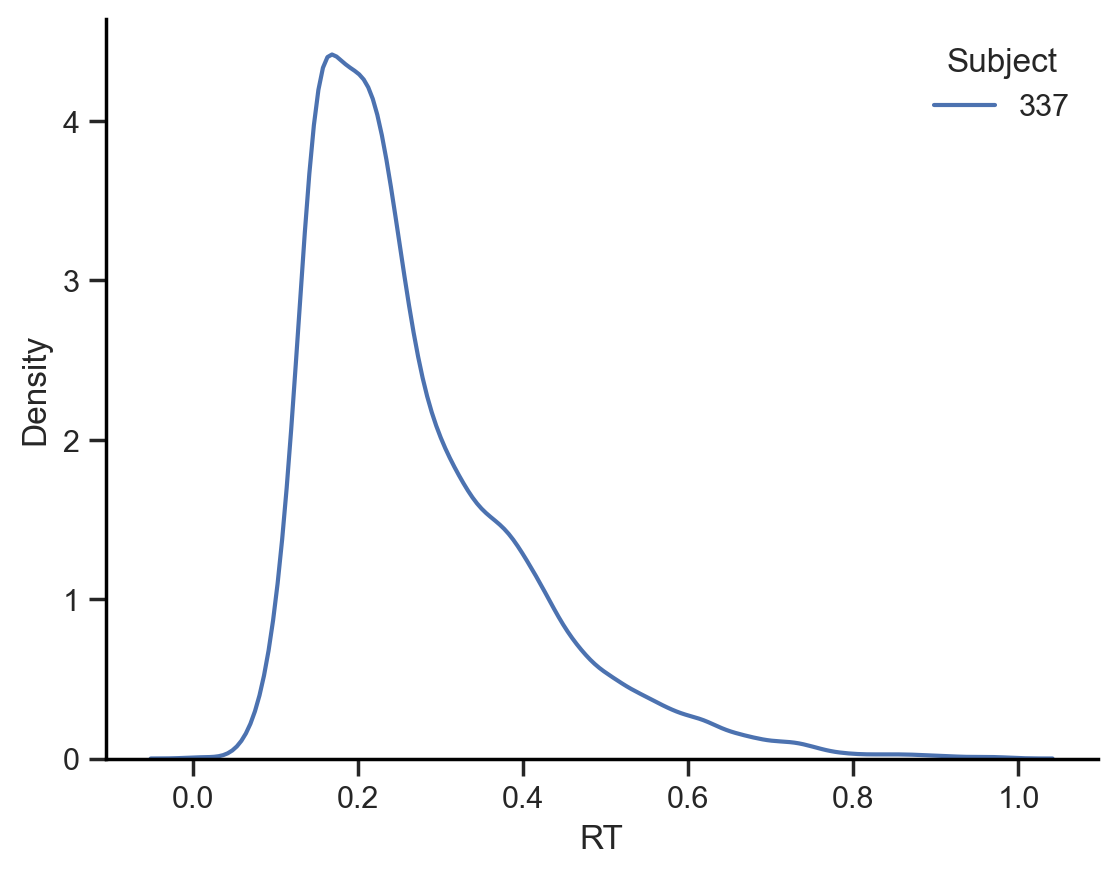

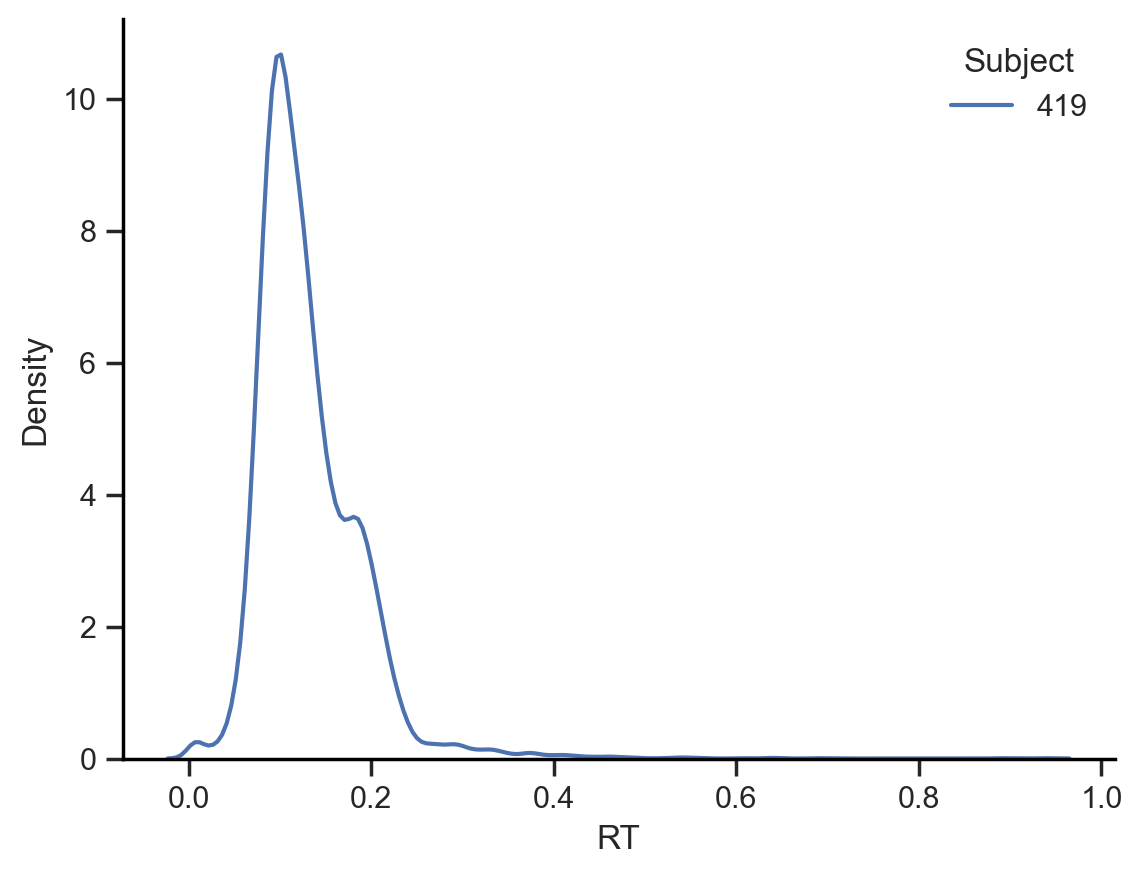

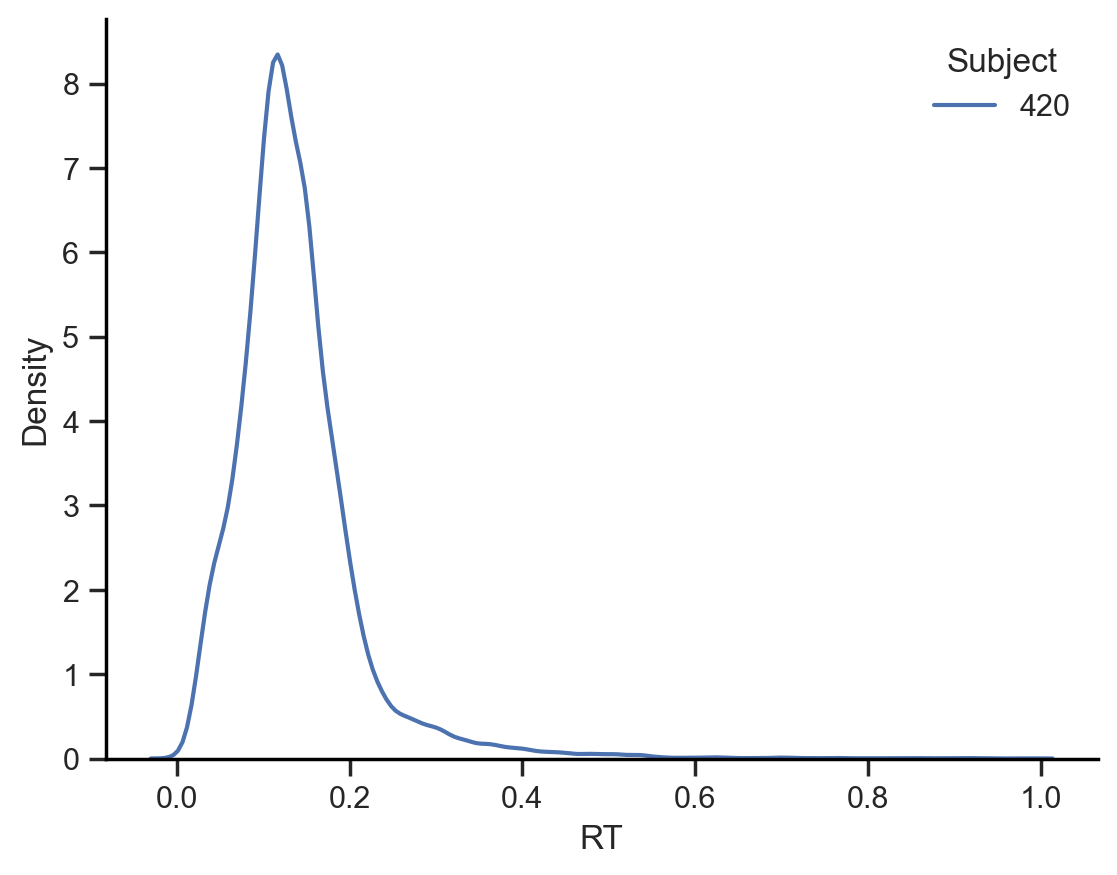

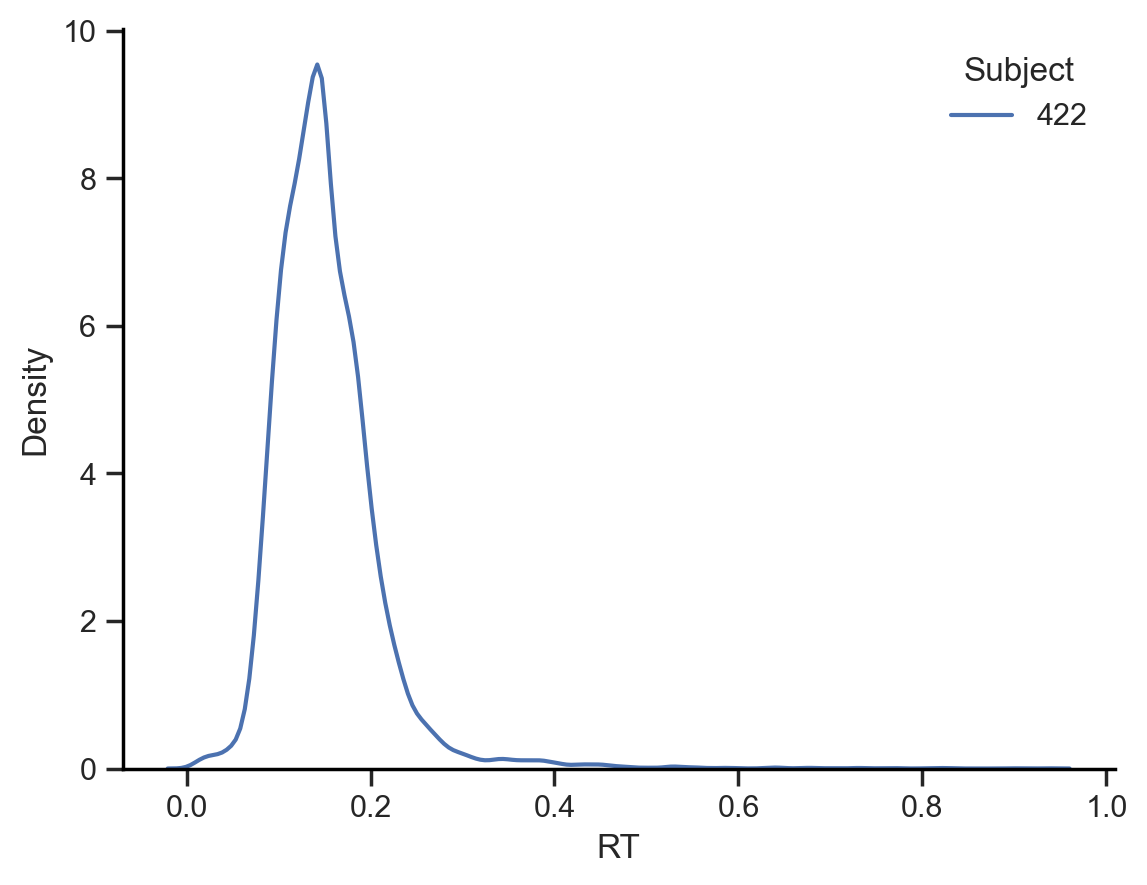

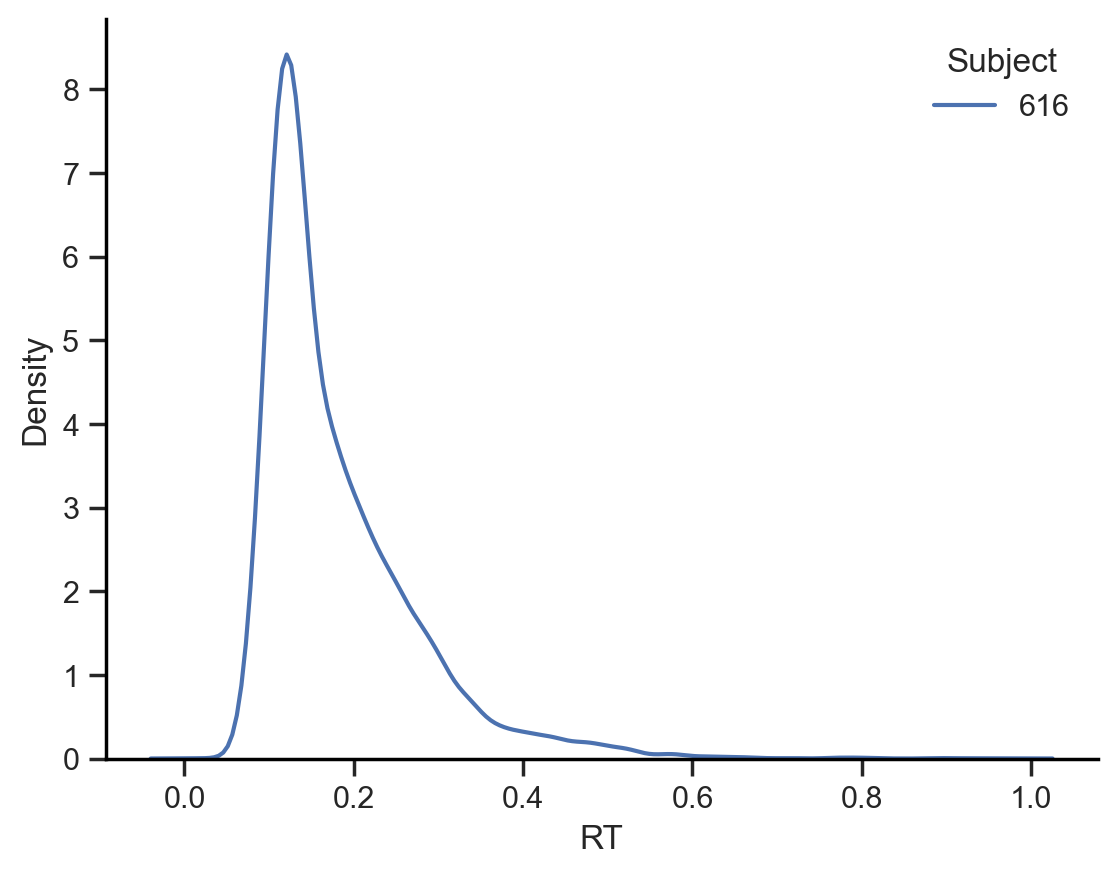

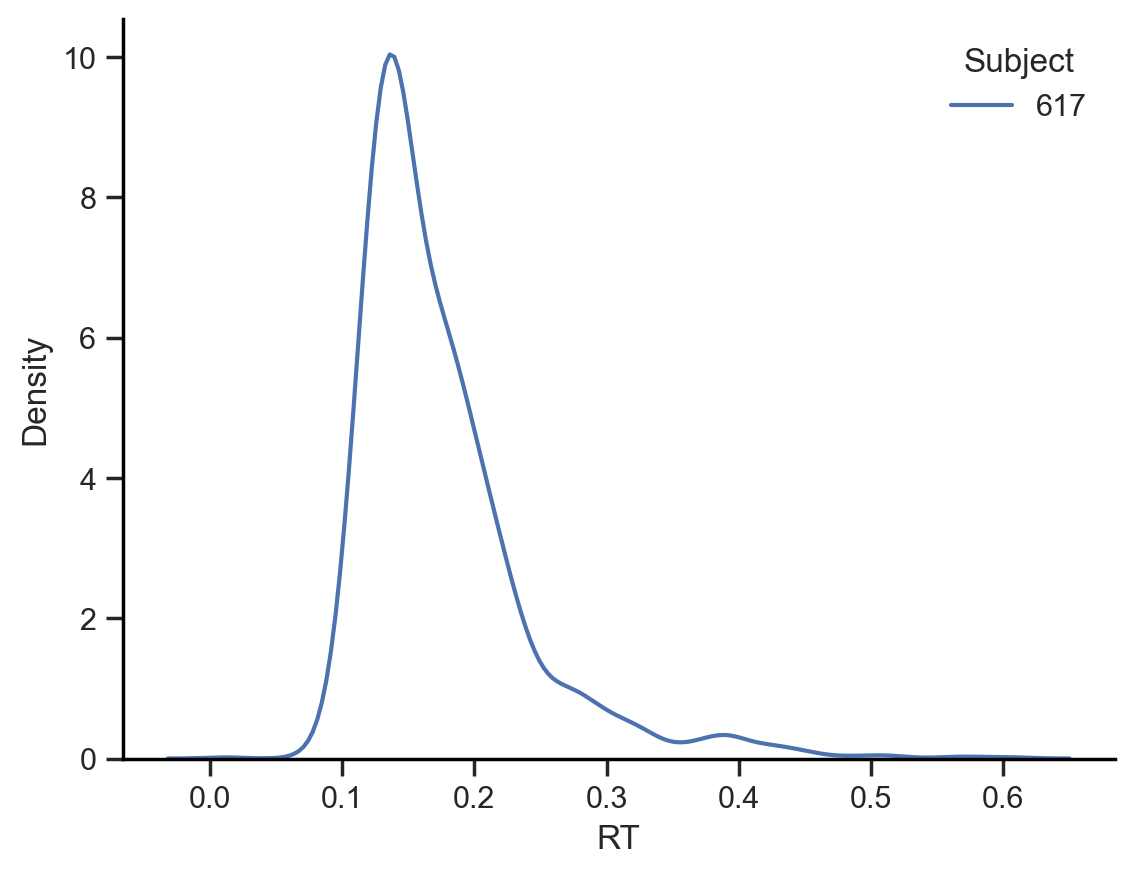

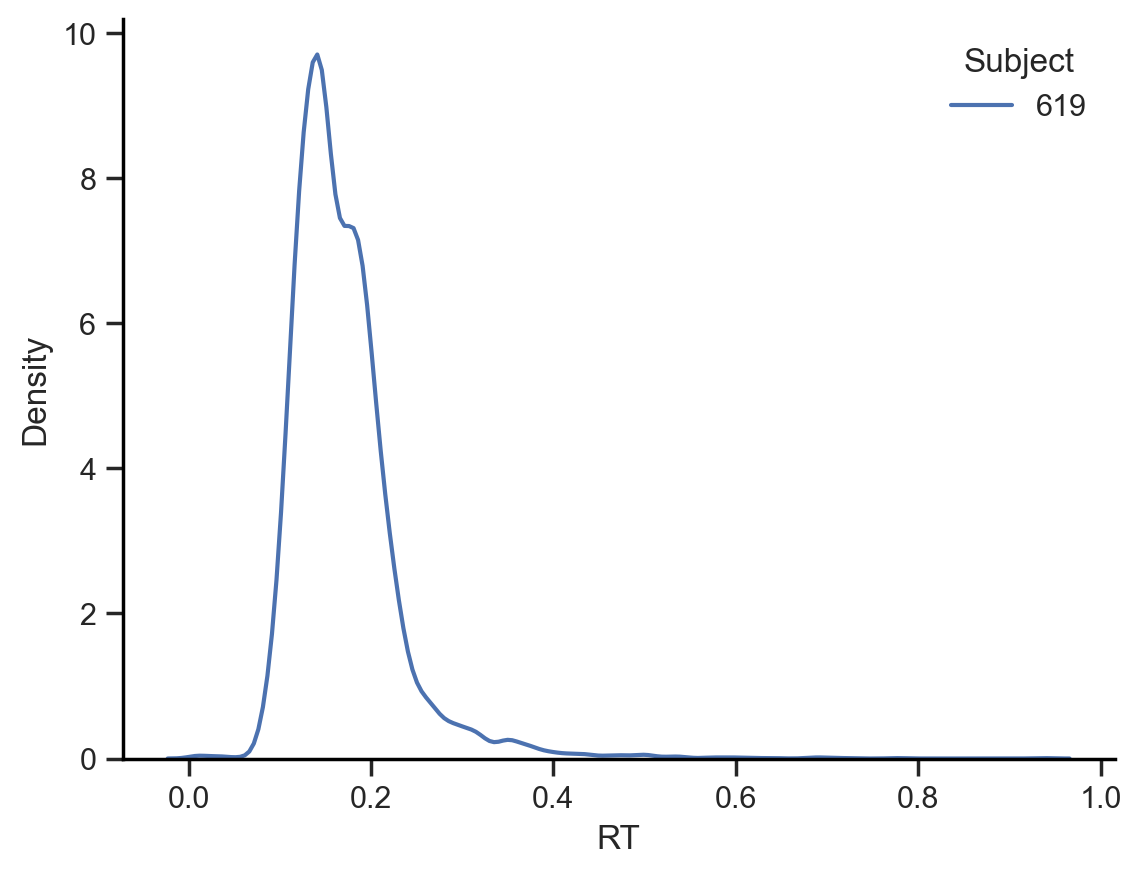

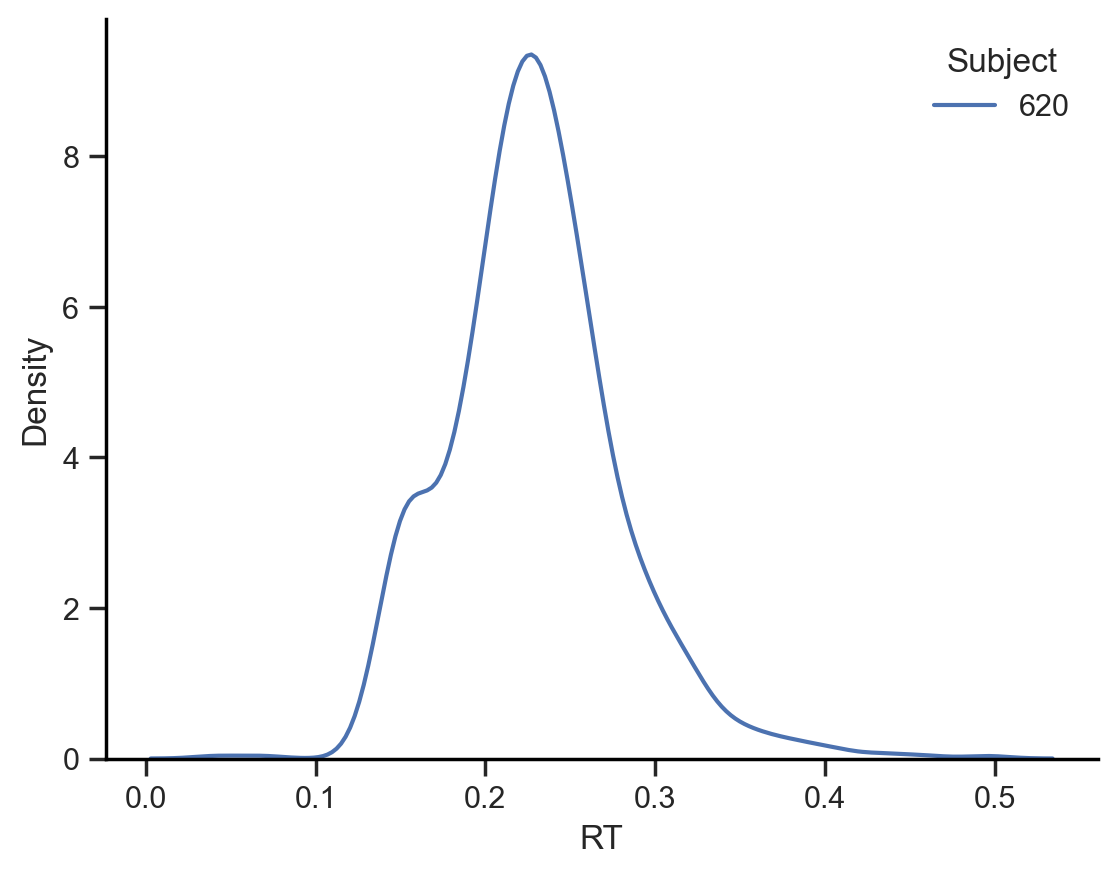

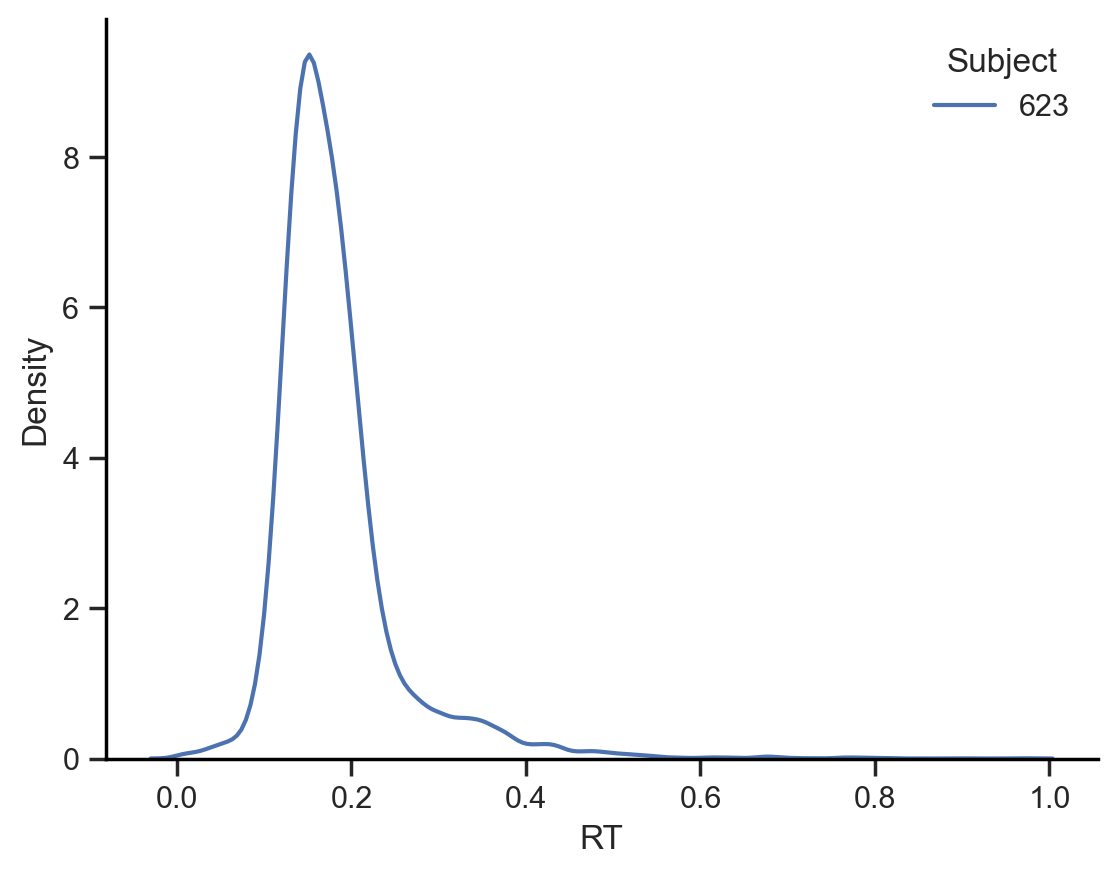

In [239]:
# Check the bimodality is present in every subject
for i in range(len(df_behavior.Subject.unique())):
    subject = df_behavior.Subject.unique()[i]
    df_subject = df_behavior[df_behavior.Subject == subject]
    plt.figure()
    sns.kdeplot(df_subject.RT, label=subject)
    plt.xlabel('RT')
    plt.ylabel('Density')
    plt.legend(loc='upper right', frameon=False, title='Subject')
    sns.despine()

### Hidden Markov Model (HMM)

Another possibility is that the bimodality reflects the a change in the internal state of the animal (e.g. motivation, reduced by satiation as time passes) that is not captured by the behavioral variables. To examine this, we can split the data of each session into first and second half and plot the RT distribution for each half. If the bimodality is driven by a change in the internal state of the animal, we would expect to see a difference in the RT distribution between the first and second half of the session.

## Chronometric Curves

### All trials

   absILD        RT
0     0.0  0.186289
1     2.0  0.187186
2     4.0  0.185685
3     8.0  0.184547
4    70.0  0.182010


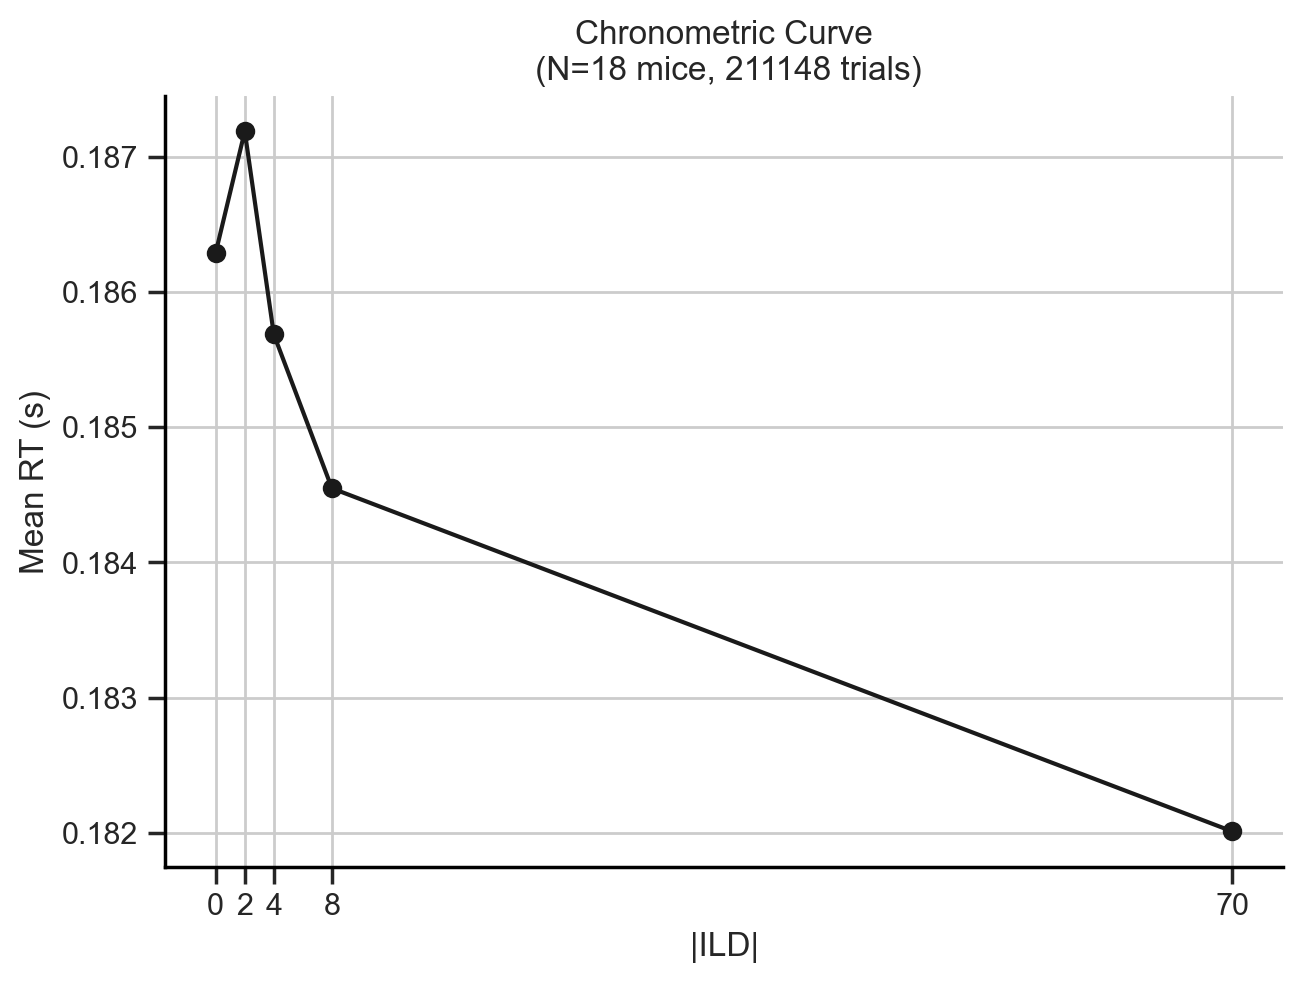

In [240]:
plot_chrono_curve(df_behavior, absolute=True)

### Splits

#### Outcome

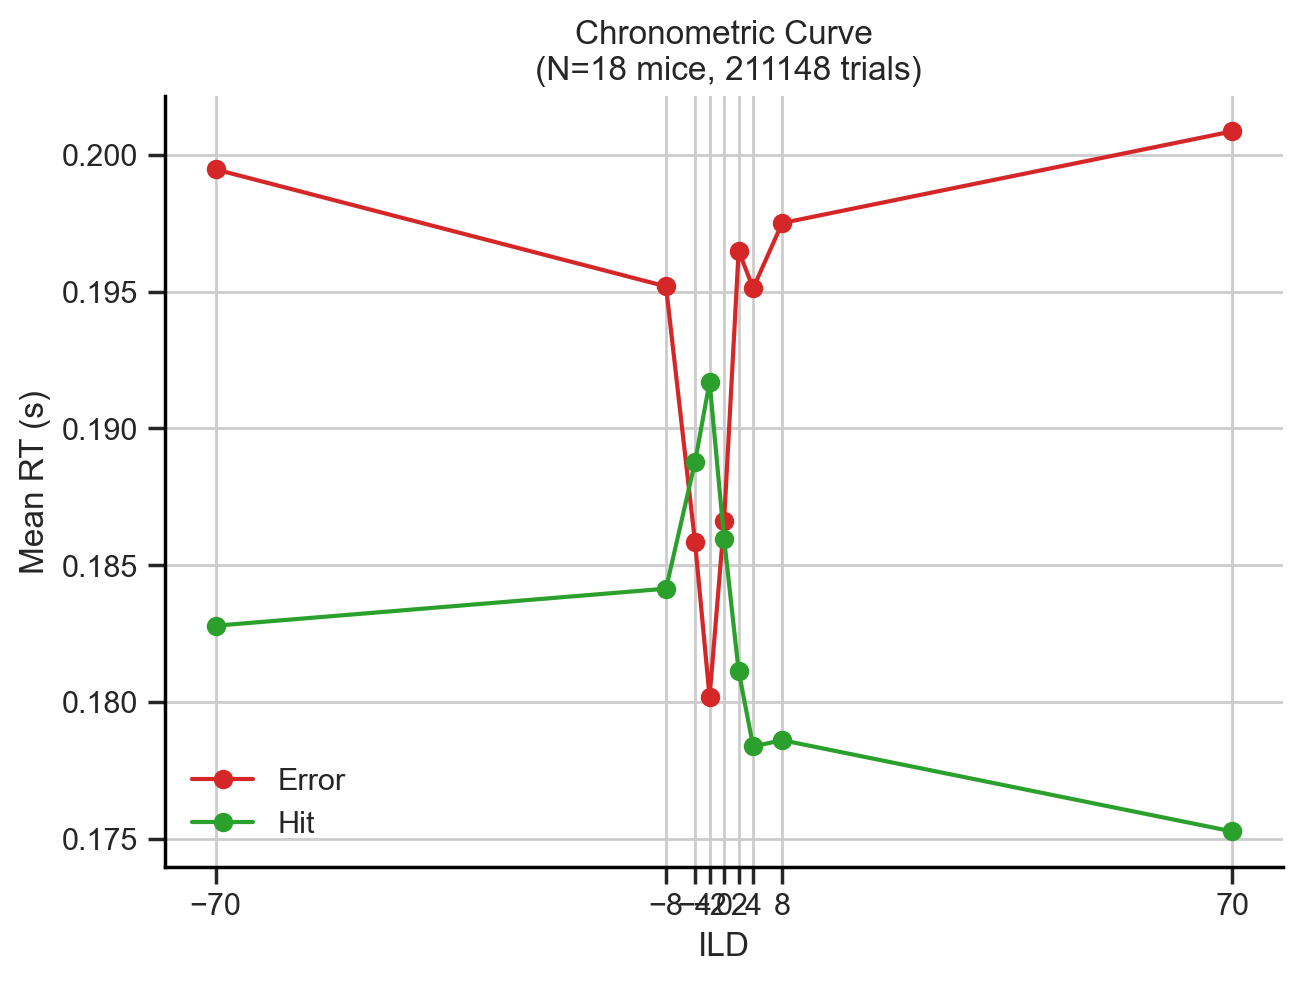

In [241]:
plot_chrono_curve_split(df_behavior, split='outcome', absolute=False)

#### Choice

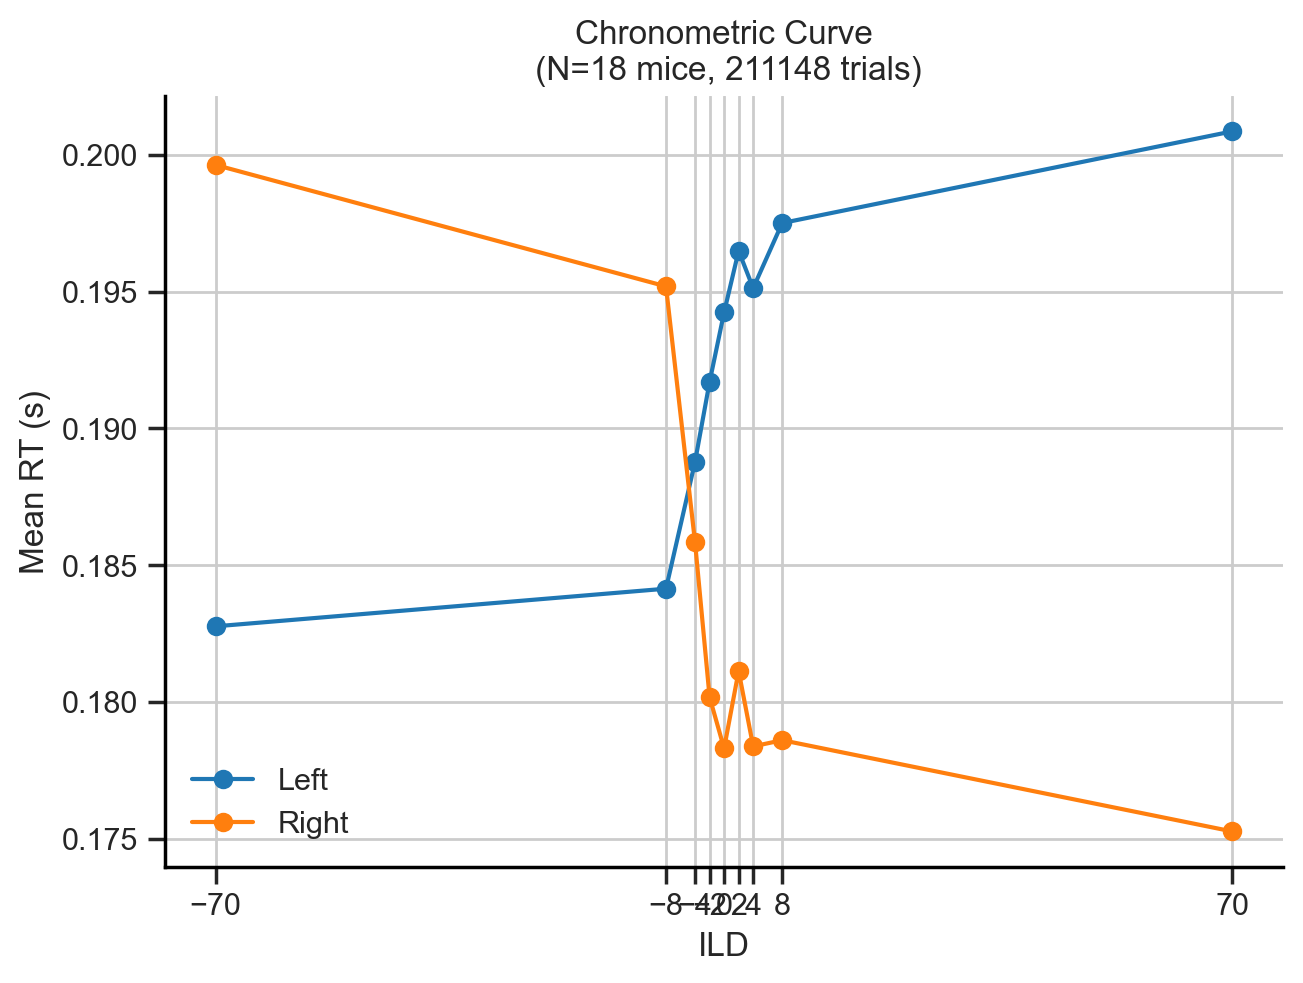

In [242]:
plot_chrono_curve_split(df_behavior, split='choice', absolute=False)

#### Stimulus

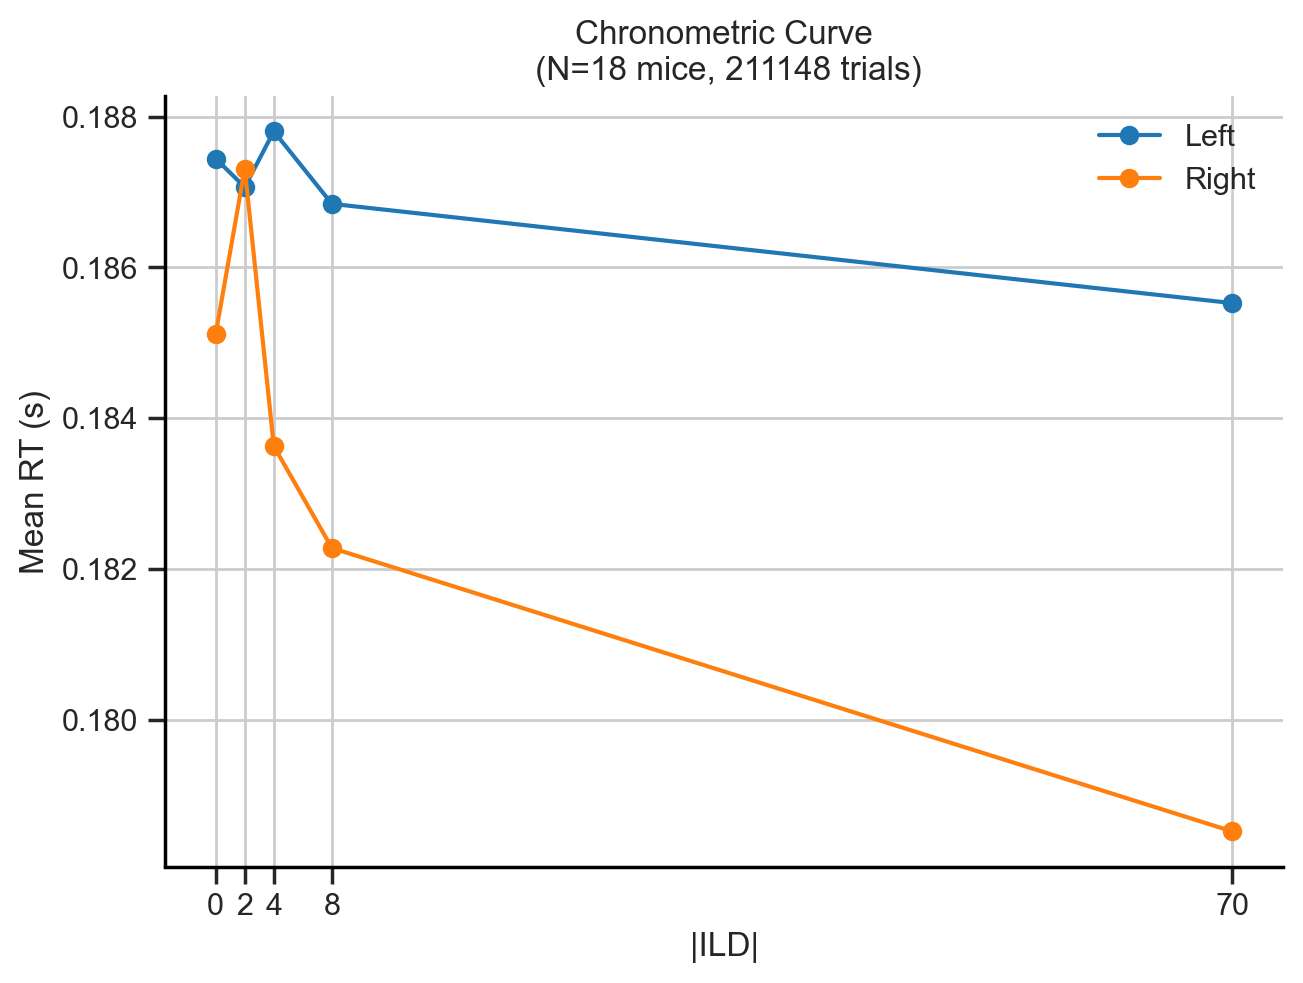

In [243]:
plot_chrono_curve_split(df_behavior, split='stim', absolute=True)

#### Repeat

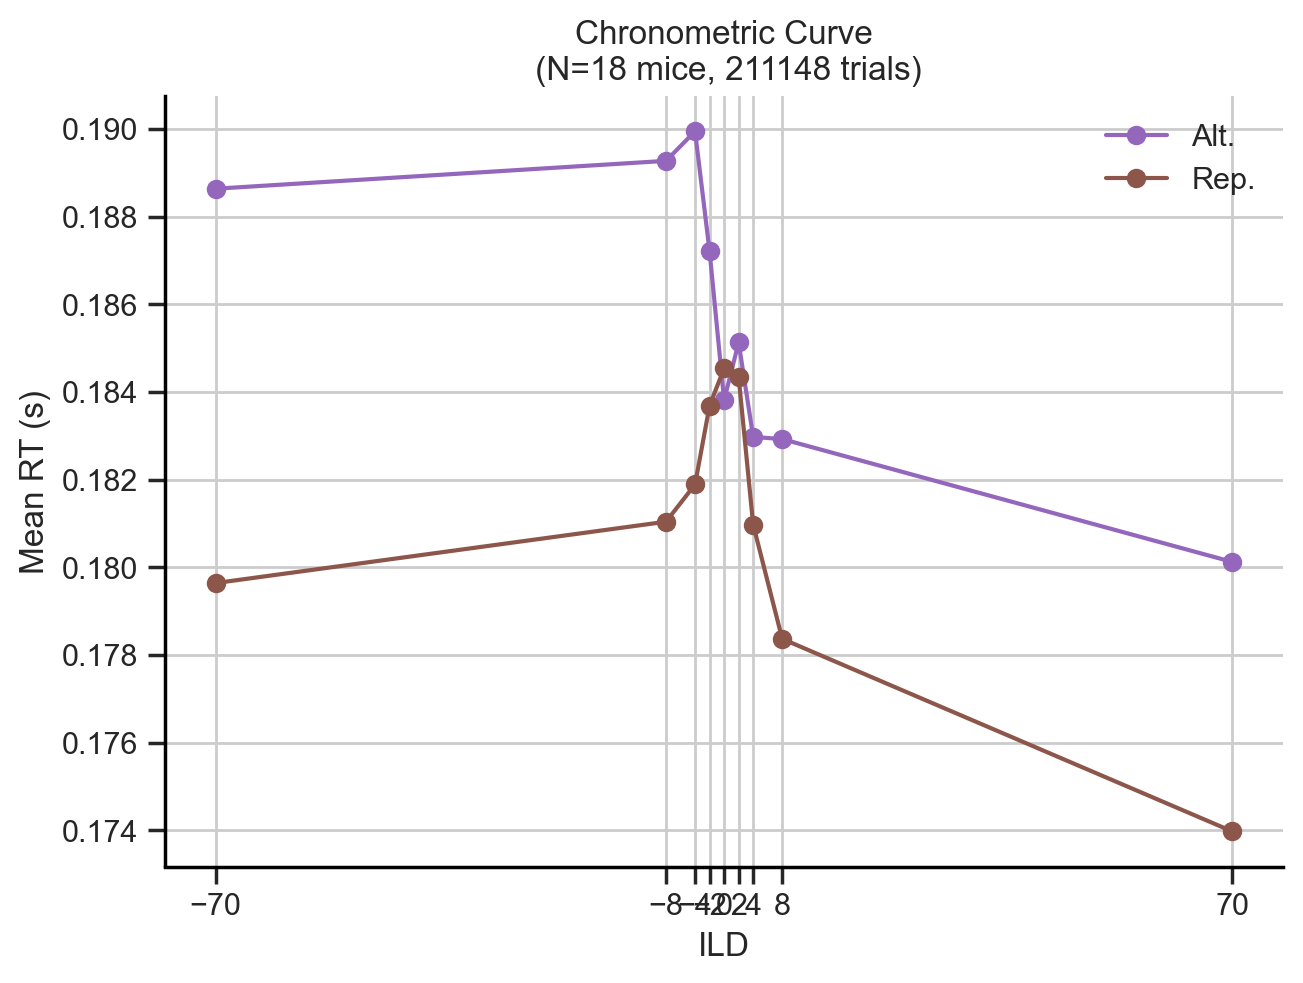

In [244]:
plot_chrono_curve_split(df_behavior, split='repeat', absolute=False)

#### Previous outcome

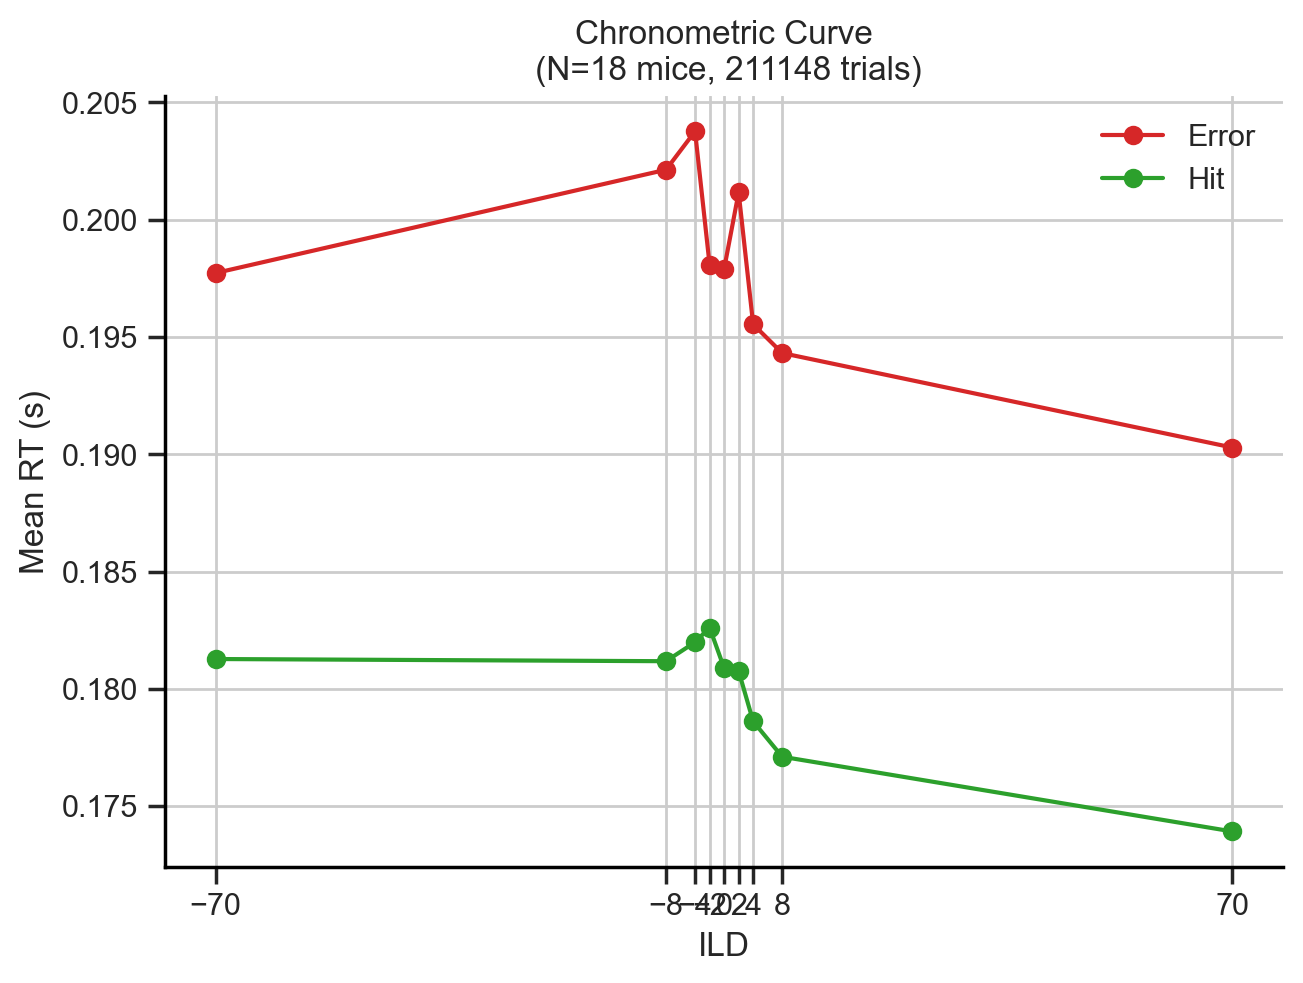

In [245]:
plot_chrono_curve_split(df_behavior, split='prev_out', absolute=False)

In [246]:
# # Plot licks PSTH
# bins, left_psth = compute_psth(licks_left, time_win=[-1, 3], bin_size=0.1)
# bins, right_psth = compute_psth(licks_right, time_win=[-1, 3], bin_size=0.1)
# bins = bins[:-1]  # Remove the last bin edge to match the histogram length
# plot_licks_psth(bins, licks_left, licks_right)

# Lick Rate

As the number of licks depends on the time the lickport was available (motor in), which ultimately depends on the outcome (correct vs error), a time window to count the licks needed to be established. As the time to collect water in correct (rewarded) trials was always 1 s, and the timeout period following error trials varied from 2-5 s, the chosen time window to count the number of licks was 1 s. This is very convenient for the lick rate, as it is defined as

$$
\text{Lick rate} = \frac{N_{\text{licks}}}{\text{time (s)}}
$$

so that N licks = Lick Rate

## All trials

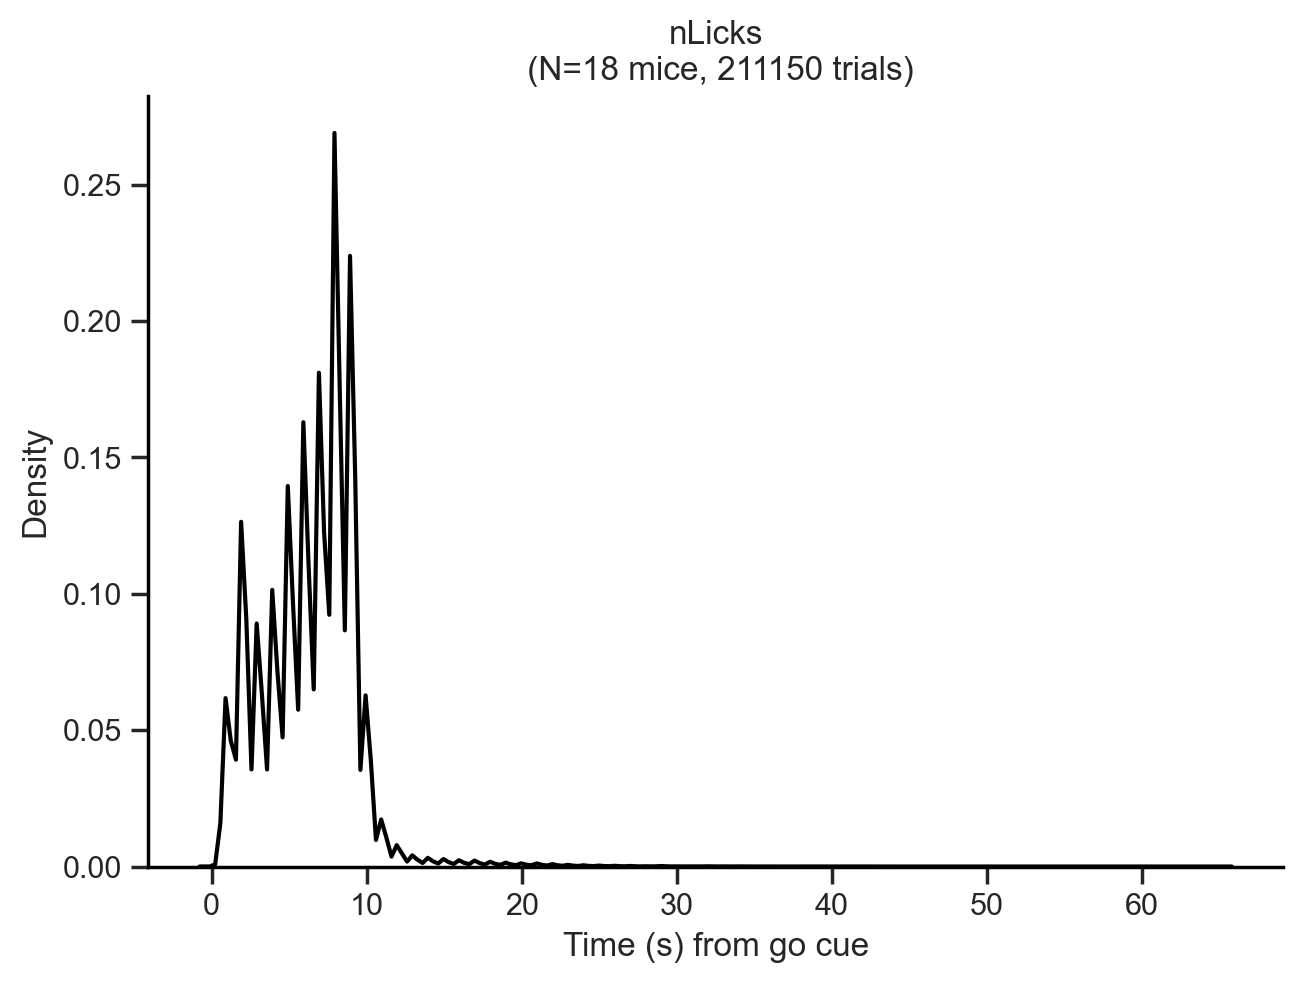

In [55]:
plot_licks_dist(df_behavior, var='nLicks', density=True)

We can observe a first peak at 0 licks (error trials), and an sawtooth increasing second peak with max at 8 licks (correct trials). Let's split the data into several variables (like with RT) to observe how they modulate the lick rate.

## Splits

### ILD

ILD 70: peak nLicks = 1.940 s
ILD 8: peak nLicks = 2.098 s
ILD 4: peak nLicks = 2.092 s
ILD 2: peak nLicks = 2.116 s
ILD 0: peak nLicks = 1.950 s
Mean nLicks = 2.039 s


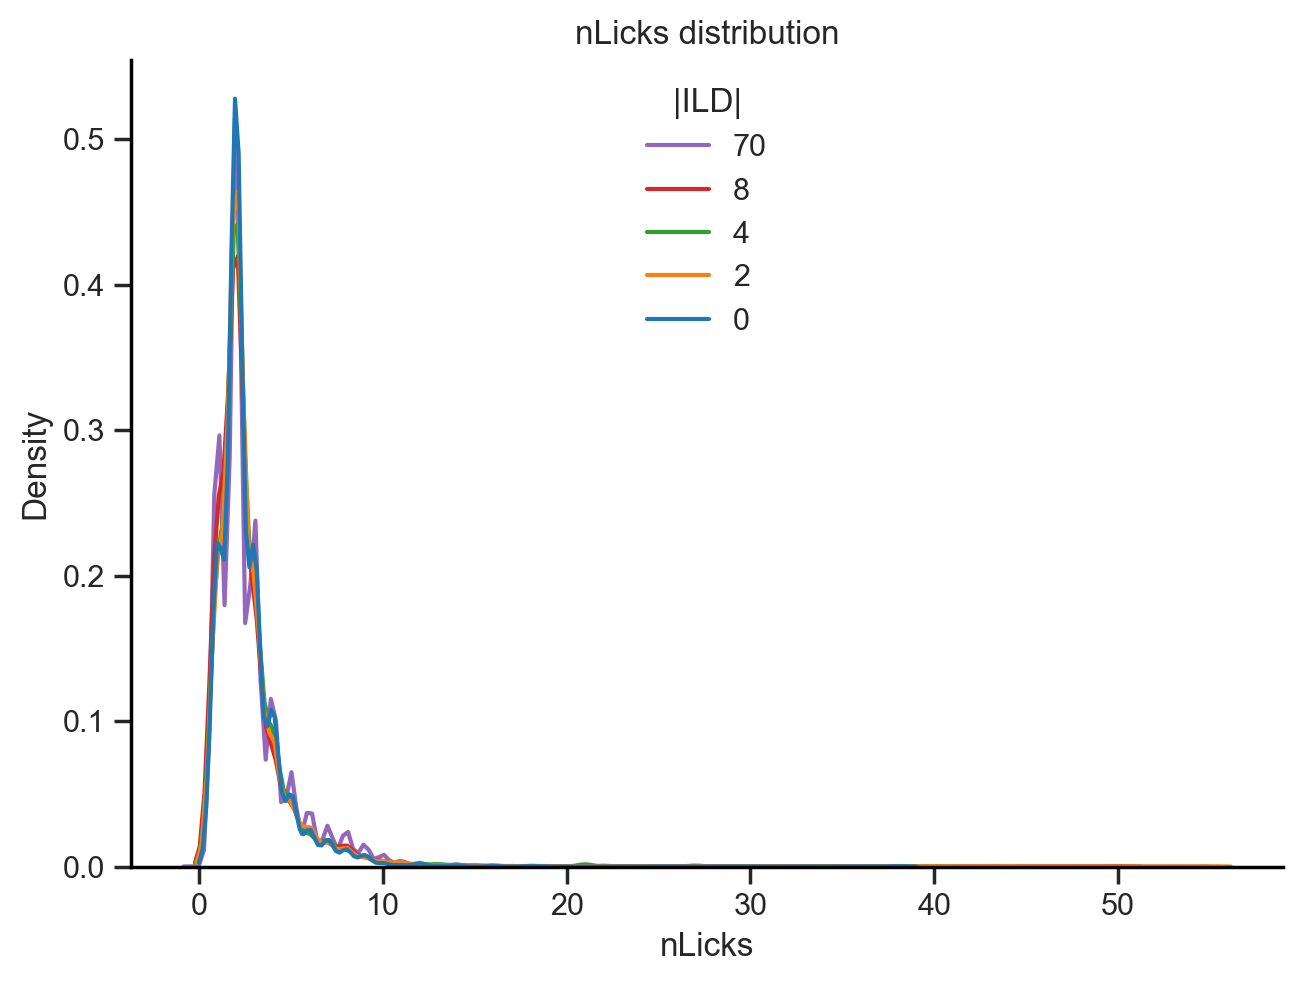

In [56]:
plot_ild_dist(df_behavior[df_behavior.Hit==0], var='nLicks')

As there was no water (reward) coming out of the spouts in error trials, it makes sense that the distribution of lick rate peaks at 0. It is a needed control, but from now on the analysis will focus on **correct trials only**

ILD 70: peak nLicks = 7.861 s
ILD 8: peak nLicks = 7.919 s
ILD 4: peak nLicks = 7.982 s
ILD 2: peak nLicks = 8.053 s
ILD 0: peak nLicks = 8.094 s
Mean nLicks = 7.982 s


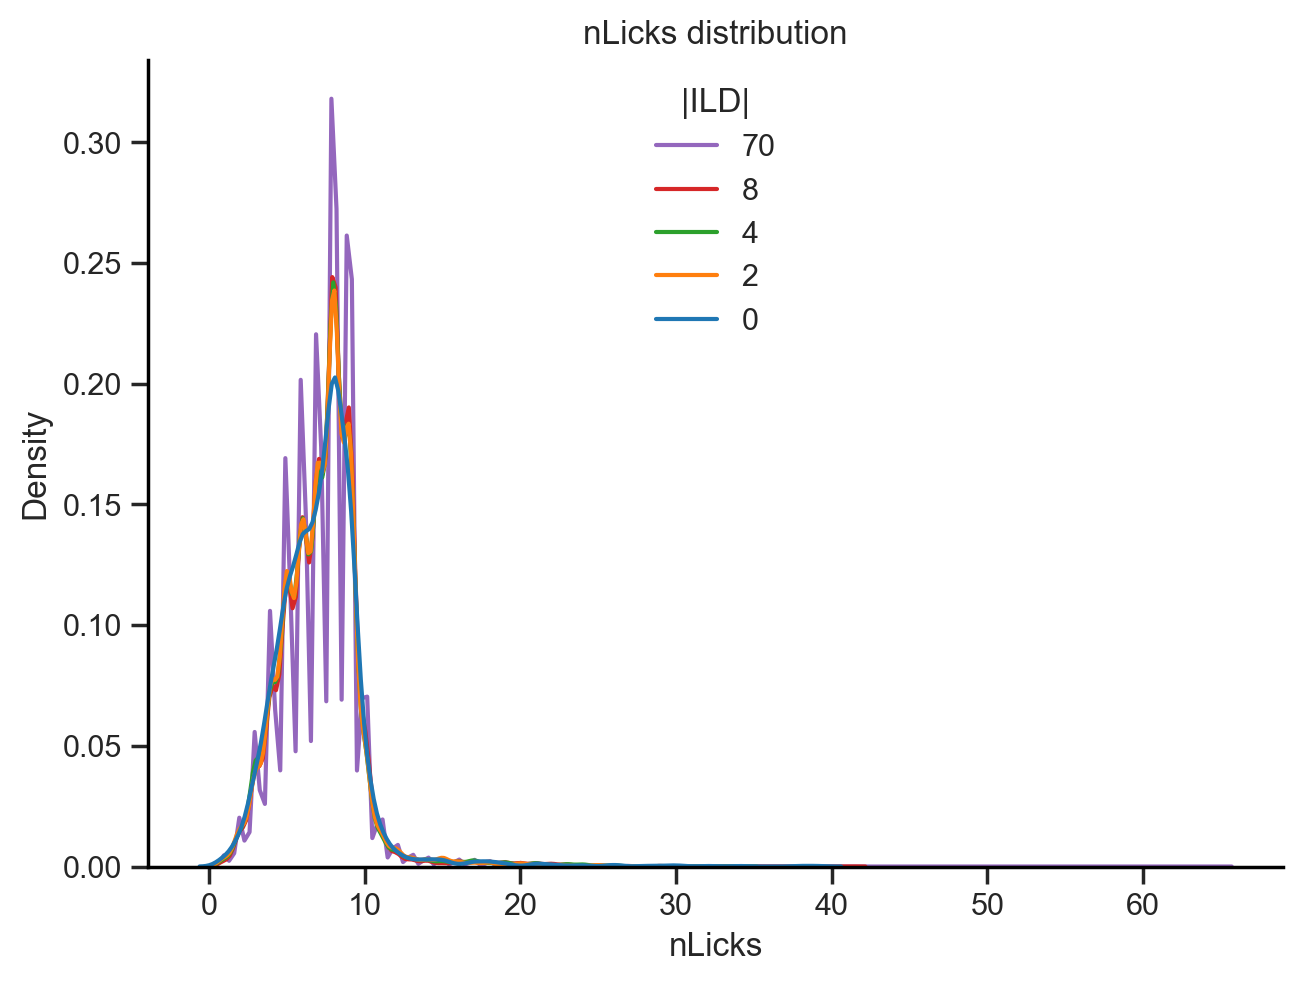

In [57]:
plot_ild_dist(df_behavior[df_behavior.Hit==1], var='nLicks')

There is a modulation in the lick rate by ILD in correct trials. The higher the ILD the higher the lick rate.

### Outcome

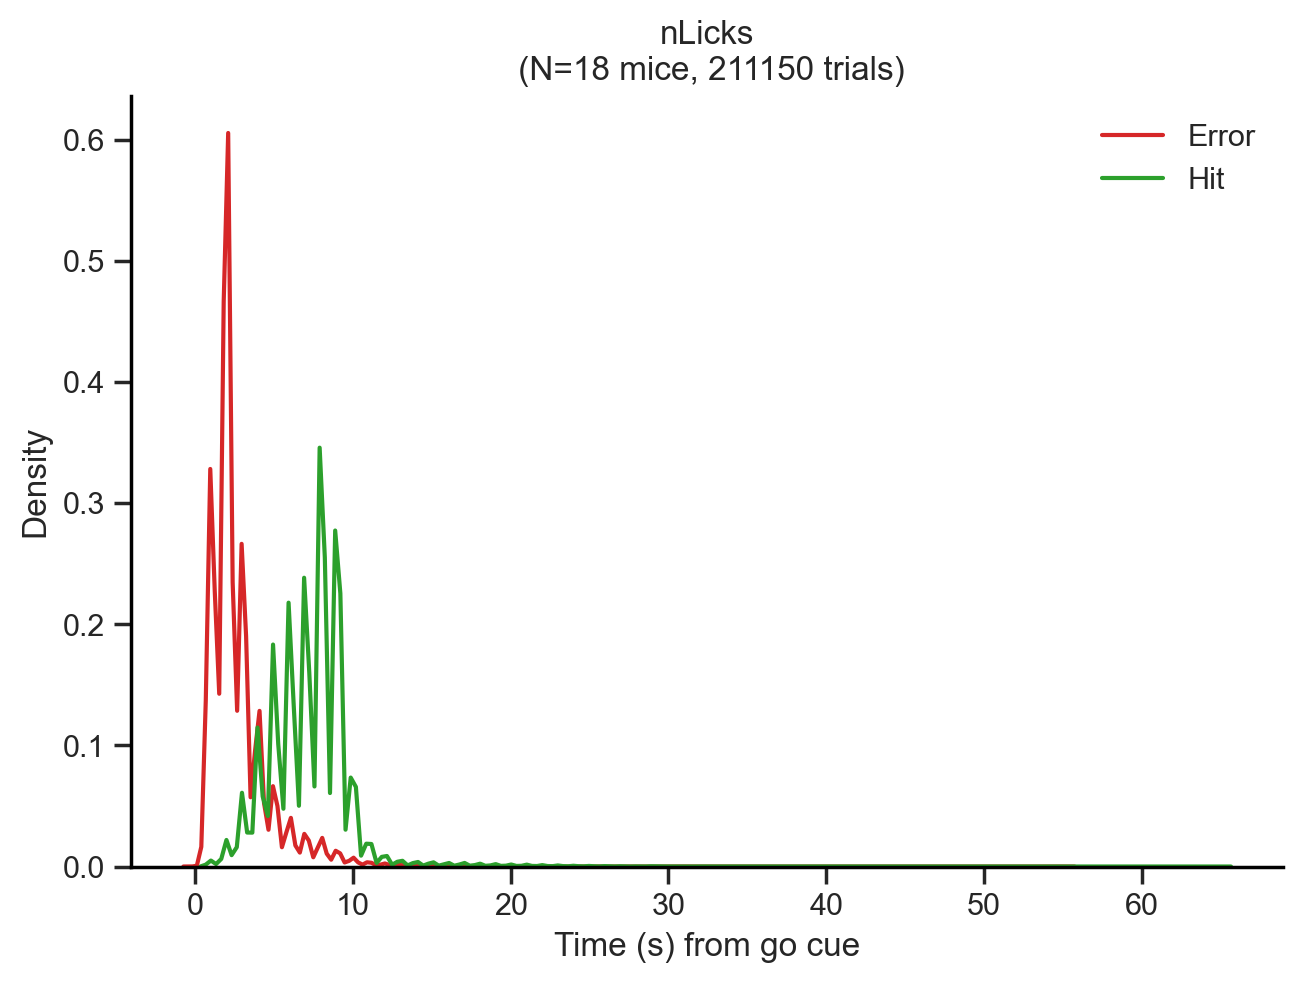

In [77]:
plot_licks_split(df_behavior, var='nLicks', split='outcome', kind='kde')

### Previous outcome

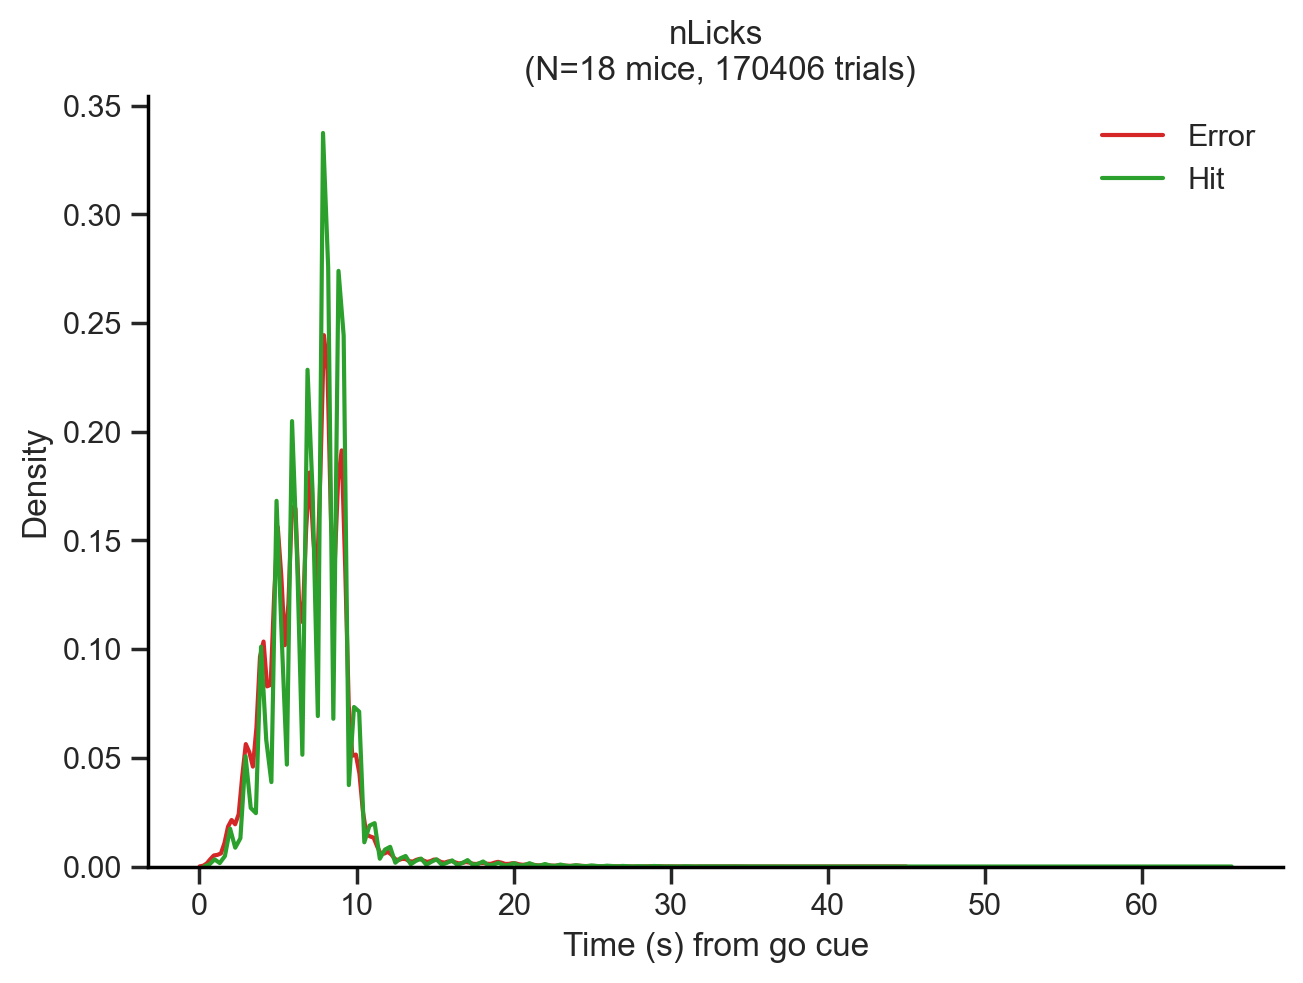

In [79]:
plot_licks_split(df_behavior[df_behavior.Hit==1], var='nLicks', split='prev_out', kind='kde')

### Choice

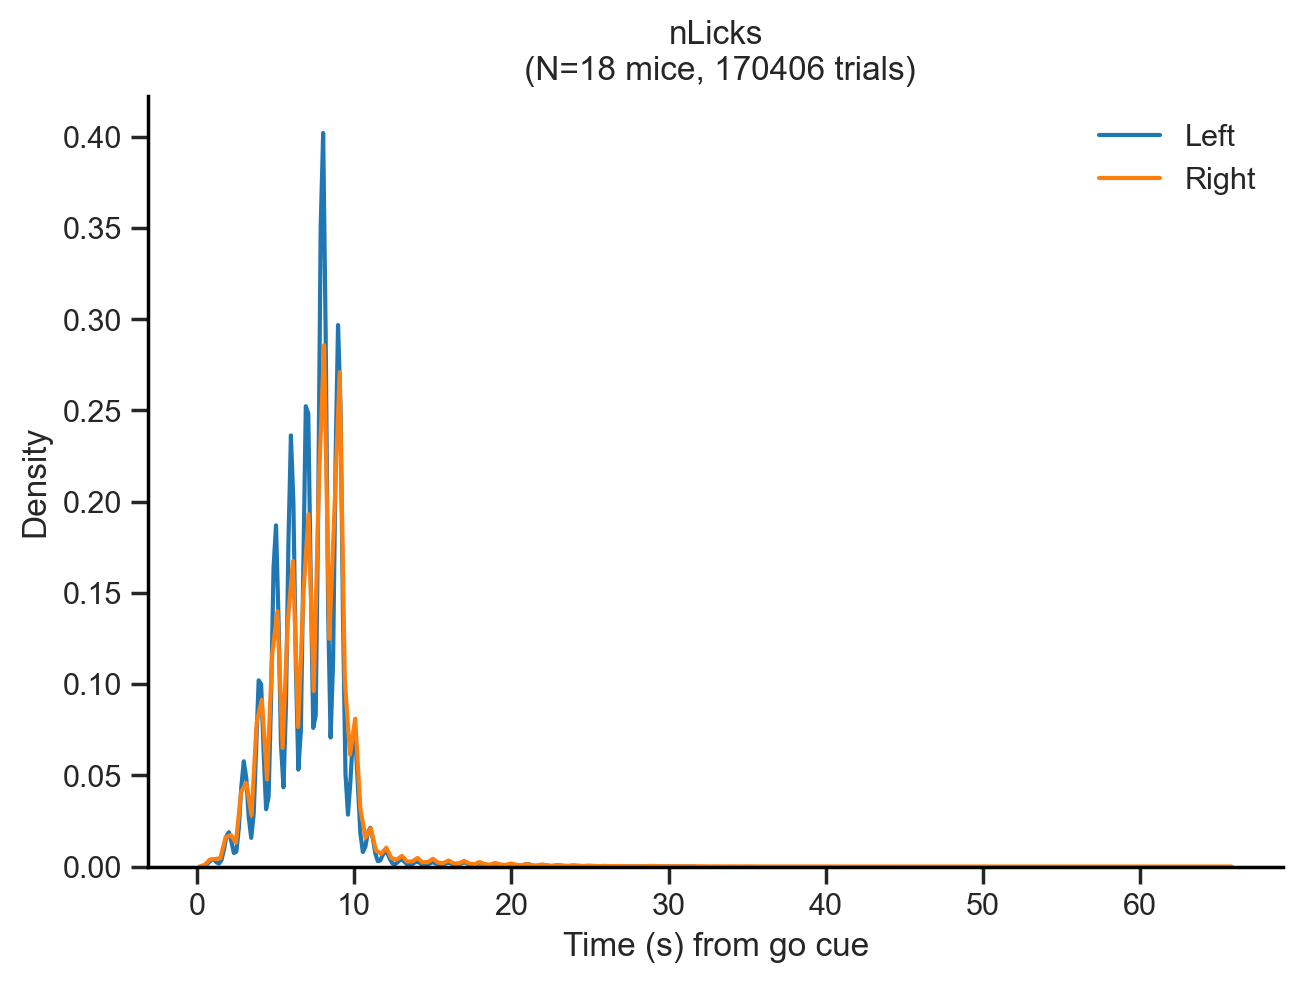

In [80]:
plot_licks_split(df_behavior[df_behavior.Hit==1], var='nLicks', split='choice', kind='kde')

### Repeat choice

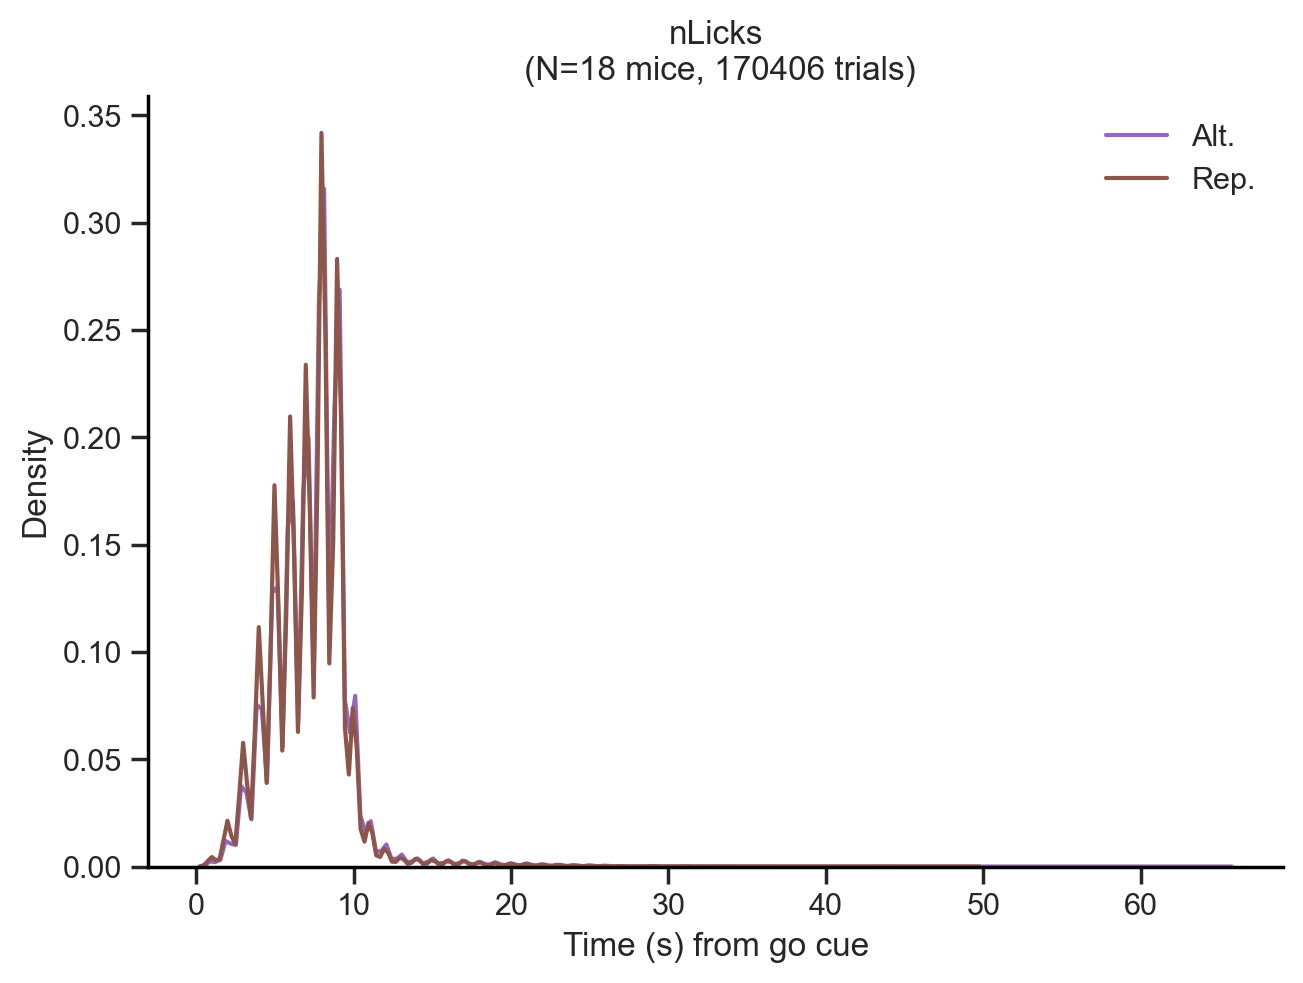

In [81]:
plot_licks_split(df_behavior[df_behavior.Hit==1], var='nLicks', split='rep_choice', kind='kde')

### Repeat trial

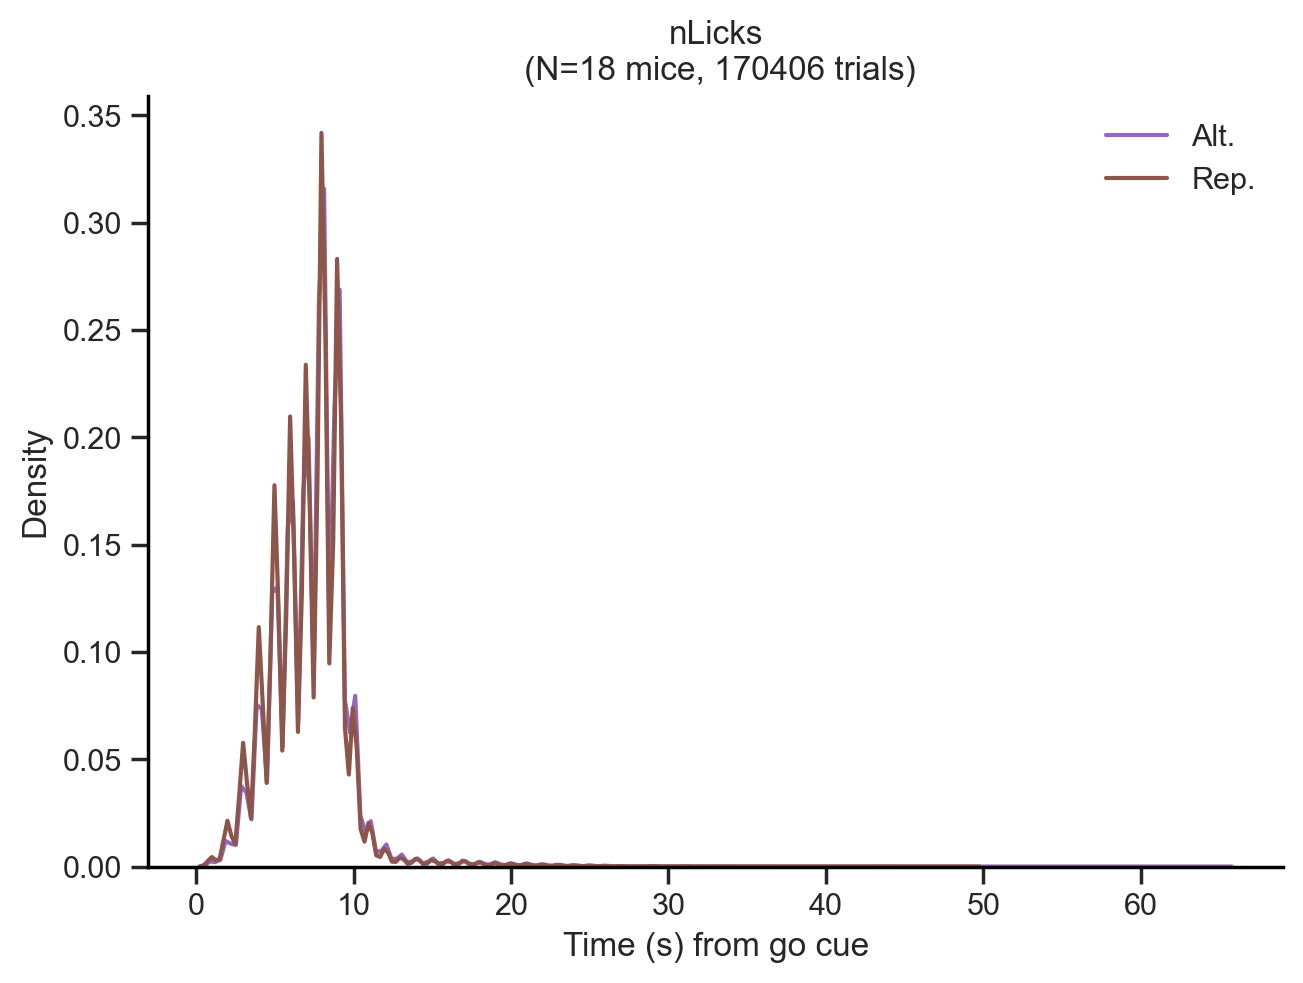

In [82]:
plot_licks_split(df_behavior[df_behavior.Hit==1], var='nLicks', split='rep_trial', kind='kde')

### Stimulus

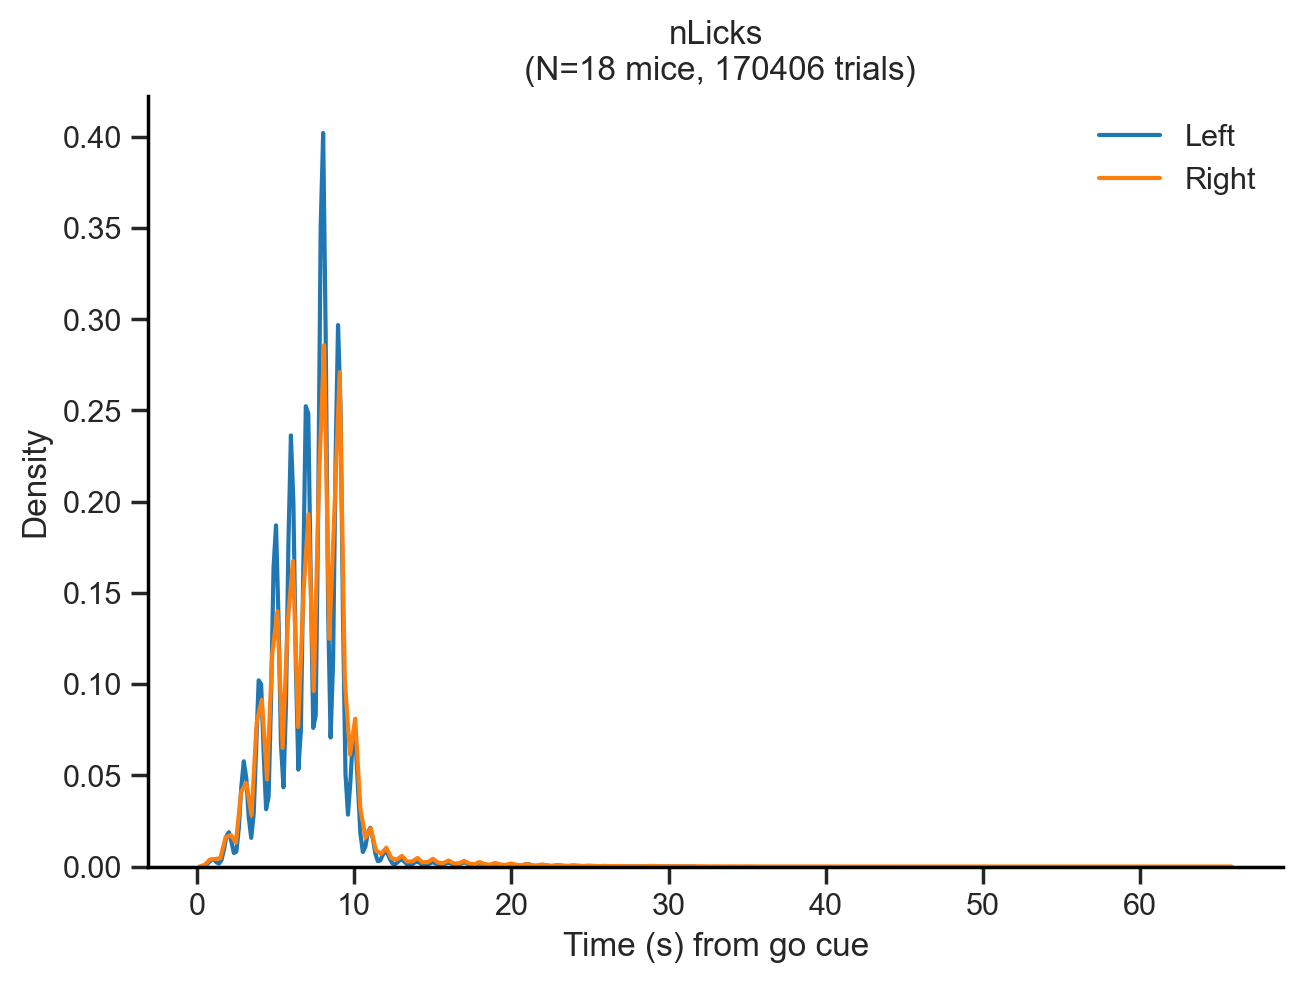

In [83]:
plot_licks_split(df_behavior[df_behavior.Hit==1], var='nLicks', split='stim', kind='kde')

### 1st vs 2nd session half

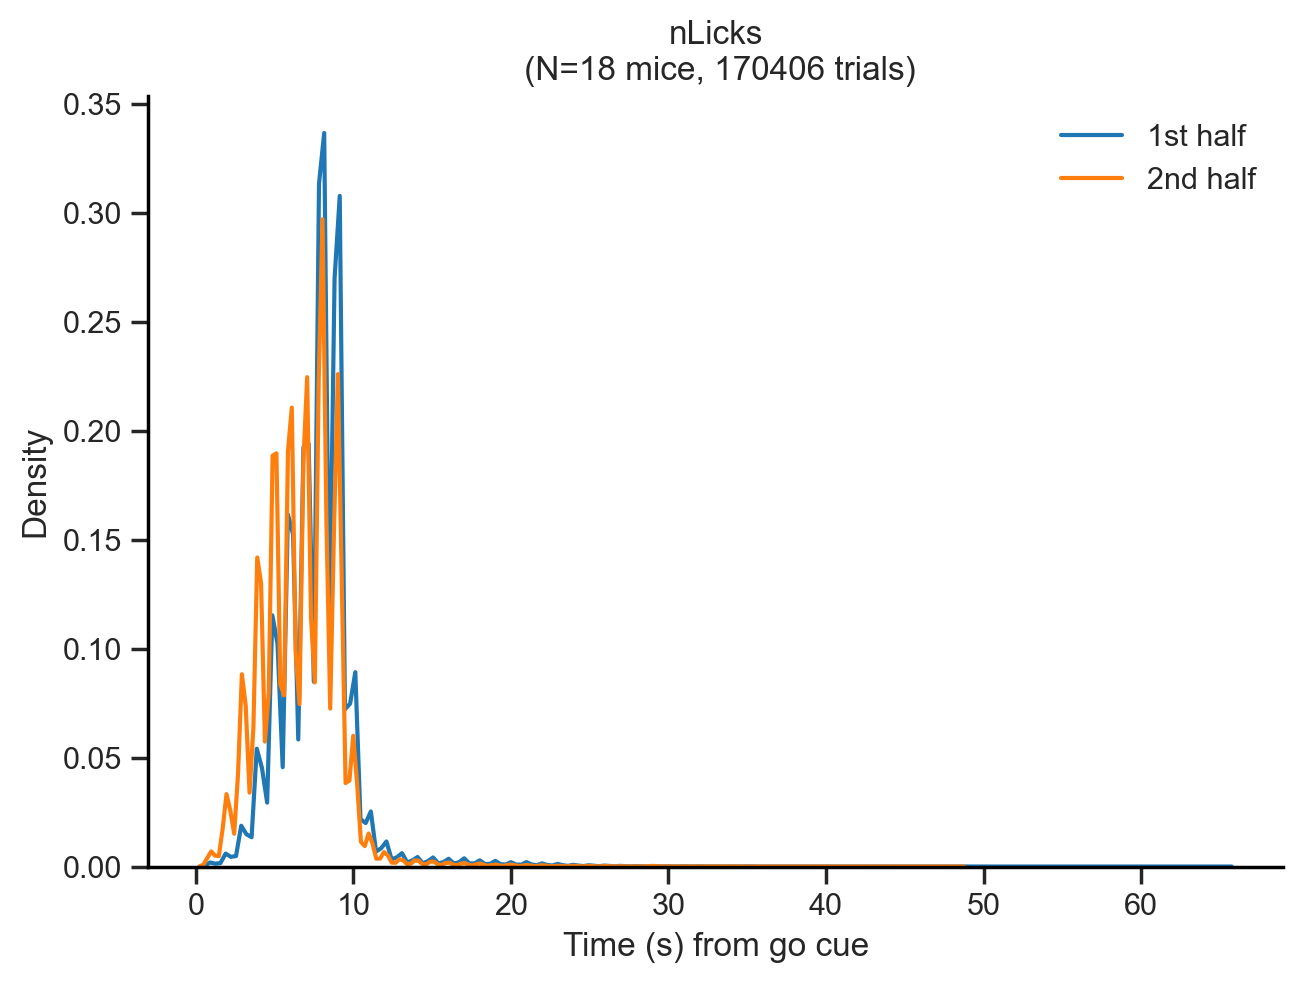

In [84]:
plot_licks_split(df_behavior[df_behavior.Hit==1], var='nLicks', split='half', kind='kde')

# Inter Lick Interval (ILI)

$$
\text{Lick rate (Hz)} \approx \frac{1}{\text{Mean ILI (s)}}
$$

### All trials

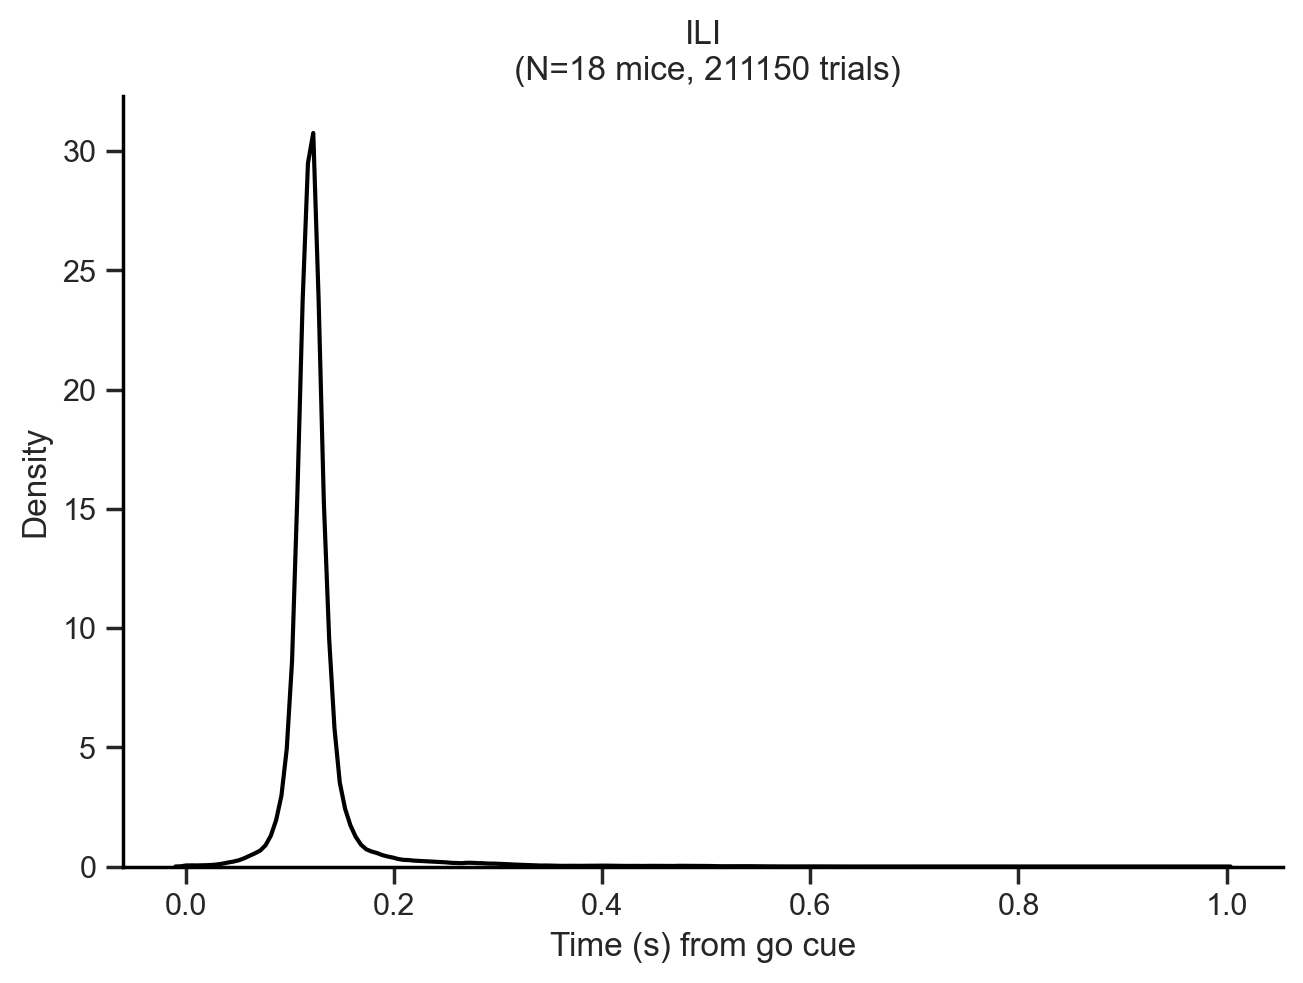

In [52]:
plot_licks_dist(df_behavior, var='ILI', density=True)

### Splits

#### ILD

ILD 70: peak ILI = 0.122 s
ILD 8: peak ILI = 0.120 s
ILD 4: peak ILI = 0.123 s
ILD 2: peak ILI = 0.123 s
ILD 0: peak ILI = 0.121 s
Mean ILI = 0.122 s


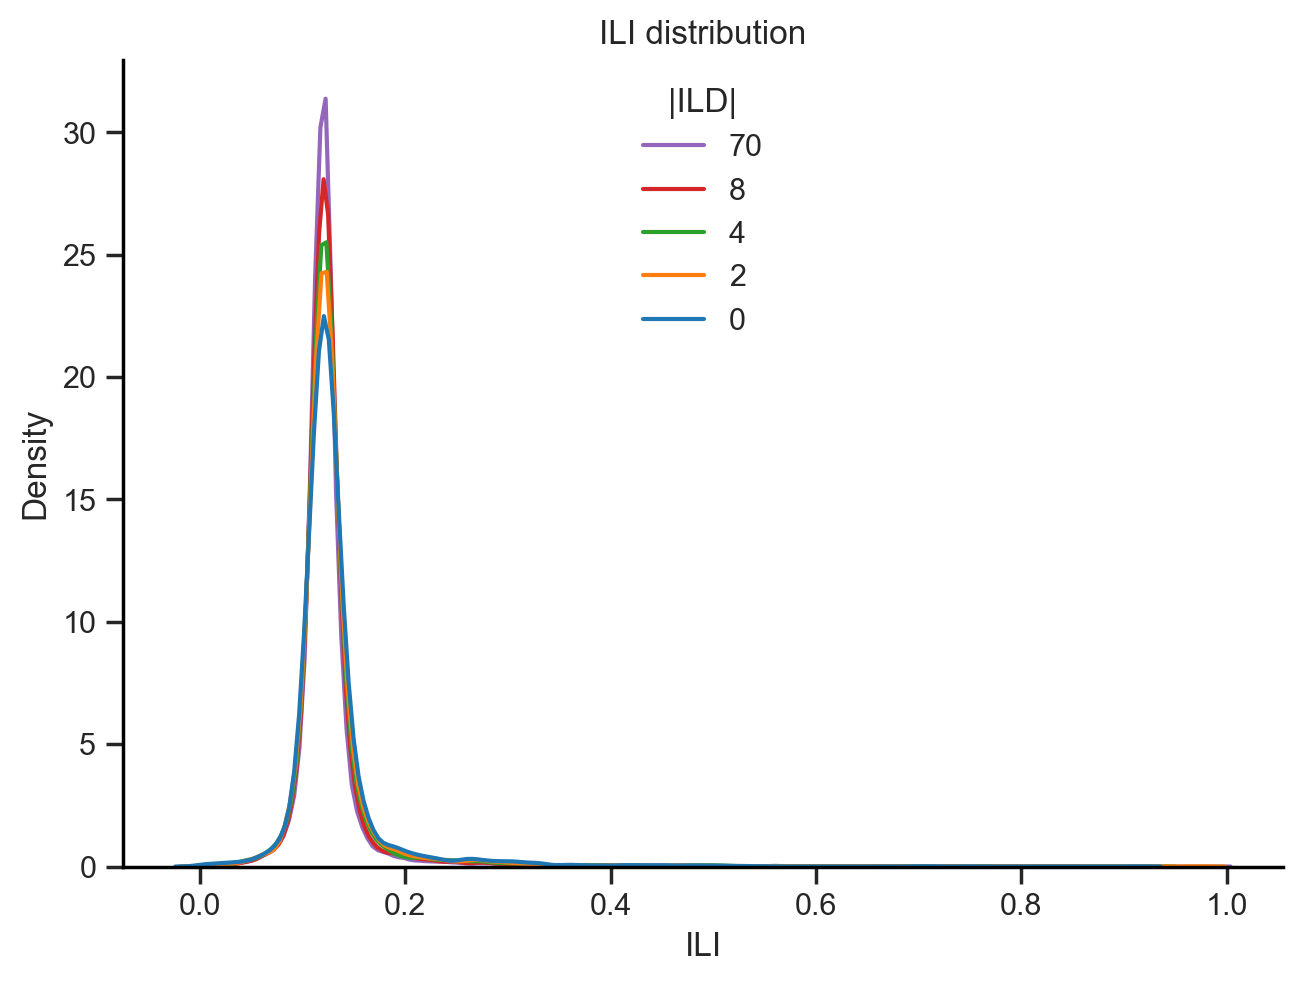

In [39]:
plot_ild_dist(df_behavior, var='ILI')

#### Outcome

#### Previous Outcome

#### Choice

#### Repeat choice

#### Repeat trial

#### Stimulus

#### 1st vs 2nd session half